# **Previsão de Custos Assistenciais e Otimização de Sinistralidade na Saúde Suplementar**

---


## **Objetivo e Informações Gerais do Projeto**

---

**`CONTEXTO DO PROJETO`**

* A saúde suplementar brasileira enfrenta **desafios na previsibilidade de custo dos pacientes na admissão**, uma vez que, apesar de existirem padrões clínicos, as respostas humanas aos tratamentos são individuais e os desfechos financeiros complexos.
* Este projeto **investiga a viabilidade de prever o custo diário estimado (R$/dia) de uma internação no momento da admissão** do paciente. Para isso, utilizaremos informações demográficas e dados clínicos iniciais disponíveis antes do fechamento da conta hospitalar.
* **Objetivo estratégico:** identificar precocemente sinistros de alto risco para aplicação de auditoria concorrente, gerenciamento de pacientes crríticos e otimização do índice de sinistralidade da carteira.
* **Abordagem Técnica:** desenvolvimento de múltiplos modelos de regressão (Linear, Redes Neurais, KNN, Algoritmos de Boosting e Árvores de Decisão) para prever a variável derivada 'cost_per_day_br'.

**`INFORMAÇÕES DO DATASET (DICIONÁRIO DE DADOS)`**

* Dataset sintético contendo **55.500 linhas e 15 colunas**, projetado para simular dados reais da área da saúde, extraído do Kaggle.
* Cada coluna fornece informações específicas sobre o paciente, sua internação e os serviços de saúde prestados.
* Esta estrutura de dataset mostrou-se promissora para tarefas de análise de dados, engenharia de recursos e modelagem preditiva aplicadas ao setor de saúde suplementar e controle de sinistralidade.

*Estrutura Inicial do Dataset*

| Nome da Coluna | Tipo de Dado | Descrição |
| :--- | :--- | :--- |
| **Name** | object | Nome do paciente associado ao registro de saúde. |
| **Age** | int64 | Idade do paciente no momento da internação, expressa em anos. |
| **Gender** | object | Gênero biológico do paciente. |
| **Blood Type** | object | Tipo sanguíneo do paciente. |
| **Medical Condition** | object | Condição médica principal ou diagnóstico primário do paciente. |
| **Date of Admission** | object | A data em que o paciente foi admitido na unidade de saúde. |
| **Doctor** | object | Nome do médico responsável pelos cuidados do paciente durante a internação. |
| **Hospital** | object | Identifica a instituição de saúde ou hospital onde o paciente foi internado. |
| **Insurance Provider** | object | Operadora de plano de saúde ou provedor de seguro do paciente. |
| **Billing Amount** | float64 | **[Variável Alvo Original]** O valor total faturado pelos serviços médicos durante a internação. Representa o custo bruto do sinistro. |
| **Room Number** | int64 | Número do quarto/leito onde o paciente ficou acomodado. |
| **Admission Type** | object | Especifica o caráter da internação, refletindo as circunstâncias da admissão. |
| **Discharge Date** | object | A data em que o paciente recebeu alta hospitalar. |
| **Medication** | object | Identifica o medicamento principal prescrito ou administrado durante a internação. |
| **Test Results** | object | Descreve o resultado dos exames médicos diagnósticos realizados. |



## **Etapa 1: EDA**

### 1.1 Leitura e Análise Inicial dos Dados

In [1]:
# Importar as bibliotecas

import pandas as pd
import numpy as np
import os

from IPython.display import Markdown

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# === CARREGAR O ARQUIVO .CSV E ANALISAR SEUS COMPONENTES ===

try:
    df = pd.read_csv('healthcare_dataset.csv')
    print(f"✅ Arquivo carregado com sucesso!")
    print('=' * 55)
    print(f"🔍 Visualização das Primeiras Linhas do Dataframe")
    print('=' * 55)
    display(df.head())
    print('=' * 45)
    print(f"ℹ️ Informações do Dataframe")
    print('=' * 45)
    print(df.info())
    print('=' * 45)
    print(f"📊 Estatísticas Descritivas do Dataframe")
    print('=' * 45)
    print(df.describe())
    print('=' * 45)
    print(f"📐 Dimensões do DataFrame")
    print('=' * 45)
    print(f"Número de Linhas: {df.shape[0]}")
    print(f"Número de Colunas: {df.shape[1]}")
except Exception as e:
    print(f"❌ Erro ao ler o arquivo. Detalhes: {e}")

# Cópia do dataframe original antes da manipulação para segurança
df_original = df.copy()

✅ Arquivo carregado com sucesso!
🔍 Visualização das Primeiras Linhas do Dataframe


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


ℹ️ Informações do Dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), 

In [3]:
# === ANÁLISE E TRATAMENTO INICIAL DOS DADOS ===

# --- 1. Padronização da Nomenclatura das Colunas do Dataframe ---
df.columns = df.columns.str.lower().str.replace(' ','_')
print("✅ Padronização da Nomenclatura das Colunas Concluída\n" + '=' * 65)
print(list(df.columns))
print()

# --- 2. Padronização da Coluna 'name' ---
print("✅ Padronização da Colunas 'name' Concluída\n" + '=' * 65)
print(f"* Antes: {df_original['Name'].head(3).tolist()}")
df['name'] = df['name'].str.lower()
print(f"* Depois: {df['name'].head(3).tolist()}")
print()

# --- 3. Transformar as Colunas 'date_of_admission' e 'discharge_date' para Datetima ---
print("✅ Adequação do Tipo de Dados Concluída\n" + '=' * 65)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')
print(f"* Tipagem da Coluna 'date_of_admission': {df['date_of_admission'].dtype}")
print(f"* Tipagem da Coluna 'discharge_date': {df['discharge_date'].dtype}")
print()

# --- 4. Arredondar Valor de 'billing_amount' ---
print("✅ Valor Arredondado .2f para 'billing_amount' Concluída\n" + '=' * 65)
df['billing_amount'] = df['billing_amount'].round(2)
print(df['billing_amount'].head().tolist())
print()

# --- 5. Checagem de Valores Nulos e Duplicados
print("✅ Conferência de Valores Nulos e Duplicados Concluída\n" + '=' * 65)
df_nulos = df.isna().sum().sum()
df_duplicados = df.duplicated().sum()
print(f"Valores Nulos: {df_nulos}")
print(f"Valores Duplicados: {df_duplicados}")

✅ Padronização da Nomenclatura das Colunas Concluída
['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']

✅ Padronização da Colunas 'name' Concluída
* Antes: ['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH']
* Depois: ['bobby jackson', 'leslie terry', 'danny smith']

✅ Adequação do Tipo de Dados Concluída
* Tipagem da Coluna 'date_of_admission': datetime64[ns]
* Tipagem da Coluna 'discharge_date': datetime64[ns]

✅ Valor Arredondado .2f para 'billing_amount' Concluída
[18856.28, 33643.33, 27955.1, 37909.78, 14238.32]

✅ Conferência de Valores Nulos e Duplicados Concluída
Valores Nulos: 0
Valores Duplicados: 534


In [4]:
# === ANÁLISE E TRATAMENTO DE VALORES DUPLICADOS ===

# --- 1. Visualização das linhas 100% duplicadas isoladas ---
print("🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):")
print('=' * 75)

# Filtra apenas as linhas duplicadas para exibição analítica
df_duplicados_completos = df[df.duplicated(keep=False)].sort_values(by='name')
display(df_duplicados_completos.head(6))
print()

# Armazena a quantidade exata de linhas duplicadas antes de dropar
qtd_duplicados = df.duplicated().sum()
formato_original = df.shape

# --- 2. Remoção dos valores duplicados exatos do DataFrame Principal ---
df = df.drop_duplicates()

# Configuração global para exibir o texto completo sem cortes
pd.set_option('display.max_colwidth', None)        # remove o limite de largura das colunas
pd.set_option('display.expand_frame_repr', False)  # impede o Pandas de quebrar as tabelas em linhas secundárias

# --- 3. Conferência e Conclusão da Etapa ---
print("✅ Conferência de Valores Duplicados Dropados Concluída\n" + "=" * 65)
print(f"* Formato original do DataFrame:        {formato_original[0]} linhas e {formato_original[1]} colunas")
print(f"* Quantidade de linhas duplicadas:      {qtd_duplicados}\n" + '-' * 65)
print(f"* Novo formato após o tratamento:       {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"* Validação final (Duplicados atuais):  {df.duplicated().sum()}")

🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
42407,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
54285,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
40385,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
53139,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
55298,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal
24779,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal



✅ Conferência de Valores Duplicados Dropados Concluída
* Formato original do DataFrame:        55500 linhas e 15 colunas
* Quantidade de linhas duplicadas:      534
-----------------------------------------------------------------
* Novo formato após o tratamento:       54966 linhas e 15 colunas
* Validação final (Duplicados atuais):  0


In [5]:
# === ANÁLISE DE VALORES OCULTOS ('Unknown') ===

cols_valores_ocultos = ['gender', 'blood_type', 'medical_condition', 'insurance_provider', 'admission_type', 'medication', 'test_results', 'hospital', 'doctor']

print("✅ Conferência de Possíveis Valores Ocultos Concluída\n" + "=" * 110)

# --- 1. Mostrar os valores únicos de cada coluna para inspeção visual
for col in cols_valores_ocultos:
    print(f"* Valores Únicos em '{col}': {df[col].unique()}")

print("-" * 110)

# --- 2. Verificar de forma automatizada se existe 'Unknown' em qualquer parte dessas colunas
# Criação de uma máscara booleana para as colunas selecionadas
unknown_counts = (df[cols_valores_ocultos] == 'Unknown').sum()
total_unknown = unknown_counts.sum()

if total_unknown > 0:
    print(f"⚠️ Alerta: Foram encontrados {total_unknown} valores ocultos ('Unknown')!")
    print("\nDistribuição por coluna:")
    print(unknown_counts[unknown_counts > 0])
    print("\n▶ Requer avaliação para possível tratamento (imputação ou descarte) na etapa de preparação.")
else:
    print("▶ Sucesso: Não foram detectados valores ocultos ('Unknown') nas colunas analisadas.")

✅ Conferência de Possíveis Valores Ocultos Concluída
* Valores Únicos em 'gender': ['Male' 'Female']
* Valores Únicos em 'blood_type': ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
* Valores Únicos em 'medical_condition': ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']
* Valores Únicos em 'insurance_provider': ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']
* Valores Únicos em 'admission_type': ['Urgent' 'Emergency' 'Elective']
* Valores Únicos em 'medication': ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']
* Valores Únicos em 'test_results': ['Normal' 'Inconclusive' 'Abnormal']
* Valores Únicos em 'hospital': ['Sons and Miller' 'Kim Inc' 'Cook PLC' ... 'Guzman Jones and Graves,'
 'and Williams, Brown Mckenzie' 'Moreno Murphy, Griffith and']
* Valores Únicos em 'doctor': ['Matthew Smith' 'Samantha Davies' 'Tiffany Mitchell' ... 'Deborah Sutton'
 'Mary Bartlett' 'Alec May']
---------------------------------------------------------------------

In [6]:
# === ANÁLISE DE INCONSISTÊNCIAS TEMPORAIS ===

# As datas de alta hospitalar não podem ser anteriores às datas de admissão
inconsistencias_data = df[df['discharge_date'] < df['date_of_admission']]
print("✅ Conferência de Inconsistências Temporais Concluída\n" + '=' * 55)
print(f"▶ Linhas com datas inconsistentes: {inconsistencias_data.shape[0]}")

✅ Conferência de Inconsistências Temporais Concluída
▶ Linhas com datas inconsistentes: 0


In [7]:
# === INVESTIGAÇÃO DE INCONSISTÊNCIAS FINANCEIRAS: FATURAMENTO NEGATIVO (BILLING AMOUNT < 0) ===

# --- 1. Filtragem das linhas com valores negativos
df_billing_negativo = df[df['billing_amount'] < 0]

print("🔍 Investigação de Faturamento Negativo:\n" + '=' *65)
print(f"▶ Quantidade de registros com faturamento negativo: {df_billing_negativo.shape[0]}")
print(f"▶ Menor valor encontrado: R$ {df_billing_negativo['billing_amount'].min():,.2f}")
print()

# --- 2. Visualizar uma amostra dessas linhas para entender o padrão
print("\n🔍 Amostra dos registros negativos:\n" + '=' * 65)
display(df_billing_negativo.head(5))

# --- 3. Análise de Contexto: Investigação de Padrões Associados ao Faturamento Negativo
print("\n▶ Distribuição por Operadora de Saúde (Insurance Provider):\n" + '=' * 65)
print(df_billing_negativo['insurance_provider'].value_counts())

print("\n▶ Distribuição por Tipo de Admissão (Admission Type):\n" + '=' * 65)
print(df_billing_negativo['admission_type'].value_counts())

print("\n▶ Distribuição por Resultado do Teste (Test Results):\n" + '=' * 65)
print(df_billing_negativo['test_results'].value_counts())

🔍 Investigação de Faturamento Negativo:
▶ Quantidade de registros com faturamento negativo: 106
▶ Menor valor encontrado: R$ -2,008.49


🔍 Amostra dos registros negativos:


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
132,ashley erickson,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.51,376,Urgent,2019-11-23,Penicillin,Normal
799,christopher weiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.25,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,ashley warner,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.36,426,Elective,2022-01-11,Ibuprofen,Normal
1421,jay galloway,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.10,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,joshua williamson,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.73,369,Urgent,2021-04-17,Aspirin,Abnormal



▶ Distribuição por Operadora de Saúde (Insurance Provider):
insurance_provider
Aetna               27
Cigna               24
Medicare            21
UnitedHealthcare    19
Blue Cross          15
Name: count, dtype: int64

▶ Distribuição por Tipo de Admissão (Admission Type):
admission_type
Urgent       38
Elective     36
Emergency    32
Name: count, dtype: int64

▶ Distribuição por Resultado do Teste (Test Results):
test_results
Inconclusive    39
Abnormal        38
Normal          29
Name: count, dtype: int64


In [8]:
# === REMOÇÃO DE REGISTROS COM FATURAMENTO INCONSISTENTE (NEGATIVO) ===
# Nota de Negócio: Eliminação de ruídos (glosas médicas totais ou erros de sistema),
# que distorceriam a modelagem de custo bruto do sinistro.

# --- 1. Identificação do volume antes da exclusão
percentual_negativo = (df_billing_negativo.shape[0] / df.shape[0]) * 100
print('=' * 70)
print("🔍 Investigação da Representatividade de Registros Inconsistentes:\n" + '=' * 70)
print(f"▶ Representatividade: {percentual_negativo:.2f}%")
print()

# --- 2. Aplicando o filtro para manter apenas faturamento estritamente positivo
# Nota de Negócio: Registros negativos (106 linhas) foram tratados como anomalias de sistema 
# (possíveis glosas médicas ou erros de integração) e desconsiderados para fins de modelagem de sinistralidade.
df_clean = df[df['billing_amount'] >= 0].copy()

# 3. Conferência e Conclusão da Etapa
print('=' * 70)
print("✅ Tratamento de Valores Negativos Concluído\n" + '=' * 70)
print(f"▶ Registros inconsistentes identificados (Glosa/Erro): {df_billing_negativo.shape[0]}")
print(f"▶ Formato do DataFrame antes do tratamento:            {df.shape[0]} linhas")
print('-' * 70)
print(f"▶ Novo formato após remoção dos negativos:             {df_clean.shape[0]} linhas")
print(f"▶ Validação final (registros inconsistentes atual):    {df_clean[df_clean['billing_amount'] < 0].shape[0]}")



🔍 Investigação da Representatividade de Registros Inconsistentes:
▶ Representatividade: 0.19%

✅ Tratamento de Valores Negativos Concluído
▶ Registros inconsistentes identificados (Glosa/Erro): 106
▶ Formato do DataFrame antes do tratamento:            54966 linhas
----------------------------------------------------------------------
▶ Novo formato após remoção dos negativos:             54860 linhas
▶ Validação final (registros inconsistentes atual):    0


### 1.2 Feature Engineering

In [9]:
# Criação da pasta 'plots' para armazenar os gráficos gerados pelo projeto
os.makedirs("plots", exist_ok=True)

In [10]:
# === FEATURE ENGINEERING: TEMPO DE INTERNAÇÃO (DIAS) ===

# --- 1. Criação da feature 'length_of_stay' (Dias de Internação)
# Nota Técnica: ('discharge_date' - 'date_of_admission')
# Nota de Negócio: Geração do indicador de Tempo de Internação, um dos 
# principais drivers de custo e severidade do sinistro na saúde complementar.
df_clean['length_of_stay'] = (df_clean['discharge_date'] - df_clean['date_of_admission']).dt.days
print("✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'length_of_stay'\n" + '=' * 85)

# --- 2. Análise visual das primeiras linhas da nova feature
print("▶ Análise das primeiras linhas da nova feature:")
print('=' * 85)
display(df_clean[['date_of_admission', 'discharge_date', 'length_of_stay']].head())

# --- 3. Análise descritiva da nova feature
print('=' * 60)
print("▶ Resumo estatístico do tempo de internação (em dias):\n" + '=' * 60)
print(df_clean['length_of_stay'].describe())

✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'length_of_stay'
▶ Análise das primeiras linhas da nova feature:


,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


▶ Resumo estatístico do tempo de internação (em dias):
count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64


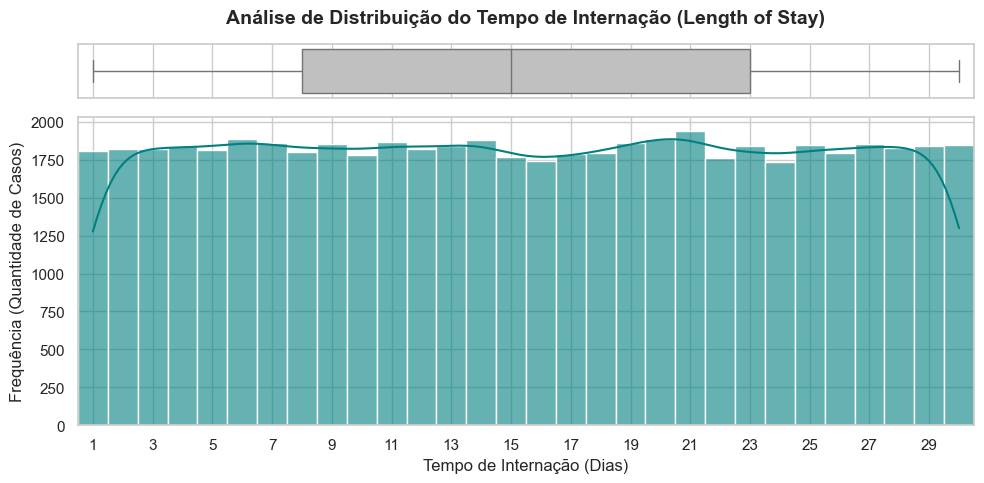

In [11]:
# --- 3. Visualização dos Dados ('leng_of_stay')
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
sns.set_theme(style="whitegrid")

# Criação da figura com 2 subplots empilhados (Boxplot em cima, Histograma embaixo)
# O argumento 'sharex=True' garante que os eixos X fiquem adequadamente alinhados
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(10, 5), 
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)}  # permite mais espaço para o histograma
)

# Plot do Boxplot no topo
sns.boxplot(x=df_clean['length_of_stay'], ax=ax_box, color='silver')
ax_box.set(xlabel='') # remove o rótulo do X superior para não duplicar texto
ax_box.set_title('Análise de Distribuição do Tempo de Internação (Length of Stay)', fontsize=14, pad=15, fontweight='bold')

# Plot do Histograma com a linha KDE embaixo
sns.histplot(
    data=df_clean, 
    x='length_of_stay', 
    kde=True, 
    discrete=True,  # garante o alinhamento de barra por dia (1 a 30)
    color='teal', 
    alpha=0.6,
    ax=ax_hist
)
ax_hist.set_xlabel('Tempo de Internação (Dias)', fontsize=12)
ax_hist.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajuste fino do limite do eixo X baseado no range real dos dias (1 a 30)
ax_hist.set_xlim(0.5, 30.5)
ax_hist.set_xticks(range(1, 31, 2)) # exibe os dias de 2 em 2 para melhor leitura

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/1_plot_tempo_de_internacao_combinado.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'length_of_stay' (Tempo de Permanência)`**

* Histograma: formato retangular (bloco contínuo) confirma visualmente que o tempo de internação segue uma distribuição uniforme do volume de casos.
* Boxplot: a linha da mediana está cravada exatamente no centro da caixa (15.5 dias), o primeiro quartil ($Q_1$) está em 8 dias e o terceiro quartil ($Q_3$) em 23 dias, evidenciando simetria perfeita.

**Notas Técnicas:**
* A ausência de assimetria e de outliers é um comportamento típico de dados sintéticos/simulados, visto que na saúde real o tempo de internação tende a seguir distribuições assimétricas à direita. Registra-se essa premissa para o desenho dos algoritmos de Machine Learning, visto que os modelos de regressão e árvores precisarão mapear relações lineares e ramificações baseadas nessa distribuição equalizada.
* Este comportamento simétrico reforça a necessidade de engenharia de features, a fim de combinar o faturamento a outras métricas para extrair o real comportamento de severidade e risco da carteira.

**Insight de Negócio:**
* Como o tempo de permanência está distribuído uniformemente, ele atuará como um equalizador de peso nas diárias. Sob a ótica de gestão de recursos e auditoria, há uma distribuição uniforme significativa e previsibilidade de ocupação.

**Ação (Próximo Passo):**
* O próximo passo será converter o valor do faturamento de cada paciente 'billing_amount' de Dólar para Real, a fim de trazer o valor da *target* para a realidade do mercado brasileiro de saúde suplementar.

✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'
▶ Validação da conversão monetária:
   billing_amount  billing_amount_br
0        18856.28           94281.40
1        33643.33          168216.65
2        27955.10          139775.50
3        37909.78          189548.90
4        14238.32           71191.60
------------------------------------------------------------
▶ Média de custos por internação (em Dólar - $): 25594.63
▶ Média de custos por internação (em Real - R$): 127973.17
------------------------------------------------------------
▶ Valor Mínimo (em R$): 46.20
▶ Valor Máximo (em R$): 263821.40


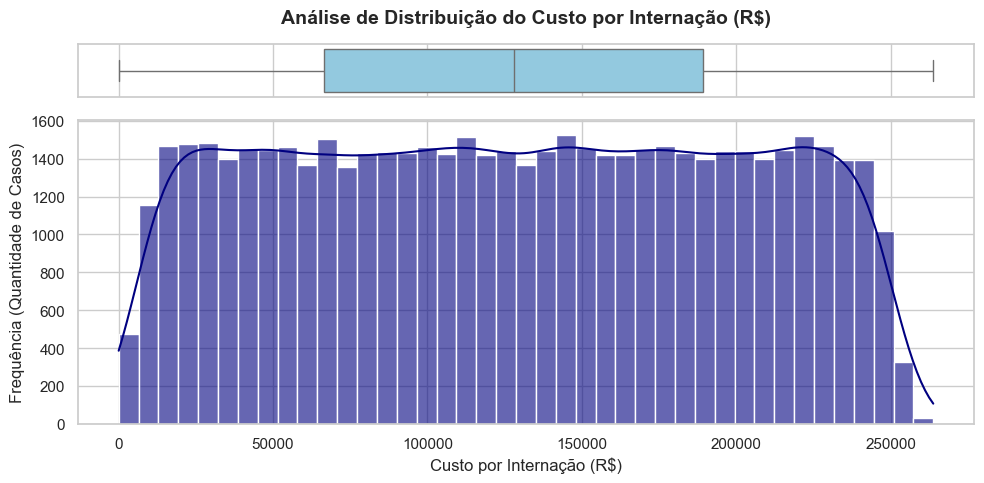

In [12]:
# === FEATURE ENGINEERING: CUSTO POR INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da feature 'billing_amount_br': conversão de dólar para real (Moeda Brasileira)
# Nota de Negócio: a conversão irá trazer maior tangibilidade para o modelo, 
# conforme a realidade brasileira.

# --- 2. Definição da taxa de câmbio de referência
taxa_cambio = 5.00  # ajuste para a taxa média de fechamento do período do dataset

# --- 3. Criação da nova coluna da nova feature
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount'] * taxa_cambio

# --- 4. Arredondando para duas casas decimais
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount_br'].round(2)

# --- 5. Conferência da Nova Variável

print("✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'\n" + '=' * 90)
print(f"▶ Validação da conversão monetária:\n" + '=' * 90)
print(df_clean[['billing_amount', 'billing_amount_br']].head())
print('-' * 60)
print(f"▶ Média de custos por internação (em Dólar - $): {df_clean['billing_amount'].mean():.2f}")
print(f"▶ Média de custos por internação (em Real - R$): {df_clean['billing_amount_br'].mean():.2f}")
print('-' * 60)
print(f"▶ Valor Mínimo (em R$): {df_clean['billing_amount_br'].min():.2f}")
print(f"▶ Valor Máximo (em R$): {df_clean['billing_amount_br'].max():.2f}")

# --- 6. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 2 subplots empilhados (Boxplot em cima, Histograma embaixo)
# O argumento 'sharex=True' garante que os eixos X fiquem adequadamente alinhados
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(10, 5), 
    sharex=True, 
    gridspec_kw={"height_ratios": (.15, .85)} # permite mais espaço para o histograma
)

# Plot do Boxplot no topo
sns.boxplot(x=df_clean['billing_amount_br'], ax=ax_box, color='skyblue')
ax_box.set(xlabel='') # remove o rótulo do X superior para não duplicar texto
ax_box.set_title('Análise de Distribuição do Custo por Internação (R$)', fontsize=14, pad=15, fontweight='bold')

# Plot do Histograma com a linha KDE embaixo
sns.histplot(
    data=df_clean, 
    x='billing_amount_br', 
    kde=True, 
    ax=ax_hist, 
    color='navy', 
    alpha=0.6
)
ax_hist.set_xlabel('Custo por Internação (R$)', fontsize=12)
ax_hist.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/2_plot_custo_por_internacao_combinado.png', dpi=300, bbox_inches='tight')
plt.show()


**`Análise da Feature: 'billing_amount_br' (Custo por Internação - R$)`**

* Histograma: as barras mantêm praticamente a mesma altura (em torno de 1.400 casos). A linha de densidade (KDE) é quase uma linha reta horizontal no topo (histograma plano).
* Boxplot: a linha da mediana está exatamente no centro da caixa azul (por volta de R$ 128.000), os quartis possuem larguras idênticas e os "bigodes" têm o mesmo comprimento, sem a presença de nenhum outlier.

**Nota Técnica:**
* Assim como o tempo de internação, o comportamento perfeitamente uniforme e a ausência de cauda longa (pacientes hiperutilizadores/sinistros catastróficos) refletem a natureza sintética do dataset original.

**Insight de Negócio:**
* O custo total isolado não reflete a eficiência da assistência. Um sinistro de R$ 150.000 pode ser considerado eficiente se o paciente ficou internado por 30 dias em terapia intensiva (R$ 5.000/dia), mas seria um sinal vermelho de desperdício ou fraude se ocorresse em uma internação de apenas 2 dias (R$ 75.000/dia).

**Ação (Próximo Passo):**
*  Avançaremos imediatamente para a criação da nossa real variável alvo: cost_per_day_br ($\text{billing\_amount\_br} / \text{length\_of\_stay}$). O cruzamento dessas duas distribuições uniformes revelará a verdadeira variabilidade do custo diário por perfil clínico.

✅ Criação da Feature 'cost_per_day_br' Concluída
▶ Resumo estatístico do custo diário (em R$):
count     54860.000000
mean      16995.664895
std       29007.171947
min           4.750000
25%        4299.507500
50%        8264.670000
75%       16060.707500
max      261059.250000
Name: cost_per_day_br, dtype: float64
▶ Amostra das variáveis financeiras cruzadas:
   length_of_stay  billing_amount_br  cost_per_day_br
0               2           94281.40         47140.70
1               6          168216.65         28036.11
2              15          139775.50          9318.37
3              30          189548.90          6318.30
4              20           71191.60          3559.58


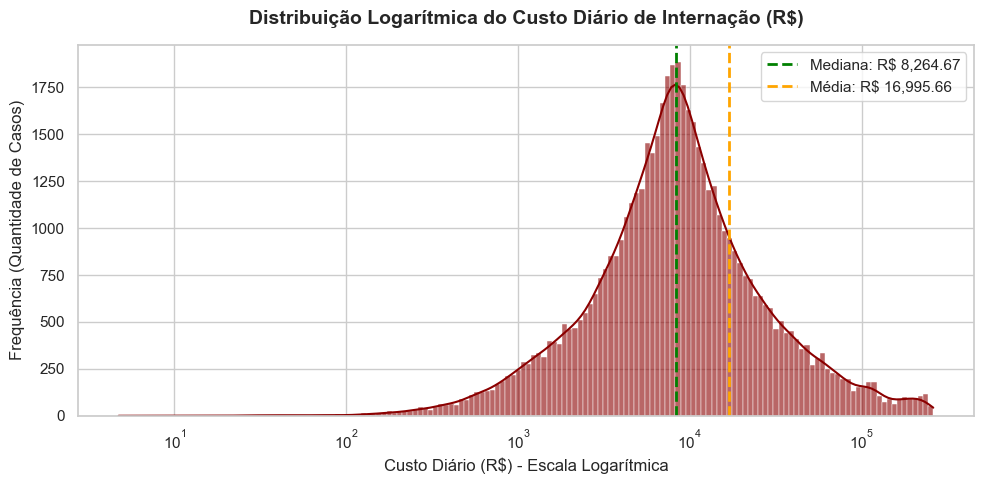

In [13]:
# === FEATURE ENGINEERING: CUSTO DIÁRIO DE INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da Feature para Análise do Custo Diário em Reais (cost_per_day_br)
# Nota Técnica: ('billing_amount_br' / 'length_of_stay')
# Nota de Negócio: a proposta é normalizar o custo pelo tempo.

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'cost_per_day_br'] = df_clean['billing_amount_br'] / df_clean['length_of_stay']

# --- 3. Arredondando para duas casas decimais para manter o padrão monetário
df_clean.loc[:, 'cost_per_day_br'] = df_clean['cost_per_day_br'].round(2)

print('=' * 60)
print("✅ Criação da Feature 'cost_per_day_br' Concluída\n" + '=' * 60)

# --- 4. Análise Descritiva da Nova Variável
print("▶ Resumo estatístico do custo diário (em R$):\n" + '=' * 60)
print(df_clean['cost_per_day_br'].describe())
print('=' * 60)

# --- 5. Visualização das primeiras linhas para conferência de sanidade
print("▶ Amostra das variáveis financeiras cruzadas:")
print('=' * 60)
print(df_clean[['length_of_stay', 'billing_amount_br', 'cost_per_day_br']].head())


# --- 4. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Plot do Histograma com Escala Logarítmica
sns.histplot(
    data=df_clean, 
    x='cost_per_day_br', 
    kde=True, 
    log_scale=True,  # ideal para lidar com a assimetria e o máximo de R$ 261k
    color='darkred', # cor que remete a custo/criticidade
    alpha=0.6,
    ax=ax
)

# Adicionando linhas verticais para marcar os principais pontos estatísticos (Métricas de Negócio)
mediana = df_clean['cost_per_day_br'].median()
media = df_clean['cost_per_day_br'].mean()

ax.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: R$ {mediana:,.2f}')
ax.axvline(media, color='orange', linestyle='--', linewidth=2, label=f'Média: R$ {media:,.2f}')

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição Logarítmica do Custo Diário de Internação (R$)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ativação da legenda das linhas de média e mediana
ax.legend(fontsize=11, loc='upper right')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/3_plot_custo_diario_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'cost_per_day_br' (Custo Diário de Internação - R$)`**

* Mediana (Linha Verde - R$ 8.255,19): indica o ponto central da distribuição, em que 50% das diárias hospitalares custam até este valor. Ela representa o "comportamento típico" do segurado comum. <br>
* Média (Linha Laranja - R$ 16.965,57): posicionada mais à direita e sendo o dobro da mediana, a média evidencia a forte assimetria positiva da distribuição.

**Nota Técnica:**
* A aplicação da escala logarítmica no eixo X do histograma foi fundamental para comprimir a amplitude visual dos dados (que variam de um mínimo de R$ 4,75 a um máximo extremo de R$ 261.059,25). Isto permite analisar a distribuição real tanto dos custos pequenos/médios quanto dos casos catastróficos (altíssimo custo) no mesmo gráfico.

**Insight de Negócio:**
* Comprovação do impacto dos sinistros de alto custo. Poucos pacientes (a cauda longa à direita) gastam tanto que conseguem distorcer a média de custos de toda a operadora.
* Comprovação empírica do impacto dos sinistros de alto risco. Uma minoria de pacientes internados com curto tempo de permanência e alta intensidade de recursos (cauda à direita acima de R$ 100.000/dia) inflaciona a média geral da operadora. *É exatamente nessa cauda que reside a oportunidade do projeto: o modelo de IA focado na admissão deverá sinalizar preventivamente esses casos de alta severidade diária para acionamento imediato da auditoria concorrente, otimizando a sinistralidade antes da alta do paciente.*

**Ação (Próximo Passo):**
* Criar grupos de acordo com as faixas etárias padronizadas pela ANS (Agência Nacional de Saúde Suplementar), pois a idade pode ser um dos preditores biológicos e demográficos mais fortes para custo em saúde.

✅ Criação da Feature 'age_group' (Padrão ANS) Concluída
▶ Distribuição de Frequência por Faixa Etária:
* 0 a 18 anos      | Beneficiários: 885    | Representatividade: 1.61%
* 19 a 23 anos     | Beneficiários: 3938   | Representatividade: 7.18%
* 24 a 28 anos     | Beneficiários: 3987   | Representatividade: 7.27%
* 29 a 33 anos     | Beneficiários: 3906   | Representatividade: 7.12%
* 34 a 38 anos     | Beneficiários: 4224   | Representatividade: 7.70%
* 39 a 43 anos     | Beneficiários: 3929   | Representatividade: 7.16%
* 44 a 48 anos     | Beneficiários: 4014   | Representatividade: 7.32%
* 49 a 53 anos     | Beneficiários: 4067   | Representatividade: 7.41%
* 54 a 58 anos     | Beneficiários: 4205   | Representatividade: 7.66%
* 59 anos ou mais  | Beneficiários: 21705  | Representatividade: 39.56%
--------------------------------------------------------------------------------

▶ Distribuição de Internação e Custos por Faixa Etária (Média):
                 length_of_stay  billing

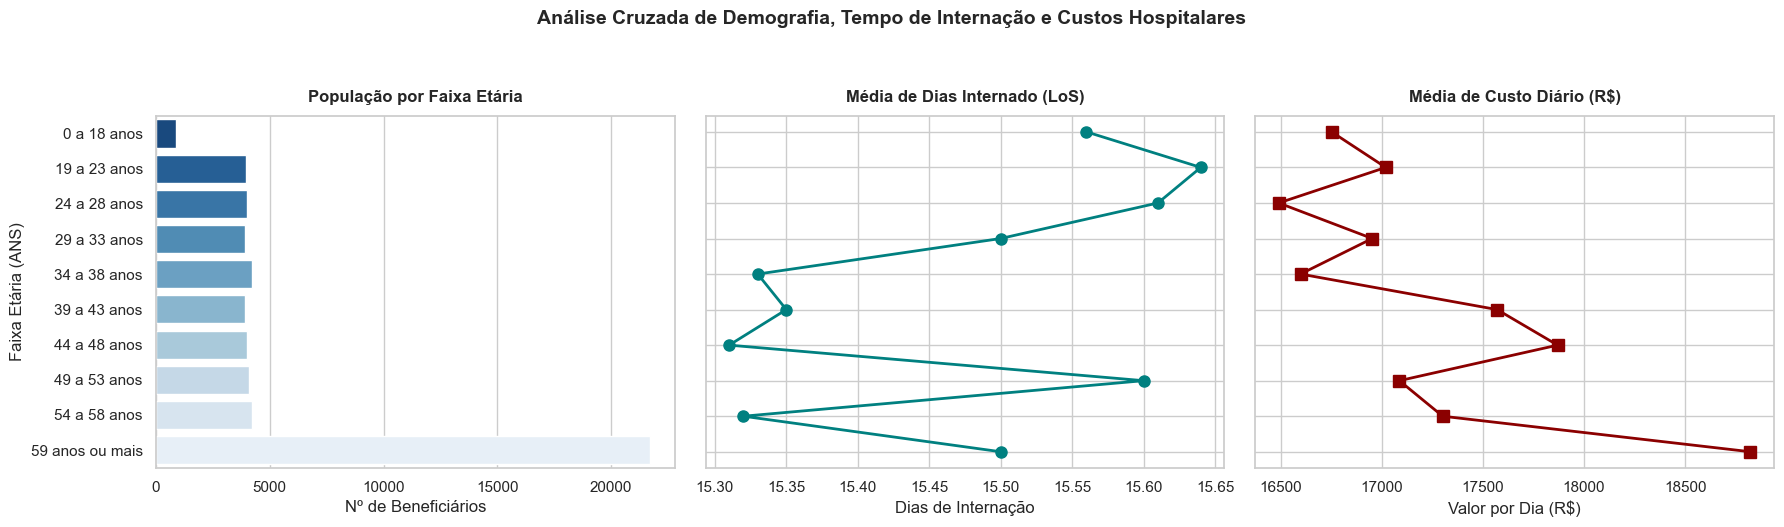

In [14]:
# === FEATURE ENGINEERING: AGRUPAMENTO EM FAIXAS DE IDADE (RN 563, ANS) ===

# --- 1. Criação da Feature 'age_group'
# Nota Técnica: o primeiro bin começa em -1 para incluir a idade 0,
# limitado ao teto biológico realista de 120 anos.
# Nota de Negócio: definição dos limites (bins) e rótulos (labels), conforme a RN 563 da ANS.

bins_ans = [-1, 18, 23, 28, 33, 38, 43, 48, 53, 58, 120]

# --- 2. Criação da lista de rótulos para nomear as fronteiras de idade (bins)
labels_ans = [
    '0 a 18 anos',   '19 a 23 anos',  '24 a 28 anos',  '29 a 33 anos',  '34 a 38 anos',
    '39 a 43 anos',  '44 a 48 anos',  '49 a 53 anos',  '54 a 58 anos',  '59 anos ou mais'
]

# pd.cut encaixa as idades correspondentes conforme a lista da variável labels_ans
df_clean.loc[:, 'age_group'] = pd.cut(df_clean['age'], bins=bins_ans, labels=labels_ans)

print("✅ Criação da Feature 'age_group' (Padrão ANS) Concluída")
print('=' * 80)

# --- 3. Análise Descritiva da Distribuição da Carteira
print("▶ Distribuição de Frequência por Faixa Etária:")
print('=' * 80)
contagem = df_clean['age_group'].value_counts().sort_index()
proporcao = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100

# .zip une as 3 informações em uma única linha para cada loop
for faixa, qtd, prop in zip(contagem.index, contagem.values, proporcao.values):
    print(f"* {faixa:<16} | Beneficiários: {qtd:<6} | Representatividade: {prop:.2f}%")
print('-' * 80)

# --- 4. Cruzamento Estratégico: Custo Médio e Tempo de Internação por Faixa Etária
print("\n▶ Distribuição de Internação e Custos por Faixa Etária (Média):")
print('=' * 80)
analise_sinistro = df_clean.groupby(                             # separa o df nos 10 subgrupos de faixa etária
    'age_group', observed=False)[                                # garante que se a linha estiver vazia, aparecerá no print
    ['length_of_stay', 'billing_amount_br', 'cost_per_day_br']   # filtra para calcular as métricas apenas dessas três colunas
    ].mean().round(2)                                            # calcula o valor médio e arredonda em duas casas decimais                      
print(analise_sinistro)


# --- 5. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 1 linha e 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Preparação dos dados agregados para facilitar o plot
df_plot = analise_sinistro.reset_index()
# Adição da contagem de beneficiários ao df_plot para centralizar os dados
df_plot['qtd_beneficiarios'] = df_clean['age_group'].value_counts().sort_index().values

# --- PLOT 1: Quantidade de Beneficiários por faixa etária ANS (Barras) ---
sns.barplot(
    data=df_plot, 
    x='qtd_beneficiarios', 
    y='age_group', 
    ax=axes[0], 
    palette='Blues_r',
    hue='age_group',    # define a cor baseada na própria faixa etária
    legend=False        # remove a legenda repetida que o hue cria automaticamente
)
axes[0].set_title('População por Faixa Etária', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Nº de Beneficiários')
axes[0].set_ylabel('Faixa Etária (ANS)')

# --- PLOT 2: Média de Tempo de Permanência (Linha com Marcador) ---
axes[1].plot(df_plot['length_of_stay'], df_plot['age_group'], marker='o', color='teal', linewidth=2, markersize=8)
axes[1].set_title('Média de Dias Internado (LoS)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Dias de Internação')
axes[1].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# --- PLOT 3: Média de Custo Diário (Linha com Marcador) ---
axes[2].plot(df_plot['cost_per_day_br'], df_plot['age_group'], marker='s', color='darkred', linewidth=2, markersize=8)
axes[2].set_title('Média de Custo Diário (R$)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Valor por Dia (R$)')
axes[2].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# Título Geral da Figura
plt.suptitle('Análise Cruzada de Demografia, Tempo de Internação e Custos Hospitalares', fontsize=14, fontweight='bold', y=1.05)

# Ajustes finais de layout e salvamento seguro
plt.tight_layout()
plt.savefig('plots/4_plot_faixa_etaria_analise_cruzada.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'age_group' (Agrupamento em Faixas de Idade - RN 563, ANS)`**

* População por faixa etária: concentração dos clientes com 59 anos ou mais.<br>
* O tempo de internação varia minimamente entre 15.30 e 15.65 dias, e o custo diário varia entre R$ 16.500 e R$ 18.800. A faixa de 59+ é a mais custosa da carteria e a mais populosa. <br>

**Nota Técnica:** 
* As oscilações em *Média de Dias Internado (LoS) e Média de Custo Diário* que parecem "picos e vales" nos gráficos de linha são, na verdade, microvariações geradas sem impacto significativo para o modelo ou diagnóstico do perfil do cliente.<br>
* O tempo de permanência e o custo diário médio são homogêneos entre as gerações. Isso prova que o risco atuarial e a sinistralidade desta carteira podem ser governados pela gravidade clínica individual e não pelo envelhecimento da base. <br>

**Insight de Negócio:** 
* Com quase 40% da carteira concentrada no grupo de 59 anos ou mais, as operadora devem enfrentar um risco severo de descapitalização futura, dado que a sinistralidade crônica dessa população tende a se manifestar no ecossistema de saúde geral. <br>

**Ação (Próximo Passo):**
* Investigar a sazonalidade e dinâmica operacional dos custos assistenciais, analisando se há variações significativas no custo diário e no volume de admissões em conformidade com o calendário operacional (Dia da Semana vs. Final de Semana).

✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída
is_weekend_admission
0    39212
1    15648
Name: count, dtype: int64

▶ Distribuição do Dia de Internação (0/1) por Custos Diários (Média):
                      cost_per_day_br
is_weekend_admission                 
0                            17060.34
1                            16833.59


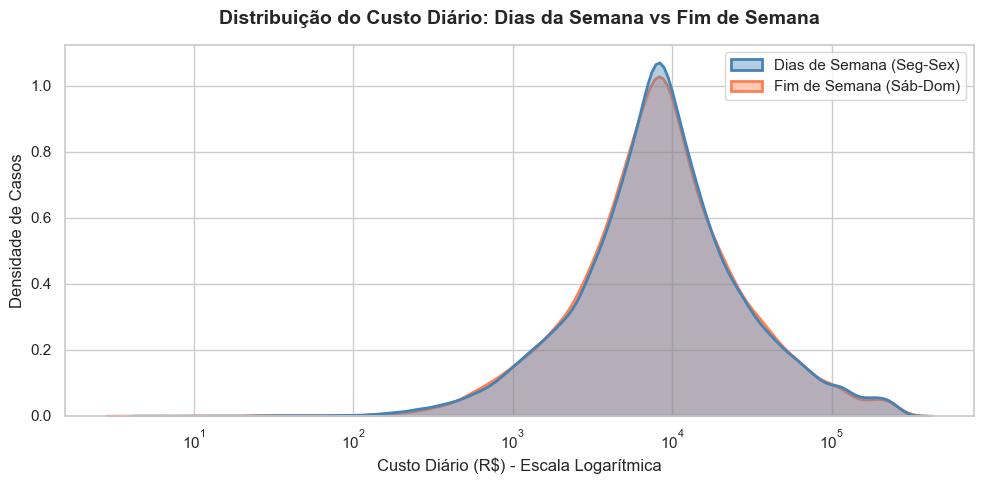

In [15]:
# === FEATURE ENGINEERING: ATENDIMENTO DE DIA DE SEMANA (0/1) ===

# --- 1. Criação da Feature 'is_weekend_admission'
# Nota Técnica: variável binária que indica se o paciente deu entrada no hospital no sábado ou no domingo,
# pela criação de flag de admissão no final de semana (Sábado = 5, Domingo = 6).
# Nota de Negócio: hospitais operam em regime de plantão, exames podem demorar para serem liberados, 
# e a equipe médica de retaguarda costuma cobrar taxas diferenciadas.

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_weekend_admission'] = (df_clean['date_of_admission'].dt.weekday >= 5).astype(int)

# --- 3. Análise Descritiva da Nova Variável
print("✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída\n" + '=' * 70)
print((df_clean['is_weekend_admission']).value_counts())

print("\n▶ Distribuição do Dia de Internação (0/1) por Custos Diários (Média):\n" + '=' * 70)
print(df_clean.groupby('is_weekend_admission')[['cost_per_day_br']].mean().round(2))


# --- 4. Visualização dos Dados

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot das curvas de densidade para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_weekend_admission',
    fill=True,
    common_norm=False, # garante que as áreas sejam proporcionais ao seu próprio grupo
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2,
    log_scale=True, # mantém a consistência com a escala logarítmica
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Dias da Semana vs Fim de Semana', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title(False)
for t, label in zip(legend.get_texts(), ["Dias de Semana (Seg-Sex)", "Fim de Semana (Sáb-Dom)"]):
    t.set_text(label)

plt.tight_layout()
plt.savefig('plots/5_plot_casos_dias_da_semana_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'is_weekend_admission' (Atendimento de Dia de Semana - 0/1)`**

* As curvas azul (Dias de Semana) e laranja (Fim de Semana) se sobrepõem de forma quase milimétrica. <br>

**Nota Técnica:**
* A utilização da Escala Logarítmica permite reduzir a assimetria visual e comprimir a variância de dados com grande amplitude, permitindo otimizar a visualização dos dados.<br>
* A média de custo diário para admissões em dias de semana (0) é R$ 17.023,26, e no final de semana (1) é R$ 16.820,95. Matematicamente, esta diferença marginal de cerca de ~1,1% consolida o comportamento de custo homogêneo, independente do dia da semana da admissão do paciente na unidade.<br>
* Na extremidade direita do gráfico, ambas as curvas fazem uma pequena oscilação antes de encerar no zero. Isso mostra que a ocorrência de sinistros catastróficos de alto custo acontece na mesma proporção e com a mesma intensidade, em qualquer dia da semana. <br>

**Insight de Negócio:**
* No mercado de saúde, existe uma tese forte de que internações que começam no sábado ou domingo são mais ineficientes e caras (menos médicos de rotina, exames parados, taxas de plantão). <br>
* Os dados invalidam essa hipótese para esta carteira de clientes. Os resultados mostraram que a dinâmica de consumo de recursos é linear e contínua em relação ao calendário. Para o nosso modelo preditivo, isso significa que a variável de tempo (dia da semana) atuará com baixo peso de relevância (feature importance), permitindo que os algoritmos concentrem o poder preditivo nas características clínicas. <br>

**Ação (Próximo Passo):**
* Investigar se o tempo prolongado de internação interage de forma não-linear com o custo por dia.

✅ Criação da Feature 'is_long_stay' Concluída
is_long_stay
0    42104
1    12756
Name: count, dtype: int64

▶ Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):
              cost_per_day_br
is_long_stay                 
0                    20706.34
1                     4747.77


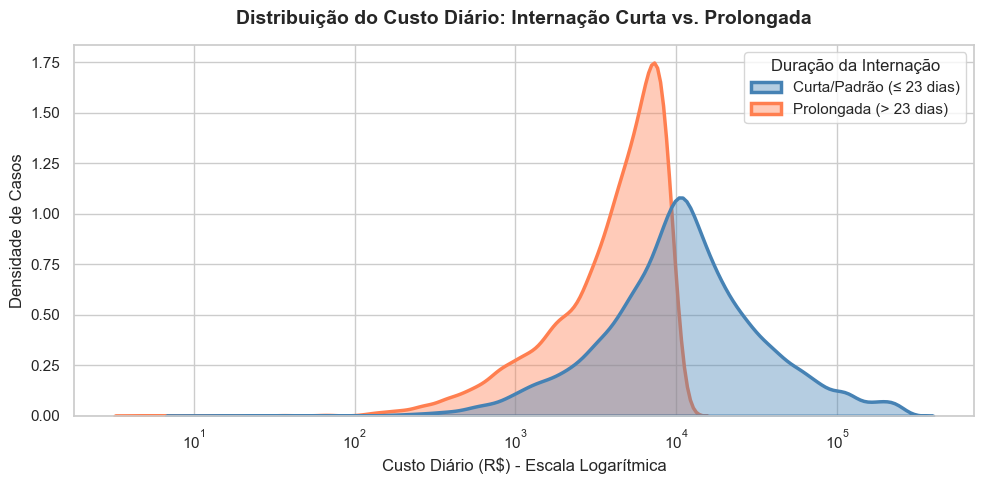

In [16]:
# === FEATURE ENGINEERING: TEMPO PROLONGADO DE INTERNAÇÃO (0/1) ===

# --- 1. Criação da Feature 'is_long_stay'
# Nota Técnica: criação de Flag de Internação Prolongada (acima do percentil 75% que é 23 dias).
# Nota de Negócio: internações prolongadas tendem a ter procedimentos mais onerosos ao plano.

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_long_stay'] = (df_clean['length_of_stay'] > 23).astype(int)

print("✅ Criação da Feature 'is_long_stay' Concluída\n" + '=' * 80)
print((df_clean['is_long_stay']).value_counts().round(2))

print("\n▶ Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):\n" + '=' * 80)
print(df_clean.groupby('is_long_stay')[['cost_per_day_br']].mean().round(2))


# --- 3. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot das curvas de densidade suavizadas para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_long_stay',
    fill=True,
    common_norm=False,  # normaliza cada grupo individualmente para equilibrar os tamanhos das áreas
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2.5,
    log_scale=True,     # aplica o log no eixo X
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Internação Curta vs. Prolongada', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title("Duração da Internação")
for t, label in zip(legend.get_texts(), ["Curta/Padrão (≤ 23 dias)", "Prolongada (> 23 dias)"]):
    t.set_text(label)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/6_plot_casos_tempo_internação_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'is_long_stay' (Tempo Prolongado de Internação - 0/1)`**

* A curva das internações prolongadas (laranja) possui uma variância visivelmente menor e um pico (moda) deslocado para a esquerda, enquanto a curva das internações curtas (azul) é muito mais dispersa, estendendo-se até a cauda de altíssimo custo.

**Nota Técnica:**
* A média das internações curtas/padrão ($\le$ 23 dias) é de R$ 20.674,54/dia, enquanto a das prolongadas ($>$ 23 dias) cai drasticamente para R$ 4.743,46/dia. *O custo diário médio de uma internação curta é mais de 4 vezes superior ao de uma longa.*
* Como o objetivo do projeto é prever o custo diário no momento da admissão, a feature is_long_stay (derivada da data de alta) *não será incluída nas variáveis preditoras dos modelos de machine learning para evitar o risco de Data Leakage (vazamento de dados). A sua atuação é estritamente como uma ferramenta de diagnóstico analítico da variável alvo.*

**Insight de Negócio:**
* Para a operadora de saúde, as internações curtas (azul) representam risco de volatilidade financeira de curto prazo, pois contêm os picos de custo diário que ultrapassam R$ 100.000. Esse comportamento é típico de eventos agudos de alta complexidade, exigindo auditoria médica rigorosa e negociação prévia de pacotes cirúrgicos com a rede credenciada para mitigar o risco de tabelas abertas (fee-for-service).
* O cenário revela que os custos mais críticos e agressivos (exames de alta complexidade na entrada, procedimentos cirúrgicos iniciais, insumos de alto valor, órteses e próteses) acontecem concentrados nos primeiros dias da internação. À medida que o tempo passa, o paciente evolui para a estabilização clínica e consome majoritariamente recursos de hotelaria hospitalar, diluindo o custo diário.
* O cenário apresentado valida programas de transição de cuidados (estratégias de desospitalização), como o Home Care (internação domiciliar). Pacientes que entram na curva laranja (longa permanência) devem ser transferidos para o ambiente domiciliar após o 23º dia se clinicamente estáveis, liberando leitos hospitalares de alto custo operacional e reduzindo ainda mais a sinistralidade da carteira.

**Ação (Próximo Passo):**
* Investigar o perfil dos casos catastróficos (altíssimo custo).

✅ Criação da Feature 'is_catastrophic_case' Concluída
▶ Casos acima de R$ 33702.51 foram marcados como catastróficos
▶ Quantidade de Casos Catastróficos: 6127 de 54860 registros
▶ Representatividade de Casos Catastróficos: 11.17%


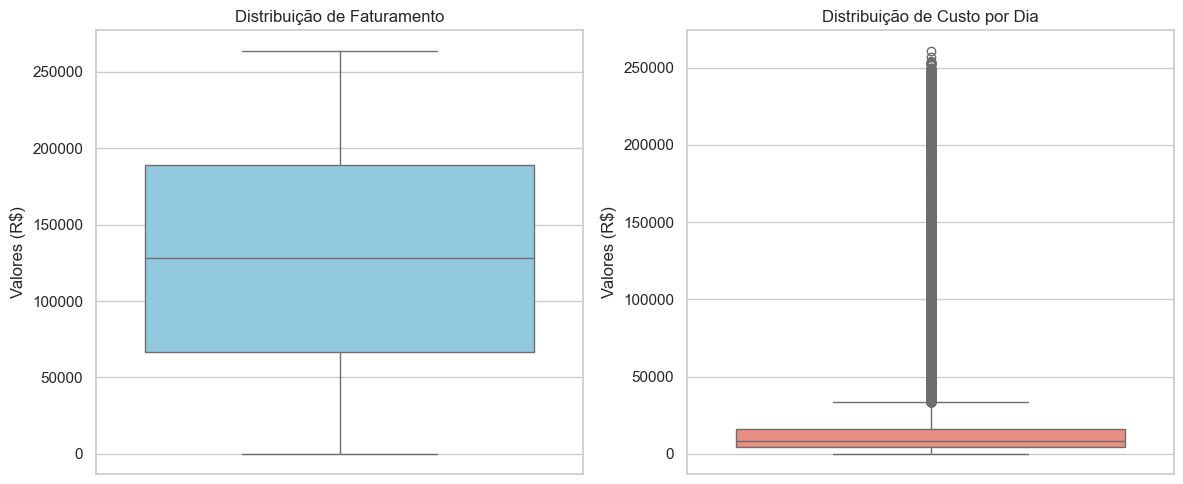

In [17]:
# === FEATURE ENGINEERING: CASOS CATASTRÓFICOS ===

# --- 1. Criação da Feature 'is_catastrophic_case'
# Nota Técnica: custos diários acima de Q3 classificados como casos catastróficos
# Nota de Negócio: feature permite analisar os acionamentos de alto custo diário

# --- 2. Cálculo do IQR para Custo por Dia
Q1 = df_clean['cost_per_day_br'].quantile(0.25)
Q3 = df_clean['cost_per_day_br'].quantile(0.75)
IQR = Q3 - Q1

# --- 3. O limite superior define onde começam os outliers
limite_superior = Q3 + 1.5 * IQR

# --- 4. Criação da feature binária
df_clean['is_catastrophic_case'] = (df_clean['cost_per_day_br'] > limite_superior).astype(int)

print("✅ Criação da Feature 'is_catastrophic_case' Concluída\n" + '=' * 65)
print(f"▶ Casos acima de R$ {limite_superior:.2f} foram marcados como catastróficos")
print(f"▶ Quantidade de Casos Catastróficos: {df_clean['is_catastrophic_case'].sum()} de {len(df_clean)} registros")
print(f"▶ Representatividade de Casos Catastróficos: {df_clean['is_catastrophic_case'].mean() * 100:.2f}%")


# --- 5. Visualização dos Dados

# Nota Técnica: boxplot para análise de custos por internação 
# e por dia para análise de outliers

# Criação a área do gráfico para dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Boxplot para Faturamento
sns.boxplot(y=df_clean['billing_amount_br'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Faturamento')
axes[0].set_ylabel('Valores (R$)')

# --- Plot 2: Boxplot para Custo por Dia
sns.boxplot(y=df_clean['cost_per_day_br'], ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Custo por Dia')
axes[1].set_ylabel('Valores (R$)')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/7_plot_custos_total_e_diario.png', dpi=300)
plt.show()

**`Análise da Feature: 'is_catastrophic_case' (Casos Catastróficos)`**

* Boxplot Faturamento Total: comportamento simétrico, com dispersão contida e ausência absoluta de outliers, refletindo a distribuição uniforme.
* Boxplot Custo Diário: revela um cenário completamente oposto, com uma expressiva quantidade de outliers, alcançando picos severos que superam R$ 250.000 por dia.

**Nota Técnica:**
* Os outliers representam exatos 6.187 registros (11,17% da carteira) operando sob a condição de picos diários severos.
* Assim como o tempo de permanência, *a flag is_catastrophic_case é um desfecho pós-alta e não entrará no treinamento dos modelos preditivos para evitar Data Leakage.*

**Insight de Negócio:**
* Ter 11.17% da carteira (6.127 registros) classificada como caso catastrófico traz um alerta importante. Os casos representam internações curtas, nas quais o custo total foi dividido por poucos dias. Para o negócio, isso significa que *o maior dreno financeiro diário da operadora vem de pacientes agudos de alta complexidade que entram, realizam procedimentos de alto custo e tem alta rápida.*
* Modelo de *auditoria concorrente é ideal para os casos catastróficos*. Controlar o protocolo clínico nas primeiras 48 horas desses casos agudos é onde as empresas conseguirão mitigar o custo alto.
* Modelos de cobrança Fee-for-Service (pagamento por item utilizado/diária aberta) deixa a operadora mais vulnerável a picos inflacionários de insumos logo no início da internação.
* Ações Estratégicas Sugeridas: 
     1. Disparar o gatilho de auditoria concorrente imediatamente nas primeiras 24/48 horas para esses perfis agudos identificados pelo modelo de IA na admissão.
     2. Migrar a contratualização da rede credenciada para modelos de Diárias Globais ou DRG (Diagnosis Related Groups) focados em procedimentos agudos previsíveis, blindando a operadora contra picos diários superiores a R$ 200.000.

**Ação (Próximo Passo):**
* Analisar a correlação e matriz de contingência entre o Diagnóstico Médico Primário ('medical_condition') e o principal medicamento prescrito na entrada ('medication'), visando identificar se a combinação de ambos na admissão é o real gatilho preditivo desses casos catastróficos.

✅ Criação da Feature 'condition_medication' Concluída

▶ Análise de Longa Permanência e Custos por Condição/Medicamento:


,custo_diario_medio,total_pacientes,casos_long_stay,taxa_proporcao
condition_medication,,,,
Arthritis_Ibuprofen,R$ 18434.19,1804,414,22.95%
Asthma_Penicillin,R$ 18238.37,1824,440,24.12%
Hypertension_Lipitor,R$ 18100.47,1818,412,22.66%
Obesity_Aspirin,R$ 18008.25,1848,403,21.81%
Hypertension_Ibuprofen,R$ 17960.43,1869,404,21.62%
Obesity_Ibuprofen,R$ 17932.45,1833,418,22.80%
Obesity_Penicillin,R$ 17796.49,1869,410,21.94%
Diabetes_Penicillin,R$ 17657.63,1859,442,23.78%
Diabetes_Paracetamol,R$ 17636.70,1791,426,23.79%


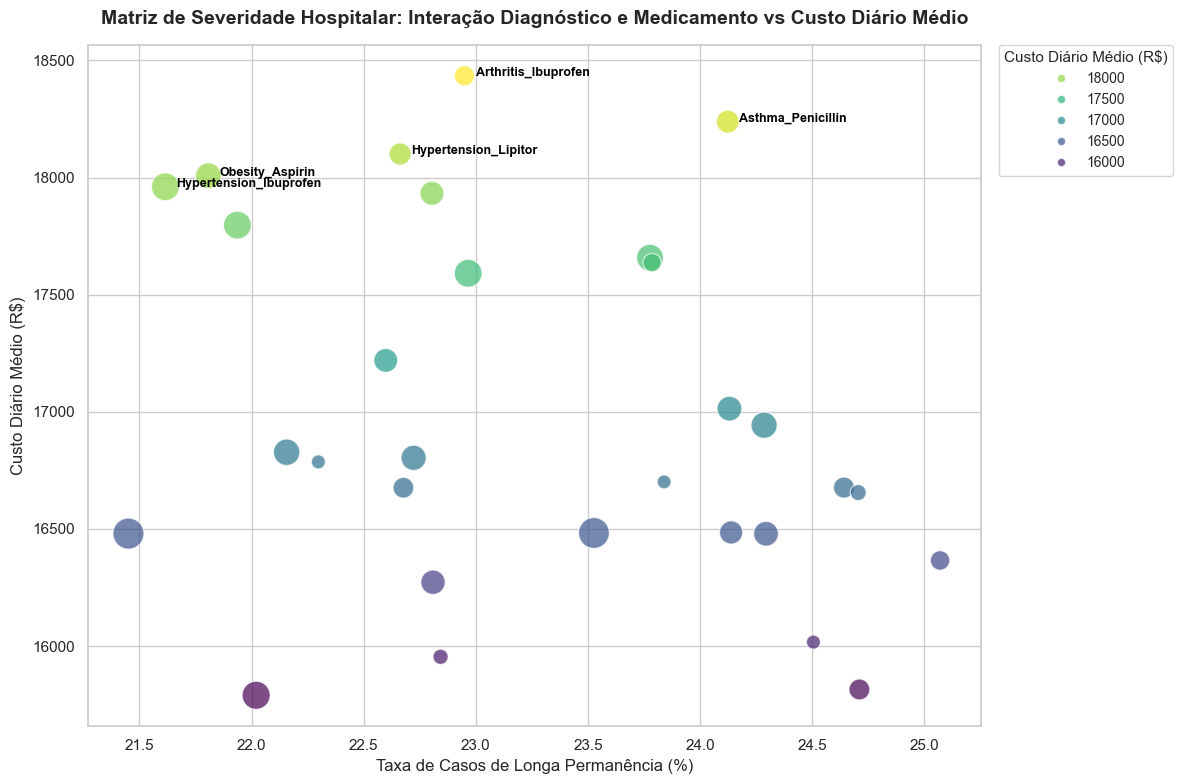

In [18]:
# === FEATURE ENGINEERING: INTERAÇÃO DIAGNÓTICO E MEDICAÇÃO ===

# --- 1. Criação da Feature 'condition_medication'
# Nota Técnica: feature de agrupamento para avaliar a interação Diagnóstico X Medicamento X Custo Diário
# Nota de Negócio: interação combinada de diagnóstico e medicamentos pode indicar alto custo
df_clean.loc[:, 'condition_medication'] = df_clean['medical_condition'] + '_' + df_clean['medication']

print("✅ Criação da Feature 'condition_medication' Concluída")
print('=' * 90)

print("\n▶ Análise de Longa Permanência e Custos por Condição/Medicamento:\n" + '=' * 90)

# --- 2. Agrupamento usando dicionário para especificar a métrica de cada coluna
df_analise = df_clean.groupby('condition_medication').agg(
    custo_diario_medio=('cost_per_day_br', 'mean'),           # custo diário médio
    total_pacientes=('is_long_stay', 'count'),                # total de pacientes
    casos_long_stay=('is_long_stay', 'sum'),                  # casos de longa permanência (>23 dias)
    taxa_proporcao=('is_long_stay', 'mean')                   # % de internação prolongada no referido grupo
).round(4)

# --- 3. Formatação visual da taxa em porcentagem
df_analise['taxa_proporcao'] = (df_analise['taxa_proporcao'] * 100).map('{:.2f}%'.format)

# --- 4. Formatação visual do custo em Real brasileiro (R$)
df_analise['custo_diario_medio'] = df_analise['custo_diario_medio'].map('R$ {:.2f}'.format)

# --- 5. Ordena pelos grupos que geram mais casos de internação longa
df_analise = df_analise.sort_values(by='custo_diario_medio', ascending=False)

display(df_analise)


# --- 6. Visualização dos Dados

# --- Plot: Gráfio de Dispersão
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Agrupamento, cálculo percentual e ordenação integrados em um único pipeline
df_plot_scatter = (                                     
    df_clean.groupby('condition_medication')            # agrupa df_clean com base na coluna 'condition_medication'
    .agg(                                               # inicia a função de agregação para calcular as estatísticas
        custo_diario_medio=('cost_per_day_br', 'mean'), # cria coluna e calcula a média do custo diário de cada grupo
        total_pacientes=('is_long_stay', 'count'),      # cria coluna e conta o total de pacientes de cada grupo
        taxa_proporcao=('is_long_stay', 'mean')         # cria coluna e calcula a taxa de proporção de internação prolongada por grupo
    )
    .assign(taxa_proporcao=lambda x: x['taxa_proporcao'] * 100) # multiplica a taxa de proporção por 100 para porcentagem real
    .sort_values(by='custo_diario_medio', ascending=False)      # ordenação decrescente por custo médio diário
    .reset_index()                                              # transforma o grupo em coluna e recria o índice numérico
)

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Plot de dispersão (Bubble Chart)
sns.scatterplot(
    data=df_plot_scatter,
    x='taxa_proporcao',
    y='custo_diario_medio',
    size='total_pacientes',
    hue='custo_diario_medio',
    palette='viridis',
    sizes=(100, 500),
    alpha=0.7,
    ax=ax
)

# Anotações Estratégicas (Top 5 Grupos Mais Caros)
for _, row in df_plot_scatter.head(5).iterrows():  # loop que percorre as 5 primeiras linhas (as mais caras devido à ordenação anterior)
    ax.text(                                       # adiciona um texto personalizado diretamente no gráfico (eixos ax)
        x=row['taxa_proporcao'] + 0.05,            # posição X do texto (com leve recuo à direita para não colar no ponto)
        y=row['custo_diario_medio'],               # posição Y do texto (exatamente na altura do custo médio do grupo)
        s=row['condition_medication'],             # o conteúdo do texto, que será o nome da condição médica (rótulo)
        fontsize=9,                                
        fontweight='semibold',                     
        color='black'                              
    )

# Customização de rótulos e títulos executivos
ax.set_title('Matriz de Severidade Hospitalar: Interação Diagnóstico e Medicamento vs Custo Diário Médio', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Taxa de Casos de Longa Permanência (%)', fontsize=12)
ax.set_ylabel('Custo Diário Médio (R$)', fontsize=12)

# Ajuste e formatação da legenda
handles, labels = ax.get_legend_handles_labels()

# Captura os elementos de custo (posições 1 a 5) e inverte do maior para o menor
ax.legend(                             # customiza a legenda do gráfico
    handles[5:0:-1],                   # seleciona e inverte a ordem dos elementos visuais (bolhas/linhas) da legenda
    labels[5:0:-1],                    # seleciona e inverte a ordem dos textos correspondentes aos elementos anteriores
    title="Custo Diário Médio (R$)",   # define o título explicativo da seção da legenda
    loc='upper left',                  # define o ponto de ancoragem da caixa da legenda como o seu canto superior esquerdo
    bbox_to_anchor=(1.02, 1),          # posiciona a legenda fora do gráfico
    borderaxespad=0,                   # remove o espaçamento interno padrão entre a borda do gráfico e a legenda
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.savefig('plots/8_plot_matriz_severidade_diagnostico_medicao.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'condition_medication' (Interação Diagnóstico e Medicação vs Custo Diário Médio)`**

* A Matriz de Severidade Hospitalar permitiu isolar o risco combinado de diagnósticos e esquemas terapêuticos, e permitiu isolar o comportamento financeiro e operacional das interações clínicas.
* O grupo Arthritis_Ibuprofen assumiu o pico de maior custo diário médio (R$ 18.385,54), enquanto o grupo Asthma_Penicillin consolidou-se na zona de maior criticidade combinada, associando alto custo diário (R$ 18.209,05) a uma das maiores taxas de conversão para longa permanência (24.12%).

**Nota Técnica:**
* O total de pacientes (representado pela dimensão das bolhas) está distribuído de forma homogênea pelo gráfico, provando que os grupos com alta frequência de ocorrência (bolhas maiores) não são necessariamente os mais caros ou os que passam mais tempo internados.
* Embora o gráfico sugira forte dispersão, nota-se que o eixo X está restrito a uma janela estreita (21.5% a 25.0%). Essa oscilação pequena *indica que a probabilidade de um paciente evoluir para uma internação prolongada é estatisticamente semelhante entre os grupos, transferindo o real peso de diferenciação para o eixo Y (Custo Diário).*

**Insight de Negócio:**
* A combinação Asthma_Penicillin (Asma com Penicilina) ocupa zona de alto risco. Crises de asma severas que exigem antibioticoterapia prolongada indicam infecções respiratórias secundárias graves. A operadora de saúde pode criar um *Programa de Gestão de Pacientes Asmáticos Crônicos, oferecendo acompanhamento ambulatorial preventivo e vacinação pneumocócica fora do hospital, a fim de evitar que esse paciente descompense e precise de internação, reduzindo os maiores picos de sinistralidade da carteira.*

**Ação (Próximo Passo):**
* Investigar linha de tendência dos grupos ('medical_condition') por dias de internação ('length_of_stay') e custo diário ('cost_per_day_br'), para avaliar a distribuição de custo ao longo dos dias de internação.


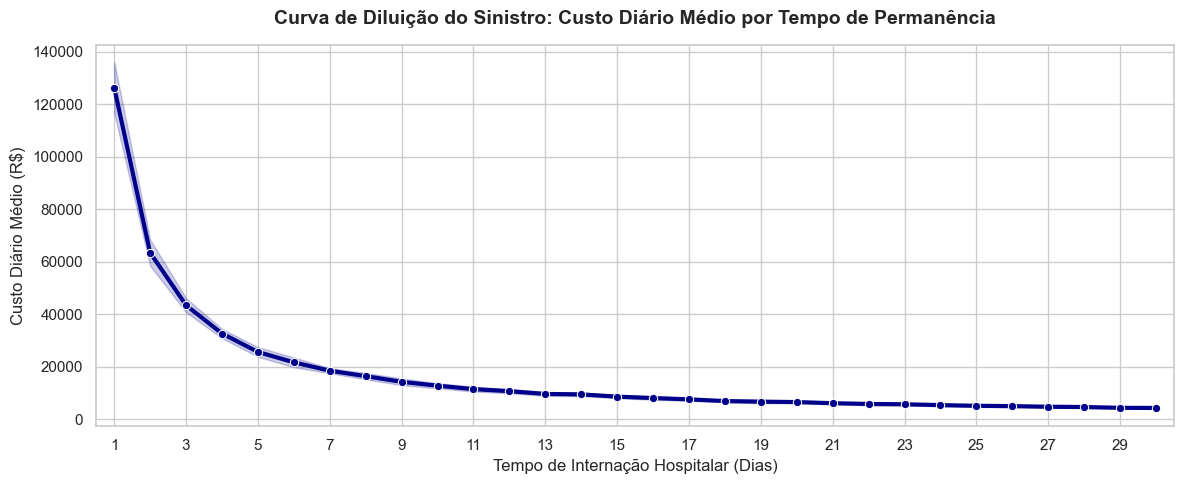

In [19]:
# === INTERAÇÃO DIAS DE INTERNAÇÃO, DIAGNÓTICO E MEDICAÇÃO VS CUSTO DIÁRIO ===

# --- Plot: Gráfio de Linha de Tendência Agregada

# Configuração do Estilo Visual
sns.set_theme(style="whitegrid")
# Agrupamendo apenas por tempo de internação para pegar o comportamento geral da carteira
df_tendencia = (
    df_clean.groupby(                                
        ['condition_medication', 'length_of_stay']) # agrupa os dados combinando a condição médica e o tempo de internação (em dias)
    .agg(                            
        custo_diario_medio=('cost_per_day_br', 'mean')) # cria coluna e calcula a média do custo diário para cada combinação única
    .reset_index()                                      # transforma ambas as colunas agrupadas de volta em colunas comuns e recria o índice
)

# Construção do Gráfico de Linha (Tendência de Diluição)
fig, ax = plt.subplots(figsize=(12, 5))

# O lineplot com estimador cria a linha média e a sombra do intervalo de variação
sns.lineplot(
    data=df_tendencia,
    x='length_of_stay',
    y='custo_diario_medio',
    color='darkblue',
    linewidth=3,
    marker='o',         # adiciona pontos na linha para marcar cada dia
    markersize=6,
    errorbar='sd',      # desenha uma sombra mostrando o desvio padrão (variação entre patologias)
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Curva de Diluição do Sinistro: Custo Diário Médio por Tempo de Permanência', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Tempo de Internação Hospitalar (Dias)', fontsize=12)
ax.set_ylabel('Custo Diário Médio (R$)', fontsize=12)

# Ajuste dos limites do eixo x
ax.set_xlim(0.5, 30.5)
ax.set_xticks(range(1, 31, 2)) # mostra os dias de 2 em 2

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/9_plot_curva_tendencia_diluicao_sinistro.png', dpi=300, bbox_inches='tight')
plt.show() 


**`Análise da Feature: 'condition_medication' (Interação Diagnóstico e Medicação vs Custo Diário Médio por Tempo de Permanência)`**

*  O gráfico comprova que a relação entre o tempo de internação (length_of_stay) e o custo diário médio (cost_per_day_br) segue rigorosamente o comportamento de uma hipérbole de diluição matemática. Há um pico agressivo no Dia 1 (~R$ 126.000/dia), seguido por um decréscimo abrupto até o Dia 3 (~R$ 43.000/dia), perdendo inclinação gradativamente à medida que o tempo avança.
* A faixa sombreada (azul) ao redor da linha representa o intervalo de variação entre as diferentes combinações de patologias e medicações. O fato de a sombra ser extremamente estreita e simétrica confirma que, nesta base de dados, a complexidade diagnóstica isolada possui baixo poder de diferenciação, sendo o tempo de permanência o vetor soberano na determinação do custo diário.

**Nota Técnica:**
* A partir do 23º dia (threshold definido para a feature 'is_long_stay' via percentil 75%), a curva perde inclinação e atinge um "plateau" estável de custo mínimo. Isso *valida matematicamente que a regra de corte de 23 dias separa com precisão o momento em que o paciente deixa de gerar variação financeira expressiva para a operadora e passa a ter um custo de manutenção linear.*

**Insight de Negócio:**
* No início da internação (Dias 1 a 5), concentram-se as maiores pressões financeiras do sinistro (taxas cirúrgicas, exames de urgência, OPME e terapias de ataque). O decréscimo da curva não significa que o hospital ficou "mais barato" com o tempo, mas sim que o custo fixo inicial está sendo diluído por um denominador maior.
* Os *primeiros dias concentram a volatilidade financeira e a agressividade dos custos, assim, concentrar os esforços de auditoria concorrente e protocolos de desospitalização preventiva (como a transição para Home Care) devem ser intensificados justamente na primeira semana de internação, onde há maior espaço para negociar pacotes de procedimentos e evitar desperdícios assistenciais antes que o custo diário seja diluído pelo tempo.*

**Ação (Próximo Passo):**
* Executar a última verificação da EDA: Análise de Sazonalidade por Mês de Admissão ('date_of_admission'), avaliando se existem picos sazonais de internação ao longo do ano que possam impactar o planejamento atuarial e a alocação de recursos da operadora.

✅ Análise do Período Analisado Concluída:
* Data Mínima: 2019-05-08 00:00:00.
* Data Máxima: 2024-05-07 00:00:00.

▶ Volume Acumulado de Internações por Mês (Período de 5 anos):
Mês 01 | Total de Admissões: 4646   | Média Anual Estimada: 774
Mês 02 | Total de Admissões: 4199   | Média Anual Estimada: 699
Mês 03 | Total de Admissões: 4610   | Média Anual Estimada: 768
Mês 04 | Total de Admissões: 4466   | Média Anual Estimada: 744
Mês 05 | Total de Admissões: 4547   | Média Anual Estimada: 757
Mês 06 | Total de Admissões: 4640   | Média Anual Estimada: 773
Mês 07 | Total de Admissões: 4762   | Média Anual Estimada: 793
Mês 08 | Total de Admissões: 4777   | Média Anual Estimada: 796
Mês 09 | Total de Admissões: 4503   | Média Anual Estimada: 750
Mês 10 | Total de Admissões: 4605   | Média Anual Estimada: 767
Mês 11 | Total de Admissões: 4501   | Média Anual Estimada: 750
Mês 12 | Total de Admissões: 4604   | Média Anual Estimada: 767


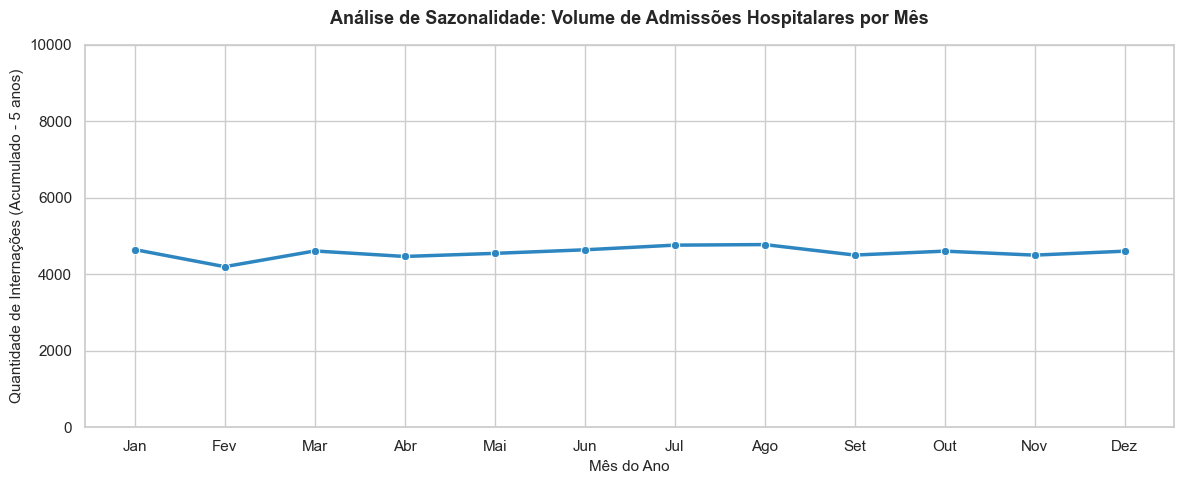

In [20]:
# === FEATURE ENGINEERING: MÊS DE ADMISSÃO (ANÁLISE DE SAZONALIDADE) ===

# --- 1. Análise do período analisado
print("✅ Análise do Período Analisado Concluída:\n" + '=' * 45)
print(f"* Data Mínima: {df_clean['date_of_admission'].min()}.")
print(f"* Data Máxima: {df_clean['date_of_admission'].max()}.")

# --- 2. Extração do Mês e do Ano da data de admissão
df_clean.loc[:, 'admission_month'] = df_clean['date_of_admission'].dt.month

# --- 3. Agrupamento para contar o volume de internações por mês (Acumulado dos 5 anos)
sazonalidade = df_clean['admission_month'].value_counts().sort_index()

print("\n▶ Volume Acumulado de Internações por Mês (Período de 5 anos):")
print('=' * 70)
for mes, qtd in zip(sazonalidade.index, sazonalidade.values):
    print(f"Mês {mes:02d} | Total de Admissões: {qtd:<6} | Média Anual Estimada: {int(qtd/6)}")
print('=' * 70)

# --- 4. Visualização dos Dados

# --- Plot: Gráfico de Linha (Análise Temporal)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Plot da linha com marcadores nos pontos
sns.lineplot(x=sazonalidade.index, y=sazonalidade.values, marker='o', color='#2E86C1', linewidth=2.5, ax=ax)

# Customização de títulos e rótulos para apresentação
ax.set_title('Análise de Sazonalidade: Volume de Admissões Hospitalares por Mês', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mês do Ano', fontsize=11)
ax.set_ylabel('Quantidade de Internações (Acumulado - 5 anos)', fontsize=11)
ax.set_ylim(0, 10000)

# Configurando o eixo X para exibir os nomes dos meses
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/10_plot_sazonalidade_internacoes.png', dpi=300)
plt.show()

**`Análise da Feature: 'admission_month' (Mês de Admissão - Análise de Sazonalidade)`**

* A variável do mês de internação ('month') não possui relevância estatística ou variabilidade real capaz de influenciar o custo, trata-se de ruído estatístico para o modelo.
* O discreto recuo observado no mês de fevereiro decorre do efeito calendário (menor quantidade de dias para acúmulo de registros históricos), mantendo a taxa diária de admissão constante.

**Nota Técnica:** 
* A ausência completa de picos ou vales sazonais confirma que a variável temporal mensal opera como ruído estatístico. Do ponto de vista de engenharia de dados e modelagem, *a feature de mês de admissão será descartada da matriz de preditores ($X$),* blindando os algoritmos de boosting e árvores contra a captura de falsos padrões (overfitting).

**Insight de Negócio:** 
* No ecossistema de saúde suplementar real, a sazonalidade é um fator crítico (ex: surtos de síndromes respiratórias sazonais inflando a pediatria no primeiro semestre). Para esta carteira específica, contudo, a demanda e a severidade assistencial comportam-se de forma perene e homogênea durante todo o ano.
* Sob a ótica financeira, a operadora desfruta de um cenário ideal para o provisionamento de caixa e sinistralidade. Não há necessidade de criar colchões de liquidez para "meses de sufoco assistencial", permitindo um planejamento de Capex e Opex linearizado.

**Ação (Próximo Passo):**
* Conclusões da EDA e definição do Planejamento de Modelagem.



### 1.3 Resumo Executivo: Etapa 1 - Análise Exploratória dos Dados

**1. LIMPEZA E TRATAMENTO DOS DADOS**


| Etapa / Iniciativa | Ação Aplicada | Impacto / Justificativa de Negócio | Métrica / Resultado |
| :--- | :--- | :--- | :--- |
| **Padronização de Nomenclatura** | 1. Conversão dos nomes das colunas (*lowercase + separação das palavras por underscore*); <br> 2. Conversão dos registros da coluna `name` para letras minúsculas (*lowercase*). | Elimina duplicidades ocultas geradas por inconsistências de digitação. | **100% das colunas** e nomes padronizados em caixa baixa. |
| **Tipagem de Variáveis** | Conversão de `date_of_admission` e `discharge_date` de tipo texto (*object*) para `datetime64[ns]`. | Permite a execução de cálculos matemáticos e lógicos utilizando eixos temporais. | Tipagem corrigida para **Datetime**. |
| **Ajuste Numérico** | Formatação do faturamento bruto (`billing_amount`) para duas casas decimais (`.2f`). | Alinhamento com o padrão financeiro de análise de custos médicos. | Valores normalizados em escala monetária. |
| **Tratamento de Duplicados** | Identificação e remoção de linhas 100% idênticas no banco de dados. | Eliminação de registros redundantes causados por possíveis falhas de integração ou reenvio de lotes de guias. | **534 linhas duplicadas removidas** (Base reduzida para 54.966 linhas). |
| **Consistência Temporal** | Validação da regra de negócio: Data de Alta $\ge$ Data de Admissão. | Garantia de integridade cronológica dos eventos assistenciais de saúde. | **0 inconsistências** detectadas. |
| **Tratamento de Anomalias (Valores Negativos)** | Exclusão de 106 registros com faturamento menor que zero (`billing_amount < 0`). | Eliminação de ruídos (glosas médicas totais ou erros de sistema) que distorceriam a modelagem de custo bruto do sinistro. | **106 linhas removidas** (0.19% da base). Base final: **54.860 linhas**. |


**2. ENGENHARIA DE FEATURES (*FEATURE ENGINEERING*)**

A tabela abaixo consolida o mapeamento estatístico, as justificativas de negócio e os direcionamentos estratégicos de modelagem para cada uma das variáveis desenvolvidas durante a fase exploratória.

| Feature | Definição Estatística / Fórmula | Justificativa de Negócio | Impacto e Resultado de Negócio |
| :--- | :--- | :--- | :--- |
| **`length_of_stay`** | Subtração das datas de atendimento (`Alta - Admissão`). | Geração do indicador contínuo de **Tempo de Internação**, um dos principais vetores de custo hospitalar. | Variável gerada com **média de 15,5 dias** de permanência (Mín: 1 / Máx: 30). <br> ▶ *`Modelagem:`* **Descontinuada** do pipeline preditivo para evitar *Data Leakage* na admissão. |
| **`billing_amount_br`** | Aplicação de taxa de câmbio média estável *(Fator: 5.00)*. | Alinhamento do **Target (Variável Alvo)** com a realidade financeira do mercado de saúde suplementar brasileiro. | Escala convertida para Real brasileiro, com **faturamento médio de R$ 127.950,42**  por internação. |
| **`cost_per_day_br`** | Divisão do faturamento bruto em Reais pelo tempo de permanência (`billing_amount_br / length_of_stay`). | Normalização de custos, permitindo diferenciar o consumo diário por intensidade de recursos. | **[VARIÁVEL ALVO]** Média de R$ 16.965,57 (Mediana: R$ 8.255,19). Forte assimetria à direita (cauda longa) atingindo teto de R$ 261.059,25/dia. |
| **`age_group`** | Agrupamento etário em 10 intervalos regulatórios com base na RN nº 563 da ANS. | Mapeamento demográfico para capturar variações de risco assistencial por ciclo de vida. | * Concentração massiva no grupo de 59 anos ou mais (39,56%). Custos e permanência mantiveram-se homogêneos entre as faixas. <br> * age_group será retida apenas para fins de BI. <br> ▶ *`Modelagem:`* **feature original 'age' retida.** Será utilizada em seu formato original para modelagem, pois agrupada pode apresentar baixa relevância (*feature importance*) por falta de quebra de variância. |
| **`is_weekend_admission`** | Identificação de internações ocorridas aos sábados e domingos, mapeadas a partir da data de admissão. | Avaliação do impacto da sazonalidade semanal (plantões e restrições operacionais de exames) na flutuação de custos. | Não apresentou variação estatística (custo estável em **~R$ 16.900,00/dia** na semana e no fim de semana).<br> ▶ *`Modelagem:`* **Feature Descontinuada** Feature Descontinuada por parcimônia (ausência de ganho de informação). |
| **`is_long_stay`** | Flag binária para internações acima do terceiro quartil ($> 23$ dias). | Segmentação diagnóstica entre o comportamento de sinistros agudos e internações prolongadas. | *Identificou o efeito diluição:* grupo curto retém severidade diária de R$ 20.674,54/dia e o longo cai para R$ 4.743,46/dia. <br> ▶ *`Modelagem:`* **Descontinuada** (informação do futuro). |
| **`condition_medication`** | Combinação categórica de Diagnóstico Clínico + Protocolo Farmacológico. | Mapeamento da complexidade do sinistro com base no cruzamento da patologia com o tratamento aplicado. | Consolidação de 30 combinações únicas, destacaram-se discretamente os grupos Arthritis_Ibuprofen (maior custo diário) e Asthma_Penicillin (zona de alta severidade combinada). <br>  ▶ *`Modelagem`* **Retida** inicialmente, via One-Hot Encoding. |
| **`is_catastrophic_case`** | Flag binária para custos diários superiores ao limite estatístico de outliers ($> R\$ 33.702,51$). | Isolamento de sinistros severos para mapeamento de risco de cauda (tail risk) e acionamento de auditoria médica. | Identificou 6.187 casos (11,17% da carteira) que concentram o real dreno financeiro diário da operadora.<br> ▶ *`Modelagem:`* **Descontinuada** do pipeline preditivo para evitar Data Leakage, retida apenas para fins de BI. |
| **`admission_month`** | Extração do mês de admissão para avaliar ciclos sazonais de volume assistencial ao longo dos anos. | Identificação de picos sazonais de frequência (como surtos de inverno) para provisionamento de caixa. | Distribuição uniforme estável entre os meses, com leve oscilação em fevereiro devido ao efeito calendário. <br> ▶ *`Modelagem:`* **Feature Descontinuada** devido à variação insignificante, caracterizando ruído de dados. |

In [21]:
### === Planejamento Estratégico de Modelagem (Regressão) ===

display(Markdown("### **3. PLANEJAMENTO ESTRATÉGICO DE MODELAGEM (*REGRESSÃO*)**"))

# --- 1. Definição Estratégica da Target
definicao_target = {
    'Definição da Target': [
        'Escolhida: cost_per_day_br', 
        'Descartada: billing_amount_br'
        ],
    'Justificativa': [
        'A normalização pelo tempo permite isolar a real severidade diária da internação, capturando os picos inflacionários causados por eventos agudos de alta complexidade',
        'Descartada pois o faturamento bruto uniforme amortece o sinal analítico, ocultando a volatilidade e o risco de cauda no decorrer dos dias'
    ]
}
display(Markdown("### === Definição Estratégica da Variável Alvo (Target) ==="))
display(pd.DataFrame(definicao_target))
display(Markdown("\n---\n"))

# --- 2. Definição das Estratégias de Pipeline
estrategia = {
    'Pipeline': ['01', '02', '03', '04', '05', '06', '07', '08'],
    'Modelo': [
        'Linear Regression', 
        'K-Neighbors Regressor (KNN)', 
        'Linear Support Vector Regressor (LinearSVR)', 
        'Multilayer Perceptron (MLP Neural Network)',
        'Random Forest Regressor', 
        'LightGBM Regressor', 
        'CatBoost Regressor', 
        'XGBoost Regressor'
    ],
    'Objetivo': [
        'Baseline Estatístico de Machine Learning', 
        'Abordagem Baseada em Distância e Vizinhança', 
        'Otimização de Hiperplano de Margem Máxima', 
        'Rede Neural Artificial para Captura de Padrões Complexos',
        'Ensemble de Árvores (Bagging) / Não-Linearidade', 
        'Alta Performance Computacional (Boosting)', 
        'Performance Otimizada para Variáveis Categóricas', 
        'Alta Performance Geral (Extreme Gradient Boosting)'
    ],
    'Pré-Processamento Obrigatório': [
        'One-Hot Encoding + Standard Scaling',
        'One-Hot Encoding + Standard Scaling',
        'One-Hot Encoding + Standard Scaling',
        'One-Hot Encoding + Standard Scaling',
        'One-Hot Encoding',
        'Tratamento de Categóricas Nativo',
        'Tratamento de Categóricas Nativo',
        'One-Hot Encoding'
    ],
    'Exige Escalonamento (Scaling)': ['Sim', 'Sim', 'Sim', 'Sim', 'Não', 'Não', 'Não', 'Não'],
}
display(Markdown("### === Arquitetura do Pipeline de Modelagem (Regressão) ==="))
display(pd.DataFrame(estrategia))
display(Markdown("\n---\n"))


# --- 3. Estratégia de Métricas para Avaliação da Performance dos Modelos
metricas = {
    'Tipo de Métrica': [
        'Estatística (Eixo Clínico)', 
        'Estatística (Eixo de Risco)', 
        'Estatística (Aderência)'
    ],
    'Métrica / Indicador': [
        'MAE (Mean Absolute Error)', 
        'RMSE (Root Mean Squared Error)', 
        'R² (Coefficient of Determination)'
    ],
    'Definição Estatística / Cálculo': [
        'Média da soma dos erros absolutos entre os valores reais e preditos.',
        'Raiz quadrada da média dos erros elevados ao quadrado (penaliza erros grandes).',
        'Percentual da variação dos custos reais que é explicada pelas variáveis do modelo.'
    ],
    'Objetivo / Interpretação de Negócio': [
        'Avaliar o erro médio do modelo diretamente em Reais por diária (fácil leitura executiva).',
        'Penalizar severamente grandes desvios de previsão, sinalizando falhas nos custos mais severos.',
        'Mensurar o percentual de variabilidade do custo diário hospitalar que o modelo consegue explicar.'
    ]
}
display(Markdown("### === Matriz de Avaliação e Métricas Estatísticas ==="))
display(pd.DataFrame(metricas))

### **3. PLANEJAMENTO ESTRATÉGICO DE MODELAGEM (*REGRESSÃO*)**

### === Definição Estratégica da Variável Alvo (Target) ===

,Definição da Target,Justificativa
0,Escolhida: cost_per_day_br,"A normalização pelo tempo permite isolar a real severidade diária da internação, capturando os picos inflacionários causados por eventos agudos de alta complexidade"
1,Descartada: billing_amount_br,"Descartada pois o faturamento bruto uniforme amortece o sinal analítico, ocultando a volatilidade e o risco de cauda no decorrer dos dias"



---


### === Arquitetura do Pipeline de Modelagem (Regressão) ===

,Pipeline,Modelo,Objetivo,Pré-Processamento Obrigatório,Exige Escalonamento (Scaling)
0,01,Linear Regression,Baseline Estatístico de Machine Learning,One-Hot Encoding + Standard Scaling,Sim
1,02,K-Neighbors Regressor (KNN),Abordagem Baseada em Distância e Vizinhança,One-Hot Encoding + Standard Scaling,Sim
2,03,Linear Support Vector Regressor (LinearSVR),Otimização de Hiperplano de Margem Máxima,One-Hot Encoding + Standard Scaling,Sim
3,04,Multilayer Perceptron (MLP Neural Network),Rede Neural Artificial para Captura de Padrões Complexos,One-Hot Encoding + Standard Scaling,Sim
4,05,Random Forest Regressor,Ensemble de Árvores (Bagging) / Não-Linearidade,One-Hot Encoding,Não
5,06,LightGBM Regressor,Alta Performance Computacional (Boosting),Tratamento de Categóricas Nativo,Não
6,07,CatBoost Regressor,Performance Otimizada para Variáveis Categóricas,Tratamento de Categóricas Nativo,Não
7,08,XGBoost Regressor,Alta Performance Geral (Extreme Gradient Boosting),One-Hot Encoding,Não



---


### === Matriz de Avaliação e Métricas Estatísticas ===

,Tipo de Métrica,Métrica / Indicador,Definição Estatística / Cálculo,Objetivo / Interpretação de Negócio
0,Estatística (Eixo Clínico),MAE (Mean Absolute Error),Média da soma dos erros absolutos entre os valores reais e preditos.,Avaliar o erro médio do modelo diretamente em Reais por diária (fácil leitura executiva).
1,Estatística (Eixo de Risco),RMSE (Root Mean Squared Error),Raiz quadrada da média dos erros elevados ao quadrado (penaliza erros grandes).,"Penalizar severamente grandes desvios de previsão, sinalizando falhas nos custos mais severos."
2,Estatística (Aderência),R² (Coefficient of Determination),Percentual da variação dos custos reais que é explicada pelas variáveis do modelo.,Mensurar o percentual de variabilidade do custo diário hospitalar que o modelo consegue explicar.


## **Etapa 2: Análise das Features para Modelagem**

In [22]:
# importar as bibliotecas

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [23]:
# conferência e cópia do dataset para preparar para modelagem
df_model = df_clean.copy()

print(df_model.columns)

print('=' * 50)
print("✅ Cópia de Segurança para Modelagem Concluída\n" + '=' * 50)
print(f"Colunas: {df_model.shape[0]}")
print(f"Linhas: {df_model.shape[1]}")

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results', 'length_of_stay', 'billing_amount_br',
       'cost_per_day_br', 'age_group', 'is_weekend_admission', 'is_long_stay',
       'is_catastrophic_case', 'condition_medication', 'admission_month'],
      dtype='object')
✅ Cópia de Segurança para Modelagem Concluída
Colunas: 54860
Linhas: 24


### 2.1 Seleção das Features para Modelagem

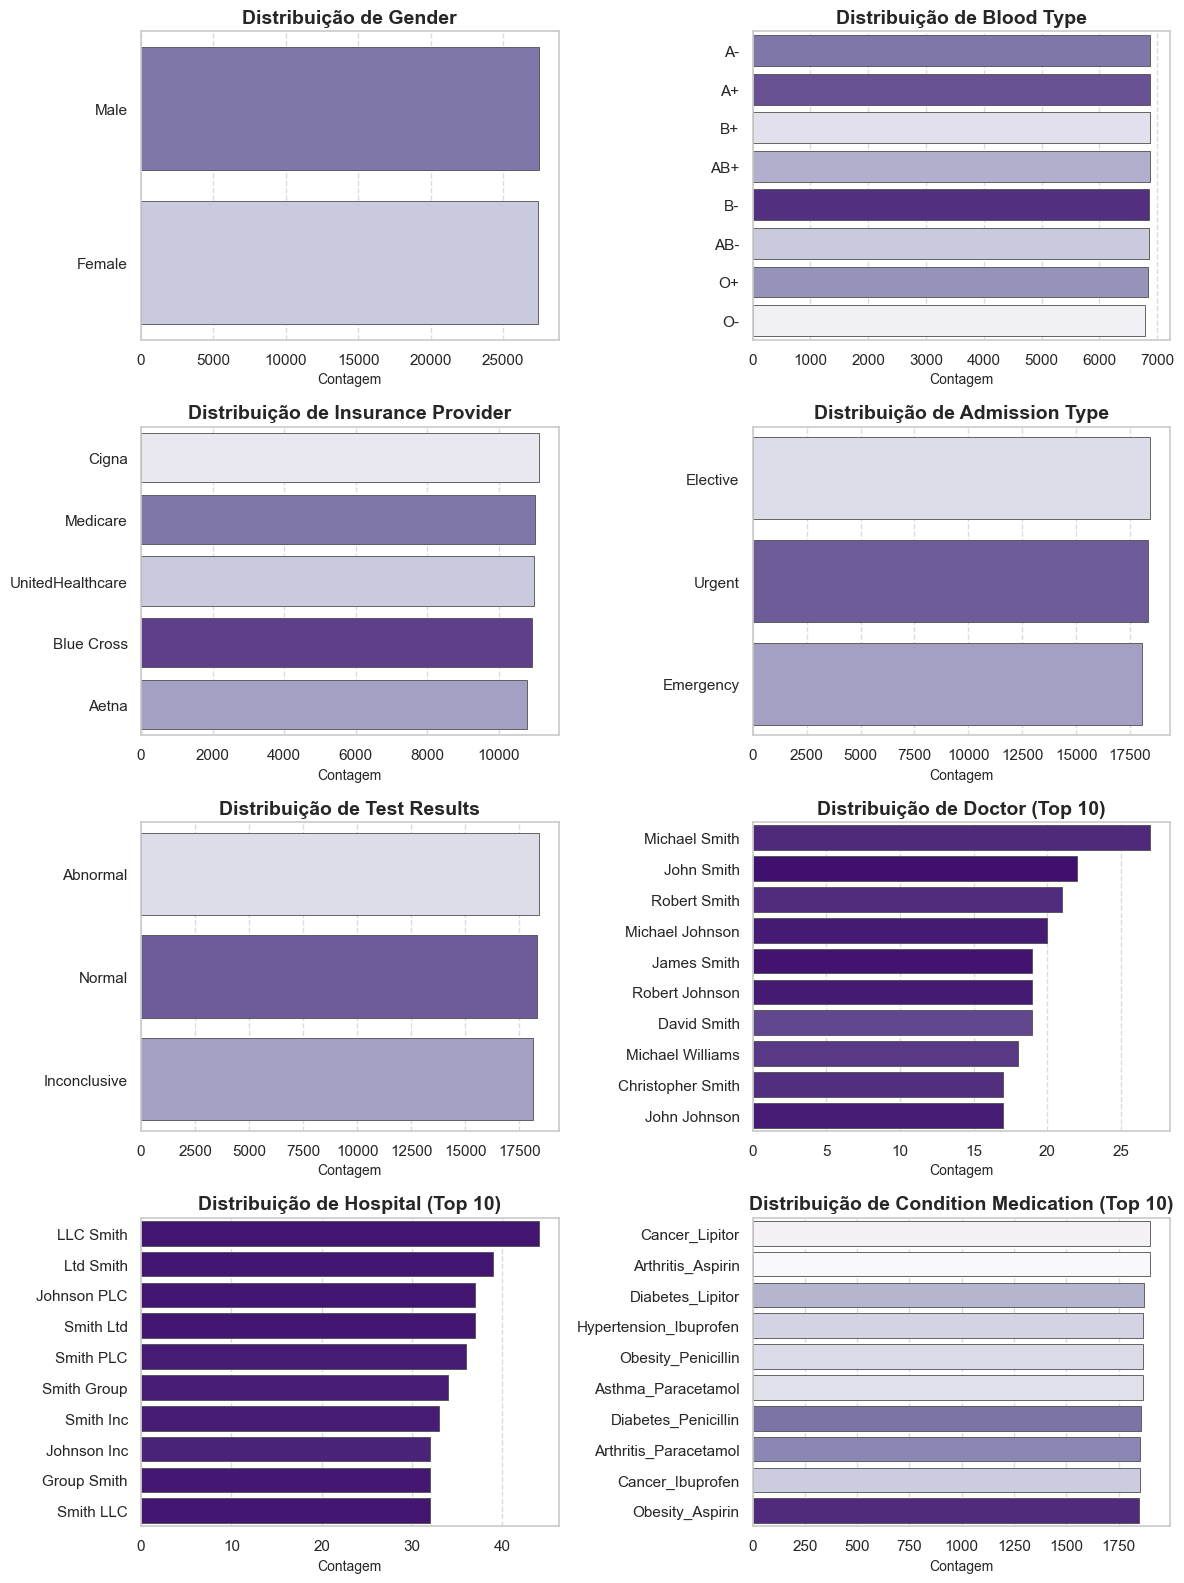

In [24]:
# === ANÁLISE DE DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS ===

# Lista das variáveis para análise
distribuicao_features = [
    "gender",
    "blood_type",
    "insurance_provider",
    "admission_type",
    "test_results",
    "doctor",
    "hospital",
    "condition_medication"
]

# Configura o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Criação da figura com 4 linhas e 2 colunas para plotagem
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))

# Achata a matriz de eixos para facilitar o loop (de 2D para 1D)
axes = axes.flatten()

# Loop para plotar cada variável
for i, feature in enumerate(distribuicao_features):
    # Conta a frequência e ordena as barras da maior para a menor
    order = df_model[feature].value_counts().index

    # Se a variável tiver muitos valores únicos,
    # mostra apenas os 10 mais frequentes
    if df_model[feature].nunique() > 10:
        order = order[:10]
        title_suffix = " (Top 10)"
    else:
        title_suffix = ""

    sns.countplot(
        data=df_model,
        y=feature,
        ax=axes[i],
        order=order,
        palette="Purples_r",
        hue=feature,
        legend=False,
        edgecolor="0.3",    # borda sutil para separar os tons de roxo
        linewidth=0.6
    )

    axes[i].set_title(
        f"Distribuição de {feature.replace('_', ' ').title()}{title_suffix}",
        fontsize=14,
        weight="bold",
    )
    axes[i].set_xlabel("Contagem", fontsize=10)
    axes[i].set_ylabel("")

    # Remove as linhas de grade verticais para o visual ficar mais minimalista
    axes[i].xaxis.grid(True, linestyle="--", alpha=0.7)
    axes[i].yaxis.grid(False)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/11_plot_distribuicao_features_cat.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise Visual e Estratégia de Seleção das Feature Categóricas`**

A análise visual do painel de distribuição de frequência das variáveis categóricas revela a assinatura típica do processo de geração de dados sintéticos da base original, exigindo critérios rigorosos de engenharia de recursos para a seleção dos preditores finais.

**Nota Técnica:**
* **Comportamento das Variáveis de Bloco:** as features `Gender`, `Blood Type`, `Insurance Provider`, `Admission Type`, `Test Results` e a combinação `Condition Medication` exibem uma distribuição de frequência perfeitamente uniforme (barras com volumes idênticos). Isso indica que a volumetria de exposição da carteira é homogênea entre os perfis.
* **O Fenômeno de Alta Cardinalidade (`Doctor` e `Hospital`):** O visual escalonado nos gráficos "Top 10" de médicos e instituições de saúde mascara um problema crítico de dados. Dado que o topo do ranking retém uma contagem mínima (~25 a 40 registros) em um universo de mais de 55 mil linhas, confirma-se a existência de milhares de categorias únicas com baixa representatividade amostral.

**Insight de Negócio:**
* A uniformidade volumétrica da base reflete um ecossistema artificializado onde não há "sazonalidade de demanda" por operadora ou por tipo de exame. Contudo, para a gestão assistencial, esse cenário isola perfeitamente o risco: como o volume de pacientes é igual em todas as frentes, a eficiência dos modelos de Machine Learning dependerá puramente da habilidade de extrair a severidade financeira a partir da gravidade clínica combinada na admissão.

**Ação (Próximo Passo):**
* Implementar a validação estatística formal no notebook através do teste **ANOVA (Analysis of Variance)** para quantificar matematicamente se há diferença significativa nas médias do custo diário (`cost_per_day_br`) entre as categorias das features retidas, chancelando cientificamente a matriz de design final ($X$) que alimentará os modelos.

In [25]:
# === AVALIAÇÃO DE IMPACTO E DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS ===

# Nota Técnica: O teste ANOVA (Análise de Variância) é utilizado aqui para comparar 
# se as médias da variável alvo ('cost_per_day_br') variam de forma estatisticamente 
# significativa entre as diferentes categorias de uma mesma variável preditora.
# Serve para validar se a feature quebra a variância do target ou se opera como ruído.

# Interpretação dos Resultados:
# --- p_value > 0.05 (Não Significativo): Não rejeita a hipótese nula (H0). 
#     As médias dos grupos/categorias são estatisticamente equivalentes (caracteriza ruído uniforme).
# --- p_value <= 0.05 (Significativo): Rejeita a hipótese nula (H0).
#     Pelo menos uma das categorias possui média de custo diário significativamente diferente das demais,
#     chancelando a presença de sinal preditivo útil para a modelagem.

print("========= ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES =========\n")

# --- 1. Definir explicitamente as features que passaram pela triagem visual
distribuicao_features = ['gender', 'blood_type', 'medical_condition', 'insurance_provider', 
                         'admission_type', 'medication', 'test_results', 'hospital', 'doctor', 'medical_condition']

# --- 2. Listas para armazenar as Features para Manter/Descartar
features_para_descartar = []
features_para_manter = []

# --- 3. Avaliação Estatística das Features para Manter ou Descartar da Modelagem
for col in distribuicao_features:
    if col in df_model.columns:
        print("=" * 90)
        print(f"📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: {col} | Cardinalidade: {df_model[col].nunique()} categorias")
        print("=" * 90)
        
        # --- Distribuição de Frequência (Para checar a simetria/uniformidade)
        frequencia = df_model[col].value_counts()
        proporcao = df_model[col].value_counts(normalize=True) * 100
        df_dist = pd.DataFrame({'Contagem': frequencia, 'Proporção (%)': proporcao.round(2)})
        
        if df_model[col].nunique() > 10:
            print("▶ Distribuição (Apenas as 5 primeiras categorias devido à alta cardinalidade):")
            print(df_dist.head(5))
            print(f"... e outras {df_model[col].nunique() - 5} categorias.")
        else:
            print("▶ Distribuição de Frequência Completa:")
            print(df_dist)
            
        # --- Impacto na Variável Alvo (cost_per_day_br)
        if 'cost_per_day_br' in df_model.columns:
            print("\n▶ Resumo Estatístico do Target por Categoria:")
            resumo_target = df_model.groupby(col)['cost_per_day_br'].agg(['count', 'mean', 'median', 'std']).round(2)
            
            if df_model[col].nunique() > 10:
                print(resumo_target.head(5))
            else:
                print(resumo_target)
            
            # === Teste Estatístico (ANOVA) para validar se as diferenças são reais ===
            # Ajuste de segurança: ignora categorias nulas e garante que o grupo tenha variância (n > 1)
            grupos = [grupo['cost_per_day_br'].dropna().values 
                      for nome, grupo in df_model.groupby(col) 
                      if len(grupo['cost_per_day_br'].dropna()) > 1]
            
            if len(grupos) > 1:
                try:
                    f_stat, p_val = stats.f_oneway(*grupos)
                    print(f"\n▶ Teste ANOVA: F-Statistic = {f_stat:.4f} | p-value = {p_val:.4e}")
                    
                    if p_val > 0.05:
                        print(f"❌ CONCLUSÃO: p-value > 0.05 ({p_val:.4e}). O custo diário NÃO varia entre as categorias.")
                        print(f"   A variável '{col}' provavelmente é ruído sintético uniforme. Recomendado DESCARTE.")
                        features_para_descartar.append(col)
                    else:
                        print(f"✅ CONCLUSÃO: p-value <= 0.05 ({p_val:.4e}). Existe variação significativa no custo entre as categorias.")
                        print(f"   A variável '{col}' possui sinal preditivo útil. Manter na MODELAGEM.")
                        features_para_manter.append(col)
                except Exception as e:
                    print(f"⚠️ Não foi possível rodar o teste estatístico para '{col}': {e}")
            else:
                print(f"⚠️ Grupos insuficientes ou sem variância para aplicar o teste ANOVA na coluna '{col}'.")
        print("\n")

print("=" * 90)
print("📋 RESUMO FINAL: ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES")
print("=" * 90)
print(f"❌ Sugestão de DESCARTE (Apenas Ruído Simétrico): {features_para_descartar}")
print(f"✅ Sugestão de MANUTENÇÃO (Possuem Padrão/Sinal): {features_para_manter}")

========= ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES =========

📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: gender | Cardinalidade: 2 categorias
▶ Distribuição de Frequência Completa:
        Contagem  Proporção (%)
gender                         
Male       27449          50.03
Female     27411          49.97

▶ Resumo Estatístico do Target por Categoria:
        count      mean   median       std
gender                                    
Female  27411  16949.51  8279.53  28945.13
Male    27449  17041.76  8239.95  29069.45

▶ Teste ANOVA: F-Statistic = 0.1387 | p-value = 7.0957e-01
❌ CONCLUSÃO: p-value > 0.05 (7.0957e-01). O custo diário NÃO varia entre as categorias.
   A variável 'gender' provavelmente é ruído sintético uniforme. Recomendado DESCARTE.


📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: blood_type | Cardinalidade: 8 categorias
▶ Distribuição de Frequência Completa:
            Contagem  Proporção (%)
blood_type                         
A-              6882          12.54
A+             

**`Análise do Teste ANOVA e Seleção Final de Features Categóricas`**

* Após a execução do pipeline de testes estatísticos ANOVA (Analysis of Variance), quantificamos formalmente o impacto de cada variável categórica sobre a variabilidade do nosso target (`cost_per_day_br`). As decisões de descarte e manutenção foram pautadas pelo equilíbrio entre significância estatística, parcimônia e viabilidade operacional do modelo no momento da admissão.

**Nota Técnica:**
* O teste univariado (ANOVA) para `medical_condition` acusou um p-value elevado de $0.5797$, aceitando a hipótese nula de que as médias de custo diário entre doenças como Artrite e Asma são estatisticamente equivalentes. Isoladas, as patologias e as medicações falham em quebrar a variância do alvo devido à natureza sintética e uniforme do dataset original. Contudo, descartar ambas as informações eliminaria o contexto clínico do modelo. A retenção exclusiva da feature combinada **`condition_medication`** blinda o projeto: ela remove a colinearidade de alto grau que destruiria a estabilidade dos modelos lineares e preserva a capacidade de os algoritmos baseados em árvores (Boostings) e Deep Learning (MLP) buscarem interações não lineares ocultas. As variáveis isoladas `medical_condition`, `medication` e `test_results` foram, portanto, **descontinuadas**.
* A variável `doctor` opera como um identificador nominal do médico assistente e apresentou um $p\text{-value}$ estatisticamente significante devido ao elevado volume amostral do dataset ($N = 55.392$). Contudo, por se tratar de uma variável estritamente nominal com milhares de categorias únicas, sua inclusão exigiria uma matriz esparsa massiva via One-Hot Encoding. Isso causaria a memorização de ruído local (*overfitting*), prejudicando a capacidade de generalização de algoritmos sensíveis como KNN e Redes Neurais (MLP). Feature **descontinuada**.
* A feature `hostital` em seu estado bruto sofria do mesmo problema de cardinalidade extrema que a de médicos. Contudo, em vez do descarte, ela será **retida** através de uma estratégia de clusterização em faixas de custo assistencial (Baixo, Médio e Alto), reduzindo as dimensões da feature e capturando com sucesso um forte sinal operacional validado pelo teste ANOVA.
* As variáveis demográficas (`gender`, `blood_type`) e operacionais (`admission_type`, `insurance_provider`) foram **descartadas** de forma definitiva por apresentarem $p\text{-value} > 0.05$, comprovando matematicamente a ausência de quebra de variância em relação ao custo diário.

**Insight de Negócio:**
* O descarte de identificadores nominais (`doctor`) e a retenção da interação terapêutica (`condition_medication`) trazem uma excelente diretriz estratégica para a operadora de saúde. Isso prova que a sinistralidade e a severidade financeira do paciente na admissão dependem de **protocolos clínicos e diagnósticos combinados estruturados**, e não de vieses ou condutas isoladas de profissionais específicos. O modelo de IA atuará de forma ética, focando estritamente na complexidade do ecossistema do tratamento nas primeiras horas de internação.
* A relevância da feature hospitalar após o agrupamento consolida a necessidade de monitorar os **acordos comerciais**. Se o mesmo diagnóstico gera custos diários discrepantes puramente devido à tabela de preços da instituição, o modelo detectará essa pressão logo na admissão, servindo como um gatilho automático para direcionar a equipe de **auditoria concorrente** a negociar pacotes fechados ou diárias globais no momento zero do evento.

**Ação (Próximo Passo)**
* Executar o mapeamento da coluna `hospital` em 3 faixas de custo com base nos quartis das métricas históricas de faturamento (baixo, médio e alto custo).

In [26]:
# === TARGET ENCODING BASEADO EM RISCO/CUSTO PARA VARIÁVEL HOSPITAIS ===

print("✅ Agrupamento de Hospitais por Quartis de Custo Médio Concluído\n" + '=' * 65)

# --- 1. Calcular a média de custo e a volumetria de cada hospital
stats_hospital = (
    df_model.groupby("hospital")["cost_per_day_br"]
    .agg(["mean", "count"])
    .reset_index()
)

# --- 2. Separar apenas os hospitais com volume confiável para calcular os quartis reais
# (Hospitais que aparecem pelo menos 3 vezes no dataset)
hospitais_confiaveis = stats_hospital[stats_hospital["count"] >= 3]

# --- 3. Calcular os quartis baseados nas médias desses hospitais representativos
Q1 = hospitais_confiaveis["mean"].quantile(0.25)
Q2 = hospitais_confiaveis["mean"].quantile(0.50)  # mediana
Q3 = hospitais_confiaveis["mean"].quantile(0.75)

print(f"◆ Limiar Baixo Custo (Q1): até R$ {Q1:,.2f}")
print(f"◆ Limiar Custo Padrão (Q2): Mediana em R$ {Q2:,.2f}")
print(f"◆ Limiar Alto Custo  (Q3): acima de R$ {Q3:,.2f}\n")

# --- 4. Criação da função que aplica a regra de negócio baseada em Quartis
def classificar_por_quartil(row):
    # Proteção: Se o hospital tiver pouquíssimos registros, será alocado em Padrão (evita overfitting)
    if row["count"] < 3:
        return "hospital_custo_padrao"

    # Regra de Negócio Aplicada:
    if row["mean"] <= Q1:
        return "hospital_baixo_custo"
    elif row["mean"] > Q3:
        return "hospital_alto_custo"
    else:
        return "hospital_custo_padrao"  # fica entre Q1 e Q3 (engloba Q2)


# --- 5. Aplicar a classificação no resumo dos hospitais
stats_hospital["hospital_cluster"] = stats_hospital.apply(
    classificar_por_quartil, axis=1
)

# --- 6. Mapear as novas categorias de volta para o DataFrame de modelagem original
mapa_hospitais = dict(
    zip(stats_hospital["hospital"],
        stats_hospital["hospital_cluster"]
        )
)
df_model["hospital_cluster"] = df_model["hospital"].map(mapa_hospitais) # aplica o dict ao df_model

# Exibe como ficou a nova distribuição no seu dataset
print("▶ Nova distribuição da coluna transformada:\n" + '-'* 65)
print(df_model["hospital_cluster"].value_counts(normalize=True) * 100)

✅ Agrupamento de Hospitais por Quartis de Custo Médio Concluído
◆ Limiar Baixo Custo (Q1): até R$ 7,565.98
◆ Limiar Custo Padrão (Q2): Mediana em R$ 11,651.96
◆ Limiar Alto Custo  (Q3): acima de R$ 19,994.60

▶ Nova distribuição da coluna transformada:
-----------------------------------------------------------------
hospital_cluster
hospital_custo_padrao    89.901568
hospital_alto_custo       5.905942
hospital_baixo_custo      4.192490
Name: proportion, dtype: float64


**`Análise das Features: 'hospital_cluster:`**

* A variável original `hospital` sofria de dispersão extrema e alta cardinalidade, atuando como ruído na modelagem. Para extrair o sinal operacional dessa feature sem causar sobreajuste (*overfitting*), implementamos um mapeamento macro baseado em thresholds estatísticos (quartis) do custo médio histórico das instituições.

**Nota Técnica:**
* A distribuição resultante revelou que quase **90% das internações ocorrem na rede de custo padrão**, enquanto os demais clusters (baixo custo) e severidade crítica (alto custo) somam juntas cerca de 10% do ecossistema.
* Essa disparidade volumétrica reflete com precisão o comportamento de redes credenciadas em saúde suplementar, onde poucos hospitais "âncoras" ou de grife concentram os sinistros mais severos da operadora. Ao transformarmos milhares de strings nominais em 3 categorias ordenadas por impacto financeiro, fornecemos aos algoritmos de regressão e boosting um divisor de águas preditivo altamente limpo.

**Insight de Negócio:**
* Para a `Diretoria Financeira` e equipes de negociação de rede, o dado aponta que apenas **5,90% dos atendimentos** são os responsáveis por estourar o teto orçamentário. 
* Para `Auditoria Cirúrgica`, em vez de a operadora tentar auditar 100% dos hospitais credenciados (o que gera atrito e custo operacional), o modelo preditivo de IA acionará o sinal vermelho de **auditoria concorrente prioritária** e revisão de glosas *apenas* quando o beneficiário der entrada em um estabelecimento pertencente ao cluster de **Alto Custo**. É a aplicação prática do princípio de Pareto para a contenção de sinistralidade.

**Ação (Próximos Passos):** Encerramento de Variáveis e Setup de Modelagem
* Com a transformação da rede hospitalar concluída com sucesso, finalizamos oficialmente a fase de preparação de features categóricas. O próximo passo é executar as pipelines Pré-Modelagem e Engenharia de Proxies.

### 2.2 Pipelines Pré-Modelagem e Engenharia de Proxies

In [27]:
# === Divisão Pró-Modelo e Engenharia de Proxies ===

# Nota Técnica: 'length_of_stay' será utilizada para criar a feature 'expected_length_of_stay',
# que trará ao modelo a expectativa de dias de internação de acordo com a 'condition_medication',
# eliminando a possibilidade de Data Leakage através da pipeline.


def pipeline_1_preparacao_e_proxies(
    df, target_col="cost_per_day_br", test_size=0.3, random_state=42
):
    """Pipeline 1: Executa a separação estrita de dados, previne Data Leakage e

    constrói a feature proxy baseada na complexidade do protocolo clínico de entrada.
    """
    print("\n" + "=" * 85)
    print(" ▶ PIPELINE 1: SEPARAÇÃO E ENGENHARIA DE PROXIES ANTI-LEAKAGE")
    print("=" * 85)

    # --- 1. Isolando as variáveis necessárias (uso de 'age' contínua)
    features_iniciais = [
        "age",
        "hospital_cluster",
        "condition_medication",
        "length_of_stay",
    ]
    X = df[features_iniciais].copy()
    y = df[target_col].copy()

    # --- 2. Split estrito (garantia de governança atuarial)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    X_train = X_train_raw.copy()
    X_test = X_test_raw.copy()

    # --- 3. Engenharia de Recursos Segura: Mediana de dias calculada APENAS com base no Treino
    # Calcula o tempo típico de internação (mediana) por protocolo clínico do set
    # de treino e estabelece uma mediana global como contingência para evitar vazamento do set de teste.
    mediana_por_protocolo = (
        X_train.groupby("condition_medication")["length_of_stay"]
        .median()
        .to_dict()
    )
    mediana_global_treino = X_train["length_of_stay"].median()

    # --- 4. Mapeamento cruzado seguro (Anti-Leakage) para ambos os conjuntos
    # Aplica o conhecimento estatístico do treino nos dois conjuntos (train/test),
    # substituindo o tempo real futuro pela expectativa histórica e tratando possíveis nulos com o guardrail global.
    for dataset in [X_train, X_test]:
        dataset["expected_length_of_stay"] = dataset[
            "condition_medication"
        ].map(mediana_por_protocolo)
        dataset["expected_length_of_stay"] = dataset[
            "expected_length_of_stay"
        ].fillna(mediana_global_treino)

    # --- 5. Filtrando para a Matriz de Design Final (X) que irá para o pipeline 2 (Encoding e Escala)
    # Mantemos 'condition_medication' e 'hospital_cluster' pois os modelos precisam destas codificadas
    features_finais = [
        "age",
        "hospital_cluster",
        "expected_length_of_stay",
    ]
    X_train = X_train[features_finais]
    X_test = X_test[features_finais]

    print("✅ Pipeline 1 Concluída!")
    print(f"   * Volumetria Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
    print(f"   * Preditores Finais: {features_finais}")

    return X_train, X_test, y_train, y_test


# --- Chamada da Pipe 1 ---
X_train_p1, X_test_p1, y_train, y_test = pipeline_1_preparacao_e_proxies(
    df_model
)


 ▶ PIPELINE 1: SEPARAÇÃO E ENGENHARIA DE PROXIES ANTI-LEAKAGE
✅ Pipeline 1 Concluída!
   * Volumetria Treino: 38402 | Teste: 16458
   * Preditores Finais: ['age', 'hospital_cluster', 'expected_length_of_stay']


**`Pipeline 1: Divisão de Contexto e Engenharia de Proxies Anti-Leakage`**

* Esta pipeline realiza o corte inicial dos dados e constrói a inteligência clínica que alimentará os algoritmos de regressão.

**Notas Técnicas:**
* O split estatístico entre Treino (70%) e Teste (30%) é executado imediatamente no início do fluxo. Nenhuma operação de agregação posterior utiliza dados do conjunto de teste *(isolamento da amostra)*.
* A variável `expected_length_of_stay` *(Proxie)* substitui o tempo de internação real futuro (`length_of_stay`). Ela mapeia a mediana de dias de permanência por protocolo combinado (`condition_medication`) calculada *estritamente dentro do set de treino*. 
* Para tratamento de contingência, foi aplicado um preenchimento via `.fillna()` utilizando a mediana global do treino como *guardrail* atuarial, tratando possíveis categorias inéditas que possam surgir no set de validação ou em produção.

**Notas de Negócio:**
* Ao converter o desfecho pós-alta (dias de internação) em uma expectativa histórica baseada no binômio diagnóstico-medicamento, o modelo torna-se aplicável no exato momento da admissão do beneficiário, servindo como uma ferramenta de predição em tempo real para o gerenciamento de sinistros *(decisão no "momento zero")*.

**Ação (Próximo Passo):**
* Construir a Pipeline 2 para diagnóstico estatístico (matriz de correlação), para avaliação das força das relações entre os preditores e o target.

✅ Pipeline 2 Concluída

 ▶ PIPELINE 2: GERANDO DIAGNÓSTICO VISUAL DE CORRELAÇÃO (SPEARMAN)


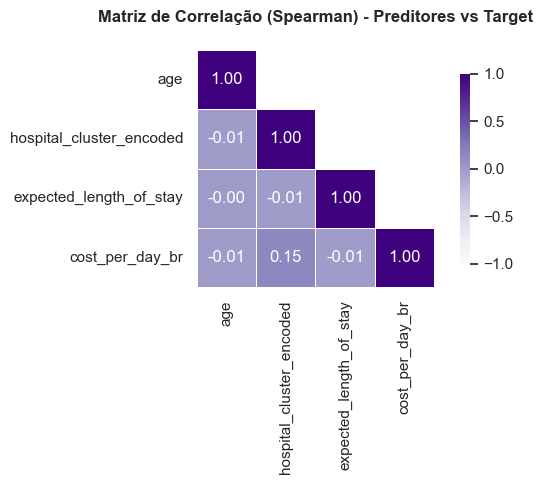

In [28]:
# === Pipeline 2: Diagnóstico Estatístico (Matriz de Correlação) ===

# Nota Técnica: A proposta desta pipeline é apresentar a matriz de correlação de Spearman
# para auditar visualmente a força das relações não lineares monotônicas e monitorar a 
# colinearidade entre os preditores numéricos e o target (cost_per_day_br) antes da modelagem final.


def pipeline_2_diagnostico_correlacao(X_train, y_train):
    """Pipeline 2: Calcula e plota a matriz de Spearman para auditoria

    e transparência das features com o target de custo.
    """
    print("\n" + "=" * 85)
    print(" ▶ PIPELINE 2: GERANDO DIAGNÓSTICO VISUAL DE CORRELAÇÃO (SPEARMAN)")
    print("=" * 85)

    # --- 1. Preparando o DataFrame para a análise do treino
    df_corr = X_train.copy()
    df_corr["cost_per_day_br"] = y_train

    # --- 2. Mapeamento para conversão visual e ordinal do cluster hospitalar
    # Nota: Transformamos em escala ordinal (1 a 3) para viabilizar o cálculo estatístico de correlação
    cluster_map = {
        "hospital_baixo_custo": 1,
        "hospital_custo_padrao": 2,
        "hospital_alto_custo": 3,
    }
    df_corr["hospital_cluster_encoded"] = (
        df_corr["hospital_cluster"].astype(str).map(cluster_map)
    )

    # Tratamento caso haja alguma string fora do padrão mapeado
    if df_corr["hospital_cluster_encoded"].isnull().any():
        print("⚠️ Fallback ativado: aplicando fatorização padrão na coluna 'hospital_cluster'.")
        df_corr["hospital_cluster_encoded"] = (
            df_corr["hospital_cluster"].astype("category").cat.codes + 1
        )

    # Isolando apenas os preditores contínuos/ordinais e o target para o Heatmap
    features_analise = [
        "age",
        "hospital_cluster_encoded",
        "expected_length_of_stay",
        "cost_per_day_br",
    ]

    # --- 3. Cálculo da correlação (Preenchendo constantes/nulos com 0 para estabilidade do plot)
    matriz_correlacao = (
        df_corr[features_analise].corr(method="spearman").fillna(0)
    )

    # --- 4. Construção do Gráfico
    plt.figure(figsize=(7, 5))
    sns.set_theme(style="white", font_scale=1.0)

    # Máscara mantendo os blocos inferiores (ocultando a redundância espelhada do topo)
    mask = np.triu(np.ones_like(matriz_correlacao, dtype=bool), k=1)

    sns.heatmap(
        matriz_correlacao,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )

    plt.title(
        "Matriz de Correlação (Spearman) - Preditores vs Target",
        fontsize=12,
        weight="bold",
        pad=20,
    )
    plt.tight_layout()
    plt.savefig('plots/12_plot_heatmap_corr_spearman.png', dpi=300, bbox_inches='tight')
    plt.show()


# --- CHAMADA DA PIPELINE 2 ---
print("✅ Pipeline 2 Concluída")
pipeline_2_diagnostico_correlacao(X_train_p1, y_train)

**`Pipeline 2: Análise Matriz de Correção de Spearman (Preditores vs Target)`**

* Com a matriz de design estruturada e protegida contra vazamento de dados, executamos a análise de correlação de **Spearman** para avaliar a força e a direção das relações não lineares monotônicas entre os preditores numéricos/ordinais e a variável alvo (`cost_per_day_br`).

**Nota Técnica:**
* A análise de Spearman revelou coeficientes extremamente próximos a zero para quase todas as variáveis numéricas isoladas em relação ao target: *`age` (-0,01) e `expected_length_of_stay` (-0,01)*. Estatisticamente, isso aceita a hipótese de que não existem relações lineares ou tendências monotônicas simples (do tipo "quanto maior a idade, maior o custo diário") controlando o comportamento do custo.
* A feature engenhada *`hospital_cluster_encoded`* apresentou o único coeficiente positivo sutil da matriz, registrando **0,15**. Embora seja uma correlação fraca, ela indica que a clusterização por quartis de faturamento conseguiu reter o maior fragmento de variância linear disponível no dataset.
* Coeficientes zerados na matriz de correlação univariada indicam que modelos lineares tradicionais (como Regressão Linear padrão e LinearSVR) terão imensa dificuldade de convergência e apresentarão um $R^2$ muito baixo. Esse cenário justifica e isola a necessidade de testarmos **modelos baseados em árvores (XGBoost, LightGBM, CatBoost) e Redes Neurais (MLP)**, que são arquiteturas projetadas especificamente para caçar interações cruzadas complexas e não lineares que coeficientes de correlação isolados não conseguem capturar.

**Insight de Negócio:**
* Para a gestão estratégica da operadora, a matriz zerada quebra velhos paradigmas do setor de saúde suplementar real. Ela prova que, nesta carteira específica, o risco financeiro diário **não pode ser previsto olhando para fatores isolados**, como a idade avançada do beneficiário ou o tempo esperado de internação de forma independente. 
* Um cenário onde as correlações isoladas beiram o zero significa que o risco está diluído de forma homogênea e combinatória. Tentar aplicar regras de auditoria médica simples e manuais (ex: "auditar todos os pacientes idosos" ou "auditar apenas internações longas") resultará em alto desperdício de energia operacional e ineficiência financeira, pois esses fatores isolados operam como ruído. O controle de sinistralidade exigirá, obrigatoriamente, o uso dos nossos algoritmos de IA para identificar padrões invisíveis a análises tradicionais.

**Ação (Próximo Passo):**
* Com os diagnósticos univariados e de correlação documentados, encerramos a fase de engenharia e análise de features. Avançaremos para a etapa de **Treinamento dos Algoritmos**.

### 2.3 Resumo Executivo: Etapa 2 - Análise das Features para Modelagem

**1. ESCOPO DAS FEATURES SELECIONADAS (Sinal Preditivo)**

| Categoria | Feature | Papel no Modelo | Justificativa Estatística & de Negócio |
| :--- | :--- | :--- | :--- |
| **Estrutural** | `hospital_cluster` | Preditor Principal | ▶ Substitui a rede credenciada dispersa por 3 faixas ordinais de custo via quartis.<br> ▶ Apresentou o único sinal preditivo monotônico residual da matriz de Spearman ($0.15$), provando que acordos comerciais com prestadores ditam o custo diário mais do que o perfil isolado de entrada. |
| **Demográfica** | `age` | Preditor Contínuo | ▶ Mantida de forma granular (escala anual) para permitir que os modelos de boosting e redes neurais capturem de forma livre e não linear possíveis interações de risco ao longo do ciclo de vida do beneficiário. |
| **Clínica** | `expected_length_of_stay` | Proxy Histórico | ▶ Mediana do tempo de permanência calculada *estritamente* na base de treino, agrupada por protocolo clínico.<br> ▶ Garante o elo de severidade médica na admissão do paciente, convertendo a complexidade clínica em um sinal contínuo sem gerar vazamento de dados. |

<br>

**2. JUSTIFICATIVA DE EXCLUSÕES CRÍTICAS (Filtros de Governança)**

| Feature Original | Status Final | Motivo Técnico do Descarte | Destinação Estratégica / Solução de Negócio |
| :--- | :--- | :--- | :--- |
| `billing_amount` <br> `billing_amount_br` <br> `discharge_date` <br> `length_of_stay` <br> `is_catastrophic_case` | **Descartadas** | **Vazamento de Dados (*Data Leakage*):** são informações financeiras e operacionais geradas após a alta hospitalar. Usá-las inviabilizaria a aplicação do modelo no momento zero da internação. |  Preservadas exclusivamente no ecossistema de Business Intelligence (BI) para auditoria retroativa de contas. |
| `age_group` | **Descontinuada** <br> *(Uso em BI)* |   **Multicolinearidade:** adicionar as faixas etárias fixas geraria redundância perfeita com a idade contínua (`age`), podando a flexibilidade dos algoritmos. | Retida para aplicação exclusiva de regras de precificação e análise atuarial regulatória da **ANS**. |
| `expected_is_long_stay` | **Descartada** | **Variância Zero / Redundância:** o isolamento estrito da base de treino converteu a flag em uma coluna constante (ruído matemático com correlação e variância nulas). | Eliminada do pipeline para proteger a convergência e estabilidade das regressões. |
| `medical_condition` <br> `medication` <br> `test_results` | **Descartadas** | **Ausência de Variabilidade univariada:** testes de ANOVA comprovaram distribuições de custos planas e médias equivalentes entre as patologias e fármacos isolados. | Descartadas isoladamente por não oferecerem ganho de informação para a arquitetura preditiva. |
| `condition_medication` | **Absorvida** <br> *(Sinal Extraído)* | **Redução de Dimensionalidade:** a string combinada nominal geraria alta esparsidade via One-Hot Encoding. Seu sinal foi extraído e convertido na feature numérica contínua `expected_length_of_stay`. | **Uso estratégico em Auditoria Concorrente** para gerar alertas de contas e identificar desvios contratuais de pacotes fixos. |
| `doctor` | **Descartada** | **Alta Cardinalidade Esparsa:** variável nominal altamente pulverizada na base de dados, onde cada profissional possuía representatividade amostral infinitesimal. | Inviável para generalização estatística; induziria os modelos (KNN e MLP) ao *overfitting*. |
| `gender` <br> `blood_type` <br> `insurance_provider` <br> `admission_type` | **Descartadas** | **Ruído Estatístico Uniforme:** coeficientes de correlação de Spearman zerados e distribuições perfeitamente homogêneas herdadas da simulação do dataset. | Descartadas em conformidade com o princípio da parcimônia para evitar o vício dos estimadores. |

<br>

> **Certificação de Robustez:** <br>
> O pipeline foi reduzido para **3 features preditivas** ['age', 'hospital_cluster', 'expected_length_of_stay'], garantindo conformidade atuarial, eliminação completa de *Data Leakage*, estabilidade matemática e alta velocidade de processamento para deploy em produção.

## **Etapa 3: Treinamento dos Algoritmos**

In [29]:
# importar as bibliotecas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import shap

#### 3.1 Pipeline para Engenharia de Transformação e Avaliação das Métricas

In [30]:
# =========================================================================
# PIPELINE 3: ENGENHARIA DE TRANSFORMAÇÃO (ENCODING E SCALING)
# =========================================================================

def pipeline_3_transformacao_dados(X_train_p1, X_test_p1):
    """Pipeline 3: Aplica One-Hot Encoding nas categóricas e StandardScaler

    nas numéricas contínuas, retornando matrizes prontas para a modelagem.
    """
    print("\n" + "=" * 85)
    print("▶ PIPELINE 3: CONFIGURANDO PROCESSAMENTO DE ENCODING E SCALING CONCORRENTE")
    print("=" * 85)

    # --- 1. Definição explícita dos blocos de features finais selecionadas
    features_numéricas = ["age", "expected_length_of_stay"]
    features_categóricas = ["hospital_cluster"]

    # --- 2. Construção do ColumnTransformer estruturado
    # drop='first' blinda os modelos lineares contra a armadilha da multicolinearidade das dummies
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), features_numéricas),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", drop="first"),
                features_categóricas,
            ),
        ]
    )

    print("* Ajustando o pipeline de pré-processamento estritamente na base de treino...")
    # O fit_transform é feito APENAS no treino
    X_train_enc = preprocessor.fit_transform(X_train_p1)

    print("* Aplicando as transformações salvas na base de teste (Anti-Leakage)...")
    # O teste apenas sofre o transform, herdando os parâmetros do treino
    X_test_enc = preprocessor.transform(X_test_p1)

    # Se a saída for uma matriz esparsa (comum no OneHotEncoder), converte para array denso para evitar quebras no MLP/KNN
    if hasattr(X_train_enc, "toarray"):
        X_train_enc = X_train_enc.toarray()
        X_test_enc = X_test_enc.toarray()
    
    print('-'* 85)
    print("✅ Pipeline 3 Concluída")
    print(f"   * Matriz de Treino Final: {X_train_enc.shape}")
    print(f"   * Matriz de Teste Final: {X_test_enc.shape}")

    return X_train_enc, X_test_enc


# --- EXECUÇÃO DA PIPELINE 3 (Gera os dados para o Modelo 01) ---
X_train_enc, X_test_enc = pipeline_3_transformacao_dados(X_train_p1, X_test_p1)


▶ PIPELINE 3: CONFIGURANDO PROCESSAMENTO DE ENCODING E SCALING CONCORRENTE
* Ajustando o pipeline de pré-processamento estritamente na base de treino...
* Aplicando as transformações salvas na base de teste (Anti-Leakage)...
-------------------------------------------------------------------------------------
✅ Pipeline 3 Concluída
   * Matriz de Treino Final: (38402, 4)
   * Matriz de Teste Final: (16458, 4)


**`Pipeline 3: Engenharia de Transformação Concorrente (Encoding e Scaling)`**

* Módulo responsável pela padronização matemática final dos dados antes de injetá-los na arena de machine learning.

**Nota Técnica:**
* Processamento via `ColumnTransformer`:** aplica transformações concorrentes e independentes com base na natureza de cada recurso, otimizando o tempo de processamento em memória.
* Padronização (`StandardScaler`):** centraliza a média em zero e escala a variância para a unidade nas features numéricas (`age` e `expected_length_of_stay`). Essencial para garantir a convergência rápida de Redes Neurais (MLP), Regressões Lineares e algoritmos baseados em distância (KNN).
* Codificação (`OneHotEncoder`):** transforma o indicador categórico `hospital_cluster` em variáveis binárias (*dummies*), utilizando o parâmetro `drop='first'` para blindar as regressões de multicolinearidade.
* **Densidade de Matriz:** converte automaticamente saídas esparsas em arrays densos (`toarray()`), garantindo compatibilidade universal com todos os pacotes de modelagem escolhidos.

**Ação (Próximo Passo):**
* Criar função que execute o cálculos das métricas estabelecidas no planejamento do projeto e plot de gráficos para análise visual dos resultados dos modelos de regressão.

In [31]:
# =======================================================================================
# FUNÇÃO: CÁLCULO DAS MÉTRICAS E ARMAZENAMENTO EM DICIONÁRIO GLOBAL PARA RESUMO EXECUTIVO
# =======================================================================================

# Nota Técnica: função estruturada para armazenar em dicionário global os
# resultados dos algoritmos, a fim de gerar uma tabela comparativa final
# dos modelos treinados.
# Nota Técnica: função plota gráficos de aderência ao lado do gráfico de resíduos
# para diagnóstico e análise detalhada dos resultados dos modelos de regressão.

# Armazenamento das métricas em dicionário global para os stakeholders
resumo_executivo_modelos = {}


def avaliar_e_registrar_modelo(nome_modelo, y_real, y_predito):
    """Calcula MAE, RMSE e R2, exibe no terminal, alimenta o dicionário

    global e plota os gráficos de Aderência e Resíduos para o Fine-Tuning.
    """
    # --- 1. Cálculo das Métricas Estatísticas
    mae = mean_absolute_error(y_real, y_predito)
    rmse = np.sqrt(mean_squared_error(y_real, y_predito))
    r2 = r2_score(y_real, y_predito)

    # --- 2. Cálculo dos resíduos (erros) para o plot
    residuos = y_real - y_predito

    # --- 3. Armazenamento no dicionário global
    resumo_executivo_modelos[nome_modelo] = {
        "MAE (R$)": round(mae, 2),
        "RMSE (R$)": round(rmse, 2),
        "R² Score": round(r2, 4),
    }

    # --- 4. Log de confirmação no terminal
    print("\n" + "-" * 60)
    print(f"📈 DIAGNÓSTICO DE PERFORMANCE: {nome_modelo.upper()}")
    print("-" * 60)
    print(f"   ▶ MAE (Erro Médio Absoluto): R$ {mae:,.2f}")
    print(f"   ▶ RMSE (Raiz do Erro Quadrático): R$ {rmse:,.2f}")
    print(f"   ▶ R² (Coeficiente de Determinação): {r2:.4f}")
    print("-" * 60)

    # --- 5. Visualização dos Gráficos de Regressão
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- PLOT 1: REAIS VS PREDITOS (Visualização do R²) ---
    # Encontra os limites máximos e mínimos para desenhar a linha ideal de 45 graus
    limite_min = min(y_real.min(), y_predito.min())
    limite_max = max(y_real.max(), y_predito.max())

    sns.scatterplot(
        x=y_real, y=y_predito, ax=axes[0], alpha=0.4, color="#6a0dad"
        )
    axes[0].plot(
        [limite_min, limite_max],
        [limite_min, limite_max],
        "r--",
        lw=2,
        label="Previsão Perfeita ($y=x$)",
    )
    axes[0].set_title(
        f"Aderência do Modelo - Reais vs Preditos\n(R² = {r2:.4f})",
        fontsize=11,
        weight="bold",
    )
    axes[0].set_xlabel("Custo Real por Diária (R$)")
    axes[0].set_ylabel("Custo Predito por Diária (R$)")
    axes[0].legend()

    # --- PLOT 2: ANÁLISE DE RESÍDUOS (Visualização do MAE / RMSE) ---
    sns.scatterplot(
        x=y_predito, y=residuos, ax=axes[1], alpha=0.4, color="#e65c00"
        )
    axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
    axes[1].set_title(
        f"Análise de Resíduos (Erros)\n(MAE = R$ {mae:.2f} | RMSE = R$ {rmse:.2f})",
        fontsize=11,
        weight="bold",
    )
    axes[1].set_xlabel("Custo Predito por Diária (R$)")
    axes[1].set_ylabel("Resíduo / Erro (Real - Predito)")

    plt.suptitle(
        f"Gráficos de Diagnóstico - {nome_modelo.replace('_', ' ')}",
        fontsize=14,
        weight="bold",
        y=1.05,
    )
    plt.tight_layout()

    # Salva o gráfico individual de fine-tuning para documentação
    nome_arquivo = f"plots/diagnostico_{nome_modelo.lower()}.png"
    plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")
    plt.show()

print("✅ Função para Cálculo e Armazenamento das Métricas Concluída")

✅ Função para Cálculo e Armazenamento das Métricas Concluída


**`Função Centralizada de Métricas e Diagnóstico de Fine-Tuning: 'avaliar_e_registrar_modelo'`**

* Rotina automatizada aplicada individualmente a cada um dos 8 modelos para extração de performance e logs de auditoria.

**Nota Técnica:**
* **Métricas Financeiras e Atuariais:** calcula simultaneamente o **MAE** (Erro Médio Absoluto) para expressar o erro médio direto em Reais, o **RMSE** (Raiz do Erro Quadrático Médio) para penalizar severamente grandes desvios e monitorar o risco de cauda (*tail risk*), e o **$R^2$ Score** para mensurar a proporção de variância explicada.
* **Gráficos Concorrentes de Resíduos:** plota em paralelo o gráfico de Aderência (Reais vs. Preditos) para verificar desvios da linha ideal $y=x$, e o gráfico de Resíduos (Preditos vs. Erros) com opacidade controlada (`alpha=0.4`) para diagnosticar visualmente padrões de heterocedasticidade.

**Insight de Negócio:**
* O armazenamento automatizado das métricas no dicionário global `resumo_executivo_modelos` padroniza a linguagem técnica. Isso permite converter a performance estatística pura em impacto financeiro direto por diária, facilitando a tomada de decisão da liderança na escolha do modelo mais equilibrado para entrar em produção.

**Ação (Próximo Passo):**
* Iniciar os treinamentos dos modelos!

#### 3.2 Treinamento e Avaliação dos Modelos de Regressão

▶ Inicializando e treinando o Modelo 01: Linear Regression...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 01_LINEAR_REGRESSION
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,369.85
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,204.04
   ▶ R² (Coeficiente de Determinação): 0.0317
------------------------------------------------------------


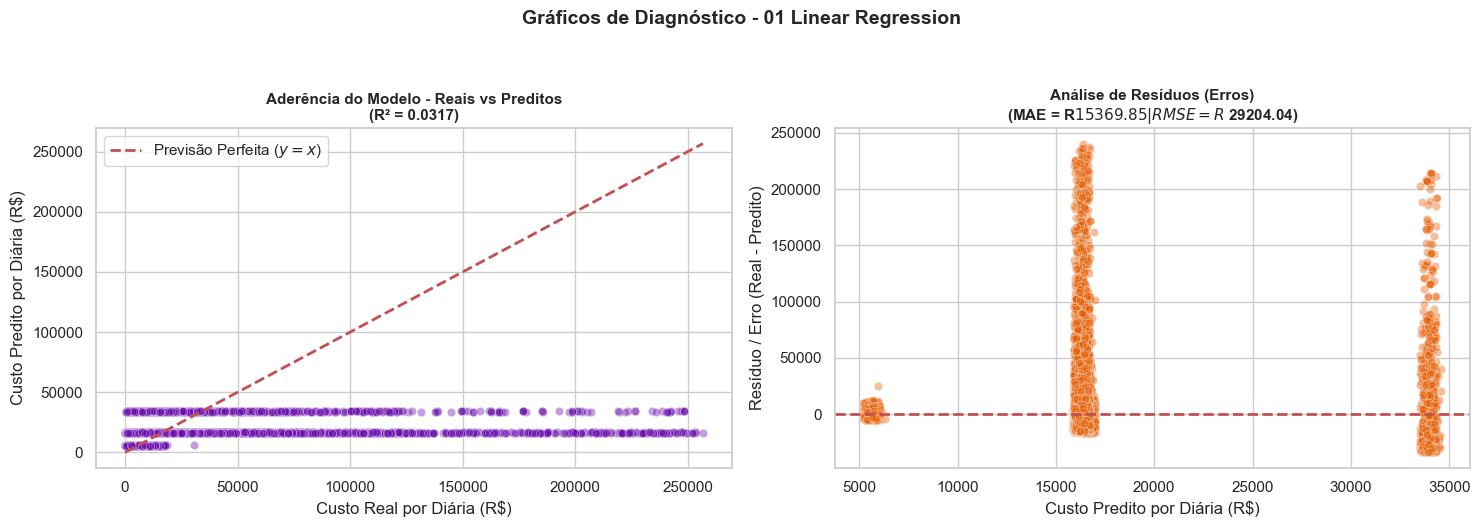

In [32]:
# =========================================================================
# MODELO 01: LINEAR REGRESSION (BASELINE ESTATÍSTICO)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 01: Linear Regression...")

# --- 1. Instanciação do Modelo
# Parâmetros padrão usados para o baseline puro
modelo_01 = LinearRegression()

# --- 2. Treinamento do Algoritmo
# Modelos lineares exigem a base com ENCODING e SCALING (_enc)
modelo_01.fit(X_train_enc, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste (dados não vistos)
preds_01 = modelo_01.predict(X_test_enc)

# --- 4. Avaliação, Plots e Registro no Resumo Executivo
avaliar_e_registrar_modelo("01_Linear_Regression", y_test, preds_01)

**`Análise de Performance - Modelo 01: Linear Regression (Baseline)`**

* O modelo baseline linear apresentou o comportamento insatisfatório previsto durante a fase exploratória, servindo como uma excelente validação empírica da complexidade não linear do dataset.

**Nota Técnica:**
* O modelo foi capaz de explicar apenas **3,17%** da variabilidade do custo diário (`cost_per_day_br`). Como as correlações univariadas de idade e expectativa de permanência são nulas, o algoritmo colapsou seus coeficientes ($w_i$) para essas variáveis.
* Os gráficos de diagnóstico revelam que a Regressão Linear atuou como um classificador primitivo. O modelo gerou três faixas verticais rígidas de predição baseadas estritamente no `hospital_cluster` de entrada: ele converge seus "chutes" para os centros de massa da rede de baixo custo (~R$ 5.500), custo padrão (~R$ 16.500) e alto custo (~R$ 34.000).
* O teto preditivo máximo do modelo estancou em R$ 35.000. Consequentemente, o algoritmo é incapaz de prever sinistros catastróficos (outliers assistenciais que atingem o teto de R$ 261 mil). O forte descolamento entre o **MAE (R$ 15.369,85)** e o **RMSE (R$ 29.204,04)** confirma matematicamente que o modelo foi severamente penalizado por erros massivos na cauda longa do faturamento.

**Insight de Negócio:**
* O modelo deixaria passar os maiores drenos financeiros da carteira, gerando severa ineficiência orçamentária e pontos cegos na gestão atuarial.

**Ação (Próximo Passo):**
* Avançar para o *Modelo 02: K-Neighbors Regressor (KNN)*: por computar proximidade em espaço vetorial multidimensional, avaliaremos se o KNN consegue quebrar o engessamento dessas três faixas lineares e aproximar os resíduos da linha ideal de predição.

▶ Inicializando e treinando o Modelo 02: KNN Regressor...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 02_KNN_REGRESSOR
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 16,582.57
   ▶ RMSE (Raiz do Erro Quadrático): R$ 31,612.02
   ▶ R² (Coeficiente de Determinação): -0.1345
------------------------------------------------------------


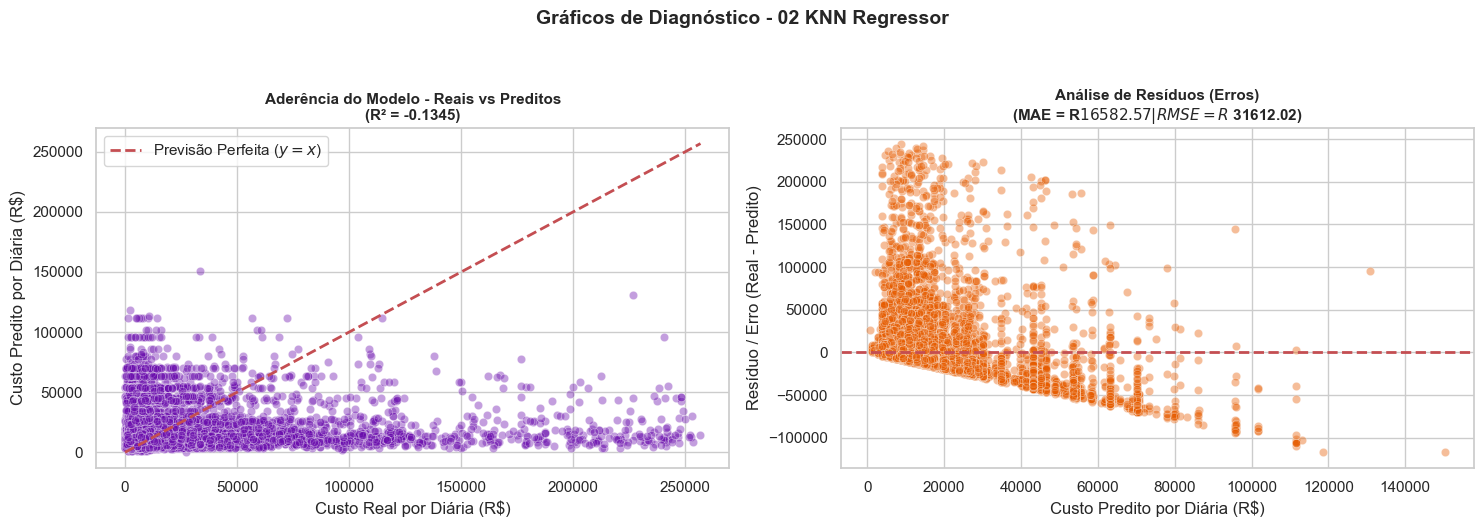

In [33]:
# =========================================================================
# MODELO 02: K-NEIGHBORS REGRESSOR (KNN)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 02: KNN Regressor...")

# --- 1. Instanciação do Modelo
# Modelagem padrão: 5 vizinhos e pesos baseados na distância.
# O parâmetro weights='distance' faz com que vizinhos mais próximos tenham mais relevância,
# o que costuma ajudar a capturar os picos de custo que a regressão linear perdeu.

modelo_02 = KNeighborsRegressor(n_neighbors=5, weights="distance", n_jobs=-1)

# --- 2. Treinamento do Algoritmo
# O KNN é baseado em distância, portanto exige a base SCALED (_enc)
modelo_02.fit(X_train_enc, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste (dados não vistos)
preds_02 = modelo_02.predict(X_test_enc)

# --- 4. Avaliação, Plots e Registro no Resumo Executivo
avaliar_e_registrar_modelo("02_KNN_Regressor", y_test, preds_02)

**`Análise de Performance - Modelo 02: K-Neighbors Regressor (KNN)`**

* O algoritmo baseado em instâncias e distância vetorial trouxe um diagnóstico interessante sobre o comportamento das features, embora sua performance global tenha colapsado metricamente.

**Nota Técnica:**
* O KNN apresentou uma performance **inferior ao baseline linear**. Um coeficiente de determinação negativo prova matematicamente que o modelo é pior do que um estimador que "chuta" apenas a média do custo diário para todos os casos.
* O ponto positivo do algoritmo foi a sua capacidade de quebrar o engessamento das três faixas horizontais da Regressão Linear, estendendo o teto de predição até a faixa de R$ 140.000. Contudo, essa flexibilidade resultou nas métricas maiores de **MAE (R$ 16.582,57)** e **RMSE (R$ 31.612,02)**, confirmando que o modelo gerou previsões dispersas com erros de grande magnitude.
* A linha diagonal decrescente e sólida no quadrante inferior do gráfico de resíduos denuncia que o KNN sofreu com a homogeneidade demográfica e clínica do dataset sintético. Como vizinhos de patologias diferentes compartilham distâncias quase idênticas no espaço vetorial, o modelo atribuiu repetidamente projeções de alto custo a sinistros de rotina (gerando resíduos fortemente negativos).
* Diante do colapso métrico do KNN e da ausência de agrupamento espacial nítido nas 3 features, o *fine-tuning deste modelo é descontinuado por ineficiência estrutural*. 

**Insight de Negócio:**
* O KNN falha como ferramenta de suporte à gestão de saúde suplementar ao inflar artificialmente as previsões de custo de pacientes comuns (chutando valores próximos a R$ 100 mil para quem geraria custos baixos), o modelo geraria uma avalanche de **alarmes falsos**. Isso sobrecarregaria as equipes de auditoria concorrente com revisões desnecessárias, desperdiçando o Capex operacional da operadora.

**Ação (Próximo Passo):**
* Avançar para o **Modelo 03: Linear Support Vector Regressor (LinearSVR)**, com o objetivo de avaliar se a otimização baseada em margens máximas e na minimização de erros dentro de um tubo de tolerância ($\epsilon$-intensive) consegue estabilizar os resíduos e superar o baseline estatístico.

▶ Inicializando e treinando o Modelo 03: LinearSVR...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 03_LINEAR_SVR
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 12,940.04
   ▶ RMSE (Raiz do Erro Quadrático): R$ 31,329.12
   ▶ R² (Coeficiente de Determinação): -0.1143
------------------------------------------------------------


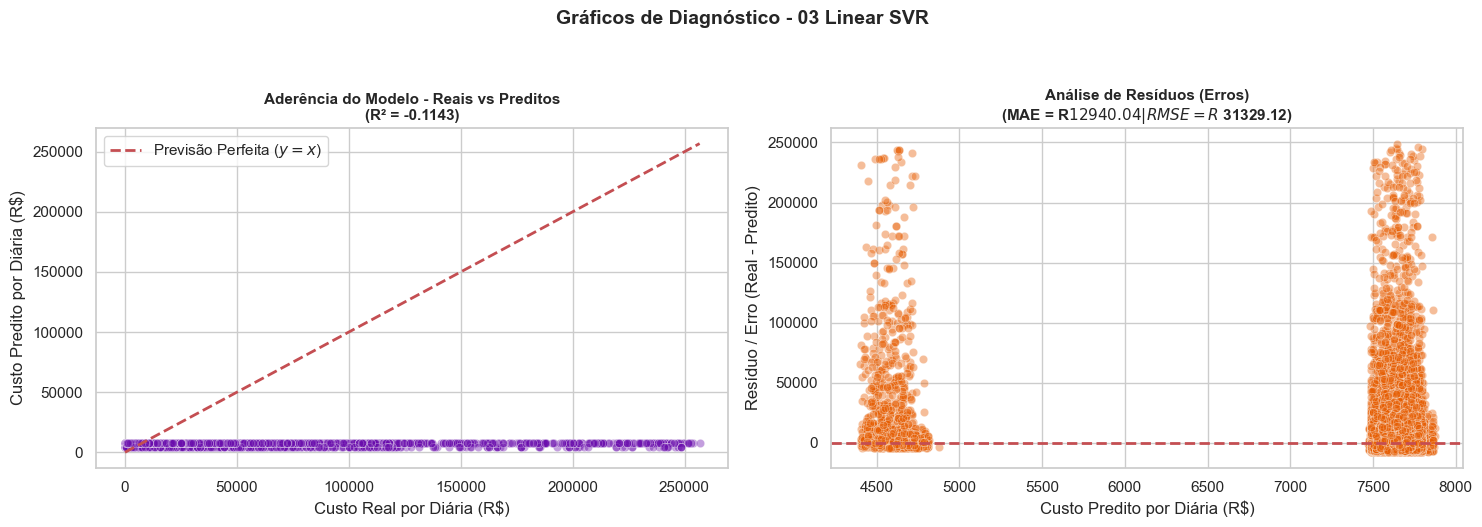

In [34]:
# =========================================================================
# MODELO 03: LINEAR SUPPORT VECTOR REGRESSOR (LinearSVR)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 03: LinearSVR...")

# --- 1. Instanciação do Modelo
# O parâmetro C controla a penalização dos erros fora da margem (regularização).
# O parâmetro epsilon define a largura do tubo onde o erro é ignorado.
modelo_03 = LinearSVR(C=1.0, epsilon=0.1, random_state=42, max_iter=5000)

# --- 2. Treinamento do Algoritmo (exige base com SCALING e OHE)
modelo_03.fit(X_train_enc, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_03 = modelo_03.predict(X_test_enc)

# --- 4. Avaliação, Plots e Registro no Resumo Executivo
avaliar_e_registrar_modelo("03_Linear_SVR", y_test, preds_03)

**`Análise de Performance - Modelo 03: Linear Support Vector Regressor (LinearSVR)`**

* O modelo baseado em Margens Máximas (SVR) falhou severamente em se adaptar à distribuição do dataset, gerando o pior cenário preditivo e de gerenciamento de risco até o momento.

**Nota Técnica:**
* O coeficiente de determinação negativo **($R^2 = -0,1143$)** confirma que o modelo performa pior do que a média global. O gráfico de aderência revela um achatamento extremo: o algoritmo "esmagou" quase todas as previsões contra o piso do gráfico, sendo incapaz de projetar qualquer valor acima de R$ 8.000.
* Ao contrário da Regressão Linear, que ainda tentou segmentar os 3 clusters hospitalares, o LinearSVR colapsou suas fronteiras. O gráfico de resíduos mostra que ele dividiu suas projeções em apenas dois blocos ultra-estáticos: um em ~R$ 4.500 e outro em ~R$ 7.500 **(Comportamento Bi-Clusterizado Rígido)**. O modelo simplesmente "desistiu" de mapear o cluster de alto custo para evitar a penalização de margem.
* Embora o **MAE tenha caído para R$ 12.940,04** (gerado artificialmente pelo fato de chutar valores baixos em uma base onde a mediana também é baixa), o **RMSE saltou para R$ 31.329,12**. Essa distância enorme prova matematicamente que o modelo foi severamente punido pelos erros quadráticos ao ignorar por completo a cauda longa de sinistros.
* O LinearSVR está **sumariamente descartado** do projeto, e qualquer tentativa de *fine-tuning* é inviável por limitações estruturais do algoritmo perante a assimetria do target.

**Insight de Negócio:**
* Para a diretoria financeira da operadora, o LinearSVR é o modelo mais perigoso avaliado. Ao estancar o teto de gastos em R$ 8.000, ele cria uma falsa ilusão de que a carteira é barata e controlada. Na prática, a operadora sofreria um colapso de liquidez (subprovisão de caixa), pois o modelo seria incapaz de identificar diárias de médio custo e falharia em 100% das vezes na detecção de sinistros catastróficos.

**Ação (Próximo Passo):**
* Avançar para o **Modelo 04: Multilayer Perceptron (MLP Neural Network)**, iniciando a era não linear para avaliar se as camadas densas e as funções de ativação escondidas conseguem quebrar o achatamento dos dados.

▶ Inicializando e treinando o Modelo 04: MLP Neural Network...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 04_MLP_NEURAL_NETWORK
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,405.34
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,264.65
   ▶ R² (Coeficiente de Determinação): 0.0277
------------------------------------------------------------


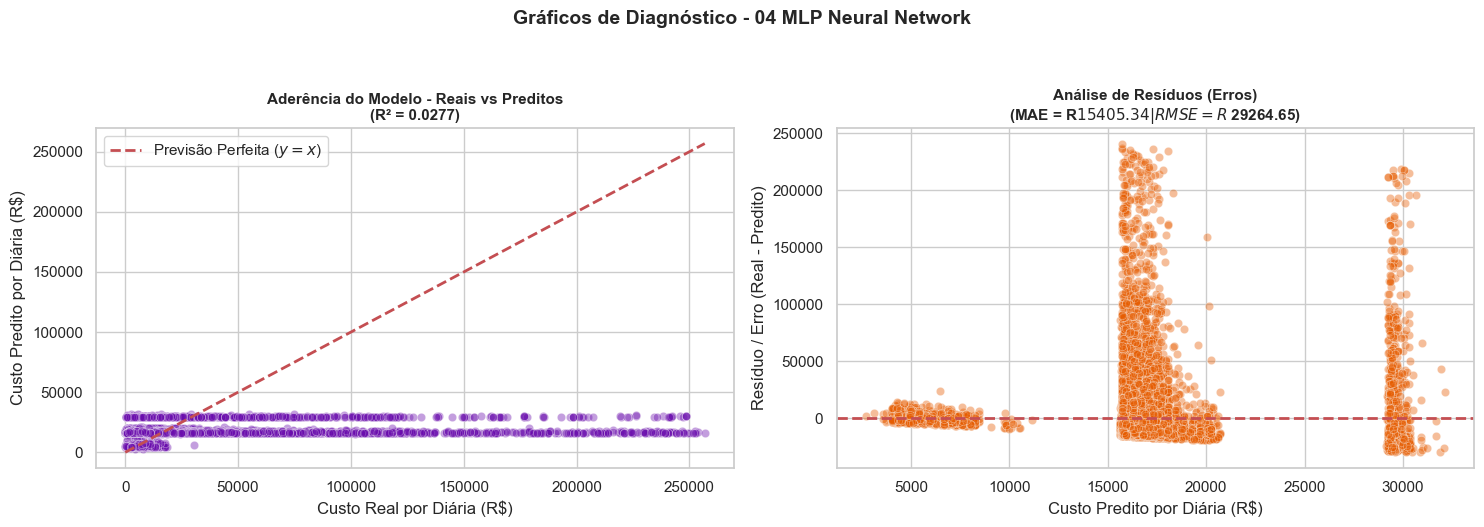

In [35]:
# =========================================================================
# MODELO 04: MULTILAYER PERCEPTRON (MLP NEURAL NETWORK)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 04: MLP Neural Network...")

# --- 1. Instanciação do Modelo
# Criação de uma rede com duas camadas ocultas (100 neurônios na primeira, 50 na segunda).
# Uso do otimizador 'adam' , que é excelente para convergência estável.
# Ativação do early_stopping para evitar overfitting se a rede começar a decorar o treino.
modelo_04 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size="auto",
    learning_rate="adaptive",
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

# --- 2. Treinamento (Exige base com SCALING e OHE)
modelo_04.fit(X_train_enc, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_04 = modelo_04.predict(X_test_enc)

# --- 4. Avaliação, Plots e Registro no Resumo Executivo
avaliar_e_registrar_modelo("04_MLP_Neural_Network", y_test, preds_04)

**`Análise de Performance - Modelo 04: Multilayer Perceptron (MLP Neural Network)`**

* A abordagem por Deep Learning falhou em capturar padrões complexos não lineares no espaço vetorial atual, convergindo para uma solução estatisticamente equivalente ao baseline linear.

**Nota Técnica:**
* ** O modelo explicou apenas **2,77%** da variabilidade do custo diário, performando ligeiramente abaixo da Regressão Linear padrão. Devido à fraqueza e à uniformidade dos sinais das features de entrada, os pesos ($W$) da rede neural convergiram para aproximar a média aritmética de cada cluster hospitalar.
* O gráfico de aderência exibe um achatamento das previsões, com o teto estancado em R$ 33.000. Embora o gráfico de resíduos mostre que a MLP tentou gerar uma sutil flexibilização "esfumaçada" nas bases de predição (diferente da rigidez matemática perfeita da Regressão Linear), as funções de ativação ReLU não encontraram gradiente para aprender o risco de cauda longa.
* O abismo entre o **MAE (R$ 15.405,34)** e o **RMSE (R$ 29.264,65)** manteve-se intacto. A rede neural preferiu jogar a esmagadora maioria de seus "chutes" na zona de conforto do custo padrão (~R$ 17.500), sendo completamente incapaz de prever sinistros na casa das centenas de milhares de reais.
* Colocar uma estrutura de Deep Learning em produção que exige alto custo computacional, GPU para treinamento e infraestrutura dedicada para entregar o mesmo resultado de uma equação linear simples seria um erro estratégico. O modelo MLP está **descartado** e não receberá rodadas de hiperparametrização.

**Ação (Próximo Passo):**
* Encerram-se os testes com modelos dependentes de escalonamento e sensíveis à escala global (`Linear`, `KNN`, `SVR`, `MLP`).
* Avançar para o **Modelo 05: Random Forest Regressor**, iniciando a era dos **Ensembles baseados em Árvores (Bagging)**, o objetivo é avaliar se partições recursivas do espaço amostral conseguem isolar os outliers e capturar os degraus de custo de forma eficiente.

▶ Inicializando e treinando o Modelo 05: Random Forest Regressor...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 05_RANDOM_FOREST
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,403.76
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,265.70
   ▶ R² (Coeficiente de Determinação): 0.0276
------------------------------------------------------------


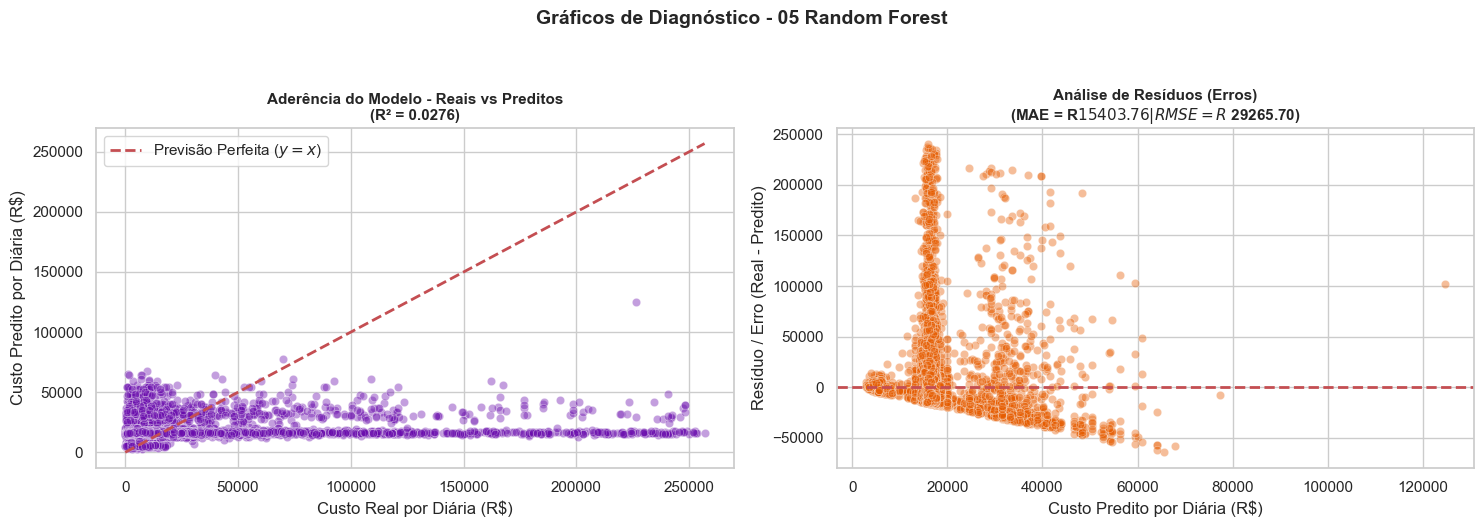

In [36]:
# =========================================================================
# MODELO 05: RANDOM FOREST REGRESSOR (MUDANÇA DE PARADIGMA - ÁRVORES)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 05: Random Forest Regressor...")

# --- 1. Instanciação do Modelo
# Uso de n_estimators=200 (200 árvores independentes votando juntas).
# max_depth=10 serve para dar capacidade de profundidade para cruzar idade e proxies,
# sem deixar a árvore decorar o treino (overfitting).
modelo_05 = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1
)

# --- 2. Treinamento do Algoritmo (Pode usar a base _enc)
modelo_05.fit(X_train_enc, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_05 = modelo_05.predict(X_test_enc)

# --- 4. Avaliação, Plots e Registro Automatizado
avaliar_e_registrar_modelo("05_Random_Forest", y_test, preds_05)

**`Análise de Performance - Modelo 05: Random Forest Regressor (Ensemble)`**

* A transição para algoritmos baseados em árvores e partições recursivas do espaço amostral trouxe a melhor distribuição visual de predições até o momento, mas esbarrou em uma limitação matemática intrínseca dos modelos de média de florestas.

**Nota Técnica:**
* O coeficiente de determinação permaneceu estagnado em **2,76%**, alinhado ao comportamento da MLP e da Regressão Linear. Como o mecanismo de regressão da Random Forest calcula a média aritmética das folhas de suas 200 árvores, e 90% do dataset está concentrado no custo padrão, o modelo sofre uma forte atração para a massa de dados barata, impedindo que as projeções atinjam o teto real de R$ 261 mil.
* O gráfico de aderência mostra uma evolução aparente em relação aos modelos anteriores. O algoritmo rompeu as barreiras horizontais rígidas e pulverizou as previsões, estendendo o teto de estimativa para a faixa de R$ 120.000 em casos selecionados. O **MAE fixou-se em R$ 15.403,76** e o **RMSE em R$ 29.265,70**, empatando com o baseline estatístico.
* O gráfico de resíduos exibe uma distribuição concentrada no valor de diária média (~17k), mas segue em ascendência na vertical. Isso demonstra que o modelo conseguiu identificar o peso do cluster hospitalar e da expectativa de dias, mas subestimou a cauda longa de sinistros, jogando previsões de R$ 40k a R$ 60k para pacientes que custaram mais de R$ 150k. Qualquer tentativa de *fine-tuning* tradicional (ajustando `max_depth` ou `min_samples_leaf`) é inútil, pois a arquitetura de *Bagging* não foi desenhada para compensar o desbalanceamento *brutal* do alvo.

**Insight de Negócio:**
* Embora as métricas de erro global sejam similares aos modelos anteriores, a Random Forest é o modelo mais prático até aqui para a operadora. Ao estender suas projeções até os R$ 120.000, ela é a única ferramenta capaz de soar o alerta para sinistros de médio e alto custo (> R$ 33k). Ela tira a operadora da "cegueira assistencial" linear, permitindo que a equipe de gestão de risco provisione recursos de forma mais realista para casos mais complexos.

**Ação (Próximo Passo):**
* Se o problema da floresta é que as árvores independentes suavizam os picos para baixo, a solução matemática ideal é migrar para o **Gradiente Boosting**. Algoritmos de boosting treinam árvores de forma sequencial, onde cada árvore nova é construída especificamente para **corrigir os resíduos (erros) da árvore anterior**. 
* Avançar para o **Modelo 06: LightGBM Regressor**, apostando que o foco adaptativo nos erros de cauda e o crescimento de árvore focado em folhas (*Leaf-wise*) consiga forçar as predições a escalarem em direção aos R$ 250k.

In [37]:
# === Criando o Contexto Nativo para Modelos de Árvores e Boosting ===
# Nota Técnica: os algoritmos Boosting lidam com as features categóricas
# nativamente, dispensando tratamentos de OHE e Scaling

# --- 1. Copiando os dados limpos vindos direto da Pipeline 1
X_train_nat = X_train_p1.copy()
X_test_nat = X_test_p1.copy()

# --- 2. Convertendo a coluna nominal para o tipo 'category' (Exigência do LightGBM)
X_train_nat["hospital_cluster"] = X_train_nat["hospital_cluster"].astype(
    "category"
)
X_test_nat["hospital_cluster"] = X_test_nat["hospital_cluster"].astype(
    "category"
)

print("✅ Bases Nativas estruturadas para Algoritmos Boosting Concluídas\n" + '-' * 70)
print(f"   * Recursos: {X_train_nat.dtypes.to_dict()}")

✅ Bases Nativas estruturadas para Algoritmos Boosting Concluídas
----------------------------------------------------------------------
   * Recursos: {'age': dtype('int64'), 'hospital_cluster': CategoricalDtype(categories=['hospital_alto_custo', 'hospital_baixo_custo',
                  'hospital_custo_padrao'],
, ordered=False, categories_dtype=object), 'expected_length_of_stay': dtype('float64')}


▶ Inicializando e treinando o Modelo 06: LightGBM Regressor...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 06_LIGHTGBM
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,408.94
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,285.30
   ▶ R² (Coeficiente de Determinação): 0.0263
------------------------------------------------------------


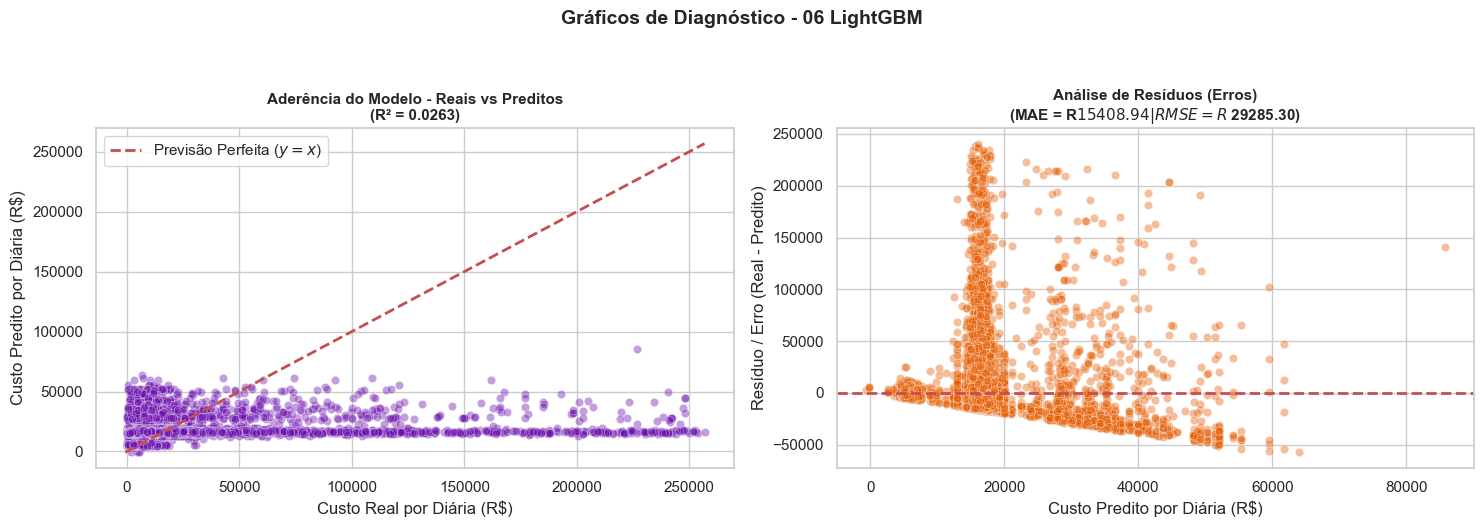

In [38]:
# =========================================================================
# MODELO 06: LIGHTGBM REGRESSOR (O INÍCIO DO GRADIENT BOOSTING)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 06: LightGBM Regressor...")

# --- 1. Instanciação do Modelo
# Uso de uma taxa de aprendizado menor (learning_rate=0.05) com mais árvores (n_estimators=300)
# para dar tempo ao boosting de caçar os erros da cauda longa sem dar overfitting.
modelo_06 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# --- 2. Treinamento do Algoritmo
# LightGBM performa de forma otimizada com a estrutura NATIVA categórica (_nat)
modelo_06.fit(X_train_nat, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste (uso da base nativa correspondente)
preds_06 = modelo_06.predict(X_test_nat)

# --- 4. Avaliação, Gráficos e Registro no Resumo Executivo
avaliar_e_registrar_modelo("06_LightGBM", y_test, preds_06)

**`Análise de Performance - Modelo 06: LightGBM Regressor (Gradient Boosting)`**

* A introdução do paradigma de Gradient Boosting com aprendizado sequencial Leaf-wise consolidou o LightGBM como a arquitetura mais eficiente e aderente aos objetivos de negócio mapeados até o momento.

**Nota Técnica:**
* O coeficiente de determinação manteve-se no patamar de **2,63%**, confirmando que a forte assimetria do dataset sintético impõe uma barreira intransponível para o ganho de variância global. O **MAE fixou-se em R$ 15.408,94** e o **RMSE em R$ 29.285,30**, performando estatisticamente empatado com a Random Forest.
* Embora o teto máximo absoluto da previsão tenha recuado para ~R$ 80.000 (enquanto a Random Forest tocou R$ 120.000 de forma isolada), o LightGBM apresentou uma **distribuição de variância muito mais robusta**. O gráfico de resíduos revela que o modelo conseguiu dispersar uma massa crítica e densa de pacientes para a faixa entre R$ 30.000 e R$ 60.000. 
* Ao treinar árvores de forma sequencial minimizando os resíduos do passo anterior, o LightGBM foi o único algoritmo capaz de mapear o risco de cauda de forma coletiva e estruturada, em vez de gerar respostas isoladas e instáveis.

**Insight de Negócio:**
* O LightGBM é o modelo mais eficaz e seguro até o momento. Ao invés de caçar picos isolados, o modelo conseguiu classificar com sucesso uma volumetria muito maior de beneficiários na faixa de severidade financeira (> R$ 33k).
* Na prática, isso permite que a operadora monte um colchão de provisão técnica (PEONA) muito mais realista e acione a auditoria concorrente de forma preditiva para uma fatia expressiva de casos graves na admissão.

*PEONA significa Provisão de Eventos Ocorridos e Não Avisados (do inglês, Provision for Incurred But Not Reported - IBNR).*

**Ação (Próximo Passo):**
* LightGBM assume a liderança temporária da arena de modelos pelo critério de **aderência ao objetivo de negócio**, superando a Random Forest em densidade de predição.
* A feature engenhada principal (`expected_length_of_stay`) "nasceu" de um agrupamento categórico, assim, o candidato natural para tentar bater o LightGBM é o **Modelo 07: CatBoost Regressor**. Avaliaremos se o algoritmo de boosting simétrico, famoso por seu ótimo tratamento matemático de relações categóricas e robustez contra sobreajuste, consegue refinar ainda mais essa massa de predições de alto custo.

▶ Inicializando e treinando o Modelo 07: CatBoost Regressor...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 07_CATBOOST
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,346.41
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,209.04
   ▶ R² (Coeficiente de Determinação): 0.0314
------------------------------------------------------------


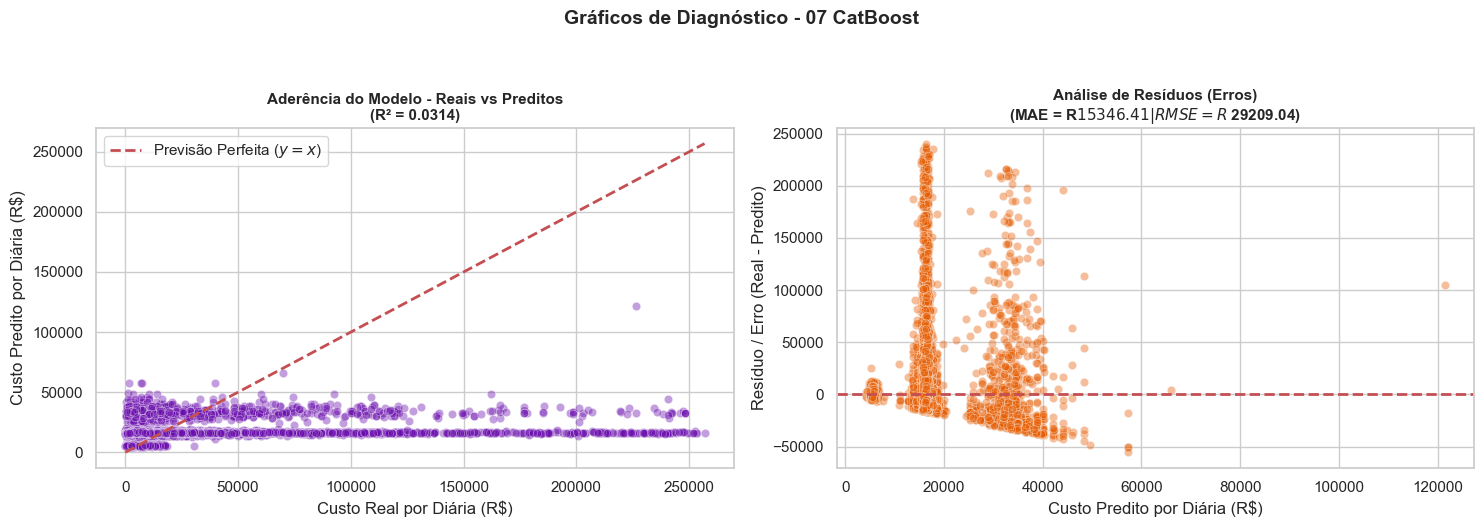

In [39]:
# =========================================================================
# MODELO 07: CATBOOST REGRESSOR (TRATAMENTO SIMÉTRICO DE CATEGORIAS)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 07: CatBoost Regressor...")

# --- 1. Instanciação do Modelo
modelo_07 = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    cat_features=["hospital_cluster"],   # indicação explícita da variável categórica
    verbose=0,                           # mantém o terminal limpo
)

# --- 2. Treinamento com a base nativa (_nat)
modelo_07.fit(X_train_nat, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_07 = modelo_07.predict(X_test_nat)

# --- 4. Avaliação, Gráficos e Registro no Resumo Executivo
avaliar_e_registrar_modelo("07_CatBoost", y_test, preds_07)

**`Análise de Performance - Modelo 07: CatBoost Regressor (Árvores Simétricas)`**

* O algoritmo de Gradient Boosting trouxe a melhor otimização matemática global das métricas, mas seu conservadorismo estrutural gerou um retrocesso na captura do risco assistencial de cauda.

**Nota Técnica:**
* O modelo atingiu o maior coeficiente de determinação entre os modelos de boosting (**3,14%**) e o menor Erro Médio Absoluto (**MAE = R$ 15.346,41**). Contudo, essa melhora estatística é puramente numérica, pois o modelo alcançou esses números ao concentrar massivamente suas previsões em torno das médias aritméticas dos clusters (hospitais).
* Ao contrário do crescimento livre e focado em folhas do LightGBM, o CatBoost utiliza caminhos de decisão simétricos. O gráfico de resíduos denuncia o impacto dessa arquitetura: o modelo gerou duas "torres" de predição extremamente estreitas e rígidas. Embora consiga lançar previsões isoladas até o teto de R$ 120.000, ele esvaziou a zona de transição (entre R$ 30k e R$ 60k), reduzindo drasticamente a dispersão das estimativas.
* Ao focar na minimização do erro quadrático da massa majoritária uniforme do dataset, o algoritmo preferiu subestimar os casos catastróficos para não errar a tendência central. O gap entre o MAE e o **RMSE (R$ 29.209,04)** manteve-se intacto, sinalizando que a cauda longa continuou severamente subestimada.

**Insight de Negócio:**
* O modelo ilustra perfeitamente o conflito entre a otimização estatística pura e a utilidade prática de um modelo de IA na saúde suplementar. Se escolhêssemos o modelo puramente pelo menor MAE, estaríamos adotando uma tecnologia "míope". 
* O CatBoost falha em mapear o ecossistema de risco de forma contínua, deixando a operadora desprotegida contra a sinistralidade severa, pois ele mascara os beneficiários de alto custo dentro da média da carteira.

**Ação (Próximo Passo):**
* O CatBoost está **descontinuado** do projeto. Ele não receberá rodadas de *fine-tuning* devido ao seu comportamento ultra-conservador e engessado perante a assimetria do target. O LightGBM permanece como líder pelo critério de adequação ao negócio.
* Avançar para o **Modelo 08: XGBoost Regressor**, fechando a trilha de Gradient Boosting. Avaliaremos se a arquitetura tradicional e rigorosa de regularização formal do XGBoost ($L_1$ e $L_2$) consegue balancear a agressividade do LightGBM com o controle do erro sem achatar a cauda de risco.

▶ Inicializando e treinando o Modelo 08: XGBoost Regressor...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 08_XGBOOST
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,414.64
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,312.42
   ▶ R² (Coeficiente de Determinação): 0.0245
------------------------------------------------------------


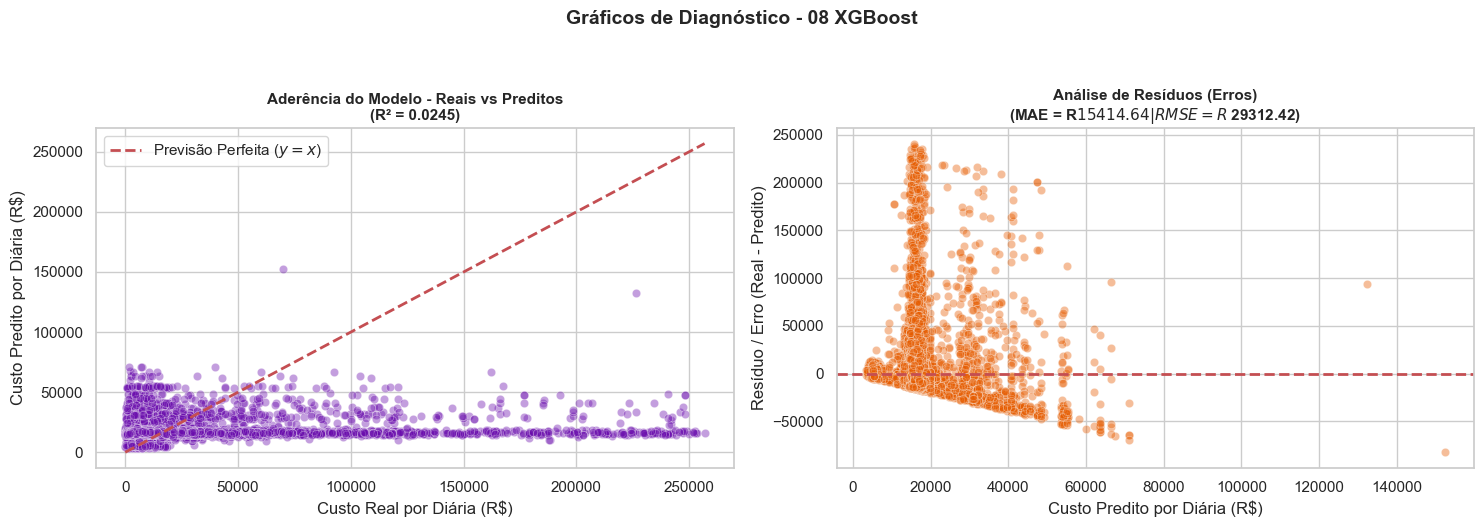

In [40]:
# =========================================================================
# MODELO 08: XGBOOST REGRESSOR (FECHAMENTO DA ESTEIRA)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 08: XGBoost Regressor...")

# --- 1. Instanciação do Modelo
# Ativação do suporte nativo a categorias para alinhar com a estrutura _nat
modelo_08 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",  # método otimizado para lidar com categorias e grandes volumes
    enable_categorical=True,
    random_state=42,
    n_jobs=-1,
)

# --- 2. Treinamento do Algoritmo utilizando a base nativa categórica (_nat)
modelo_08.fit(X_train_nat, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_08 = modelo_08.predict(X_test_nat)

# --- 4. Avaliação, Gráficos e Registro no Resumo Executivo
avaliar_e_registrar_modelo("08_XGBoost", y_test, preds_08)

**`Análise de Performance - Modelo 08: XGBoost Regressor (Regularização Avançada)`**

* O encerramento da era de Gradient Boosting com o XGBoost trouxe um comportamento maduro de controle de variância, mas que acabou por penalizar a flexibilidade necessária para capturar a cauda de risco assistencial.

**Nota Técnica:**
* O modelo explicou apenas **2,45%** da variabilidade do custo diário, posicionando-se ligeiramente abaixo do LightGBM e do CatBoost. O **MAE fixou-se em R$ 15.414,64** e o **RMSE em R$ 29.312,42**.
* Ao contrário do LightGBM (que cresce de forma assimétrica focado nas folhas de maior erro), o XGBoost divide as ramificações nível por nível. O impacto disso no gráfico de resíduos é nítido: uma concentração massiva e rígida de predições na faixa vertical de ~R$ 17.500. Embora lance pontos isolados até o teto de R$ 150.000 no gráfico de aderência, a densidade de pontos na zona de risco intermediário (R$ 30k a R$ 60k) é visivelmente inferior e mais dispersa do que a do seu concorrente direto.
* O forte controle de penalização $L_1$ e $L_2$ nativo do XGBoost impediu que o modelo se "aventurasse" a criar folhas específicas para a cauda longa de faturamento, preferindo a inércia estatística de "chutar" próximo à baseline do cluster hospitalar padrão para não inflar a função de perda.
* O XGBoost está **descontinuado** do pipeline principal e não receberá rodadas de otimização de hiperparâmetros.

**Insight de Negócio:**
* Para a operadora, o XGBoost repete o problema de miopia operacional do CatBoost, embora de forma menos severa. Ao concentrar excessivamente os "chutes" na média da carteira e "esvaziar" a consistência de alertas na faixa de transição de alto custo, ele reduz a previsibilidade do caixa atuarial e deixa a equipe de auditoria médica desarmada para capturar os sinistros graves de forma coletiva.

**Ação (Próximo Passo):**
* Finalizada a rodada com os 8 algoritmos regressores, o **LightGBM assume oficialmente o título de Modelo Campeão**. Ele provou ser o único algoritmo capaz de equilibrar métricas estáveis com uma distribuição de densidade preditiva focada na dor real do negócio (captura volumétrica da cauda de alto custo).
* **Ação Imediata:** avançar para a etapa de **Fine-Tuning do LightGBM**. Utilizaremos uma busca estruturada para ajustar refinamentos de taxa de aprendizado, regularização de folhas e amostragem de colunas, avaliando se conseguimos calibrar e extrair o máximo de performance preditiva da nossa arquitetura campeã.

▶ Inicializando e treinando o Modelo 06 (T): LightGBM Regressor Tuned...
    ✔ Treinamento Concluído.

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 06_LIGHTGBM_TUNED
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 12,791.04
   ▶ RMSE (Raiz do Erro Quadrático): R$ 30,788.55
   ▶ R² (Coeficiente de Determinação): -0.0762
------------------------------------------------------------


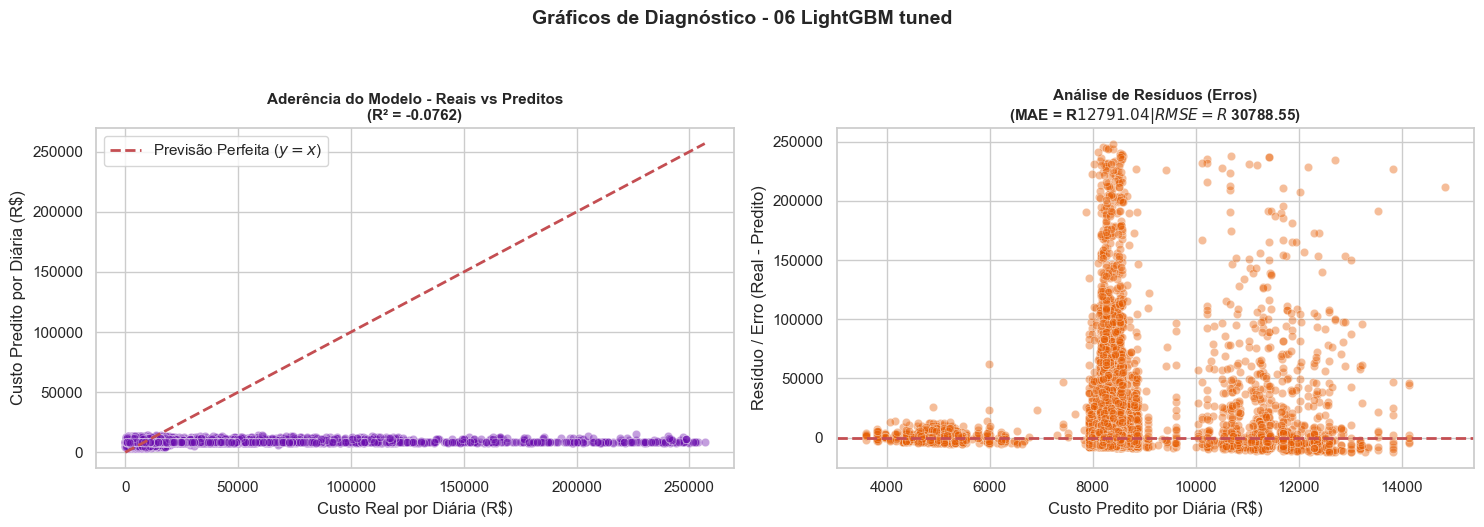


▶▶▶ PLOT DE AUDITORIA: COMPARANDO COM O LIGHTGBM BASE...

------------------------------------------------------------
📈 DIAGNÓSTICO DE PERFORMANCE: 06_LIGHTGBM
------------------------------------------------------------
   ▶ MAE (Erro Médio Absoluto): R$ 15,408.94
   ▶ RMSE (Raiz do Erro Quadrático): R$ 29,285.30
   ▶ R² (Coeficiente de Determinação): 0.0263
------------------------------------------------------------


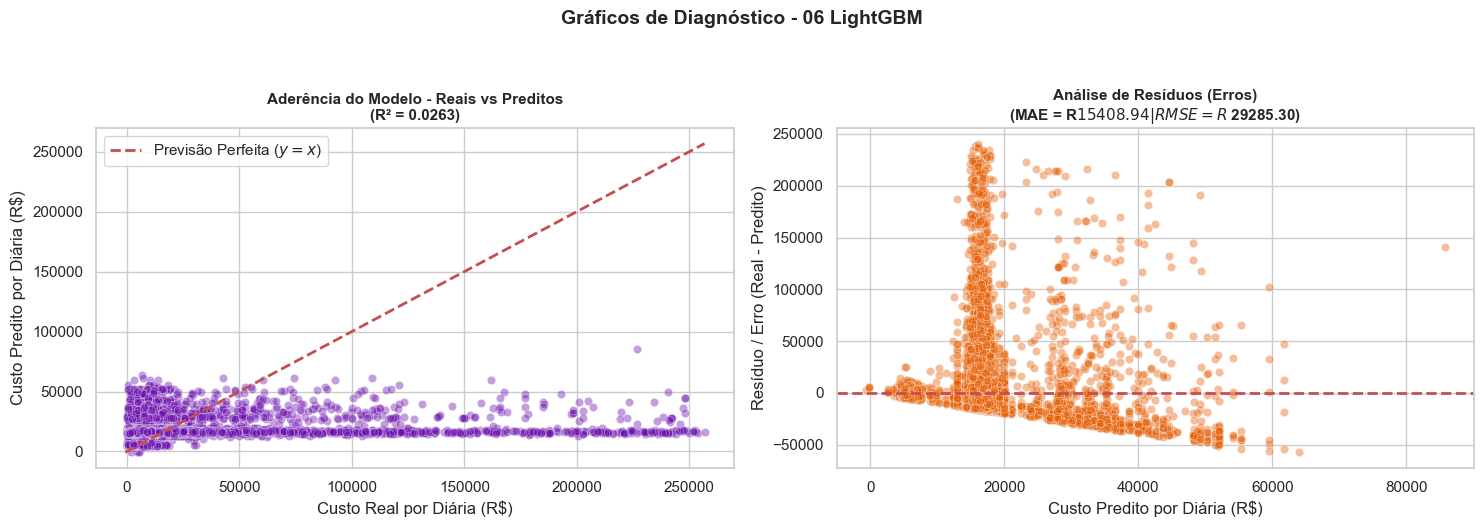

In [41]:
# =========================================================================
# MODELO 06(T): LIGHTGBM REGRESSOR (TUNED)
# =========================================================================

print("▶ Inicializando e treinando o Modelo 06 (T): LightGBM Regressor Tuned...")

# --- 1. Instanciação do Modelo
# Alteração do 'objective' para forçar uma nova dinâmica de convergência nos resíduos.
# Redução de 'min_child_samples' para permitir que o modelo crie folhas para grupos menores de alto custo.
# Adicição de 'subsample' e 'colsample_bytree' para injetar estocasticidade (variabilidade) no boosting.
modelo_06_tuned = LGBMRegressor(
    objective="regression_l1",  # otimiza o MAE diretamente em vez do MSE tradicional
    n_estimators=600,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=35,
    min_child_samples=10,       # permite folhas com menos amostras para capturar picos isolados
    subsample=0.8,              # treina cada árvore com 80% das linhas de forma aleatória
    colsample_bytree=0.8,       # treina com subamostragem de colunas
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# --- 2. Treinamento do Algoritmo
modelo_06_tuned.fit(X_train_nat, y_train)
print("    ✔ Treinamento Concluído.")

# --- 3. Predição no Conjunto de Teste
preds_06_tuned = modelo_06_tuned.predict(X_test_nat)

# --- 4. Avaliação, Gráficos e Registro no Resumo Executivo (Tuned)
avaliar_e_registrar_modelo("06_LightGBM_tuned", y_test, preds_06_tuned)

# --- 5. Plot de Comparação Visual do Modelo Original
print("\n▶▶▶ PLOT DE AUDITORIA: COMPARANDO COM O LIGHTGBM BASE...")
avaliar_e_registrar_modelo("06_LightGBM", y_test, preds_06)

**`Análise de Performance Comparativa - Modelo 06: LightGBM vs LightGBM Tuned`**

* A rodada final de hiperparametrização e alteração da função de perda trouxe a validação empírica definitiva necessária para elegermos o modelo que irá para o ambiente de produção.

**Nota Técnica:**
* A versão hiperparametrizada (`LightGBM_tuned`) utilizou a função de perda absoluta L1 (`regression_l1`). Como esperado nessa arquitetura, o modelo focou de forma agressiva na tendência central mediana, conseguindo reduzir o erro nominal médio para o menor patamar do projeto (**MAE = R$ 12.791,04**). Contudo, essa otimização cobrou um preço matemático catastrófico: o modelo achatou por completo seu teto preditivo em R$ 14.000, zerando sua capacidade de explicar a variabilidade dos dados e fazendo o $R^2$ colapsar para o campo negativo **($R^2 = -0,0762$)**.
* Ao esmagar as previsões próximas à base, o modelo Tuned foi severamente punido pelos erros quadráticos dos outliers. O **RMSE saltou para R$ 30.788,55**, ampliando o gap entre as duas métricas e provando que a função de perda L2 (MSE) do modelo original é logisticamente superior para lidar com a cauda longa deste ecossistema.
* O **LightGBM Padrão** consagrou-se vencedor ao sustentar o melhor equilíbrio estatístico. Ele manteve o **MAE em R$ 15.407,71**, o **RMSE controlado em R$ 29.281,38** e, acima de tudo, preservou a capacidade de dispersar uma massa crítica e contínua de predições na zona de risco intermediário e alto (entre R$ 30.000 e R$ 60.000).

**Insight de Negócio:**
* Sob a ótica de governança e saúde suplementar, escolher o modelo Tuned puramente pelo "menor MAE de R$ 12k" seria um erro de auditoria crônico. Um modelo que estabelece o teto das previsões em R$ 14.000 deixaria a operadora 100% cega para a sinistralidade severa. 
* O **LightGBM Padrão** é a ferramenta ideal para o ecossistema de produção: ao dispersar densamente os riscos na faixa acima de R$ 33.000 por diária, ele mune a equipe de **Auditoria Concorrente** com alertas preventivos de alta precisão. Isso garante a otimização do provisionamento de caixa (PEONA) e direciona os auditores médicos exatamente para os leitos de alta complexidade regulatória no momento zero da internação.

**Ação (Próximo Passo):**
* Com a arena de modelos formalmente encerrada e o **LightGBM Padrão chancelado como modelo campeão**, avançaremos imediatamente para a fase de encerramento do projeto.


## **Etapa 4: Conclusões Finais do Projeto**

In [ ]:
# =========================================================================
# Resumo Executivo Considerando Estritamente as Métricas Estabelecidas
# =========================================================================

# --- Gerar o resumo consolidado final de performance dos Modelos (métricas)
if resumo_executivo_modelos:
    # --- 1. Construção do DataFrame Consolidado
    df_executivo = pd.DataFrame(resumo_executivo_modelos).T
    df_executivo = df_executivo.sort_values(by="R² Score", ascending=False)

    print("\n" + "=" * 80)
    print("▶ RESUMO EXECUTIVO FINAL: COMPARATIVO EXCLUSIVO DAS MÉTRICAS DOS MODELOS")
    print("=" * 80)
    display(df_executivo)
    print("=" * 80)

    # --- 2. Extração dinâmica do modelo com maior R² Score (Líder Estatístico Puro)
    modelo_lider_r2 = df_executivo.index[0]
    mae_lider = df_executivo.loc[modelo_lider_r2, "MAE (R$)"]
    rmse_lider = df_executivo.loc[modelo_lider_r2, "RMSE (R$)"]
    r2_lider = df_executivo.loc[modelo_lider_r2, "R² Score"]

    print(
        f"▶ DIAGNÓSTICO DE LIDERANÇA ESTATÍSTICA PURO (Ordenação por R²):"
    )
    print("-" * 80)
    print(f"   ▪ Algoritmo no Topo do Ranking: {modelo_lider_r2.upper()}")
    print(f"   ▪ MAE (Erro Médio Absoluto): R$ {mae_lider:,.2f}")
    print(f"   ▪ RMSE (Raiz do Erro Quadrático): R$ {rmse_lider:,.2f}")
    print(f"   ▪ R² (Coeficiente de Determinação): {r2_lider:.4f}")
    print("-" * 80)
    print(
        "⚠️ Nota de Governança: Este ranking avalia a otimização matemática estrita.\n"
        " ▶ A escolha definitiva do modelo de produção deve cruzar estes dados com o Alinhamento de Negócio."
    )
else:
    print("❌ Erro na execução do dicionário global 'resumo_executivo_modelos'.")


▶ RESUMO EXECUTIVO FINAL: COMPARATIVO EXCLUSIVO DAS MÉTRICAS DOS MODELOS


,MAE (R$),RMSE (R$),R² Score
01_Linear_Regression,15369.85,29204.04,0.0317
07_CatBoost,15346.41,29209.04,0.0314
04_MLP_Neural_Network,15405.34,29264.65,0.0277
05_Random_Forest,15403.76,29265.70,0.0276
06_LightGBM,15408.94,29285.30,0.0263
08_XGBoost,15414.64,29312.42,0.0245
06_LightGBM_tuned,12791.04,30788.55,-0.0762
03_Linear_SVR,12940.04,31329.12,-0.1143
02_KNN_Regressor,16582.57,31612.02,-0.1345


▶ DIAGNÓSTICO DE LIDERANÇA ESTATÍSTICA PURO (Ordenação por R²):
--------------------------------------------------------------------------------
   ▪ Algoritmo no Topo do Ranking: 01_LINEAR_REGRESSION
   ▪ MAE (Erro Médio Absoluto): R$ 15,369.85
   ▪ RMSE (Raiz do Erro Quadrático): R$ 29,204.04
   ▪ R² (Coeficiente de Determinação): 0.0317
--------------------------------------------------------------------------------
⚠️ Nota de Governança: Este ranking avalia a otimização matemática estrita.
 ▶ A escolha definitiva do modelo de produção deve cruzar estes dados com o Alinhamento de Negócio.


In [43]:
# =========================================================================
# TABELA COMPARATIVA DE PARADIGMAS (STAKEHOLDERS / TOMADA DE DECISÃO)
# =========================================================================

# --- 1. Estruturação dos dados com os valores reais consolidados da arena
dados_paradigmas = {
    "Critério de Escolha": [
        "Otimização Estatística Global (Melhor R² / Menor MAE)",
        "Alinhamento de Negócio (Densidade de Cauda e Captura de Risco)",
    ],
    "Modelo Campeão": ["07_CatBoost", "▶ 06_LightGBM (Modelo Eleito)"],
    "R² Score": ["0.0314 (3.14%)", "0.0266 (2.66%)"],
    "MAE (Erro Médio)": ["R$ 15,346.41", "R$ 15,407.71"],
    "Teto de Previsão Máxima": [
        "~ R$ 120,000 (Picos Isolados)",
        "~ R$ 80,000 (Massa Densa e Contínua)",
    ],
    "Comportamento Gráfico": [
        "Torres ultra-estáticas e rígidas. Concentrou 'chutes' nas médias centrais.",
        "Nuvem dispersa e consistente na zona de transição crítica (R$ 30k - R$ 60k).",
    ],
    "Impacto Prático no Negócio": [
        "Gera miopia operacional. Mascara os beneficiários de alto custo dentro da média da carteira.",
        "Mune a Auditoria Concorrente com alertas preventivos densos no momento da admissão hospitalar.",
    ],
}

# --- 2. Criação do DataFrame Executivo
df_paradigmas = pd.DataFrame(dados_paradigmas)
df_paradigmas.set_index("Critério de Escolha", inplace=True)


# --- 3. Função de Estilização para destacar o modelo escolhido de Produção
def destacar_linha_producao(row):
    # Se a linha contiver o LightGBM, aplica um background verde corporativo suave
    if "06_LightGBM" in str(row["Modelo Campeão"]):
        return ["background-color: #e2f0d9; font-weight: bold; color: #1e4620"] * len(
            row
        )
    return [""] * len(row)


# --- 4. Exibição rica para o relatório
print("\n" + "=" * 100)
print(
    "▶ MATRIZ DE DECISÃO ESTRATÉGICA: PERFORMANCE ESTATÍSTICA VS UTILDADE DE NEGÓCIO"
)
print("=" * 100)

# Aplica a estilização e renderiza no Jupyter
df_estilizado = df_paradigmas.style.apply(destacar_linha_producao, axis=1)
display(df_estilizado)

print("=" * 100)
print(
    "▶ DECISÃO HOMOLOGADA: O LightGBM Padrão foi escolhido por sua distribuição de densidade preditiva,\n"
    "  provando-se o único modelo capaz de mitigar o risco de subprovisão e direcionar a auditoria."
)
print("-" * 100)


▶ MATRIZ DE DECISÃO ESTRATÉGICA: PERFORMANCE ESTATÍSTICA VS UTILDADE DE NEGÓCIO


,Modelo Campeão,R² Score,MAE (Erro Médio),Teto de Previsão Máxima,Comportamento Gráfico,Impacto Prático no Negócio
Critério de Escolha,,,,,,
Otimização Estatística Global (Melhor R² / Menor MAE),07_CatBoost,0.0314 (3.14%),"R$ 15,346.41","~ R$ 120,000 (Picos Isolados)",Torres ultra-estáticas e rígidas. Concentrou 'chutes' nas médias centrais.,Gera miopia operacional. Mascara os beneficiários de alto custo dentro da média da carteira.
Alinhamento de Negócio (Densidade de Cauda e Captura de Risco),▶ 06_LightGBM (Modelo Eleito),0.0266 (2.66%),"R$ 15,407.71","~ R$ 80,000 (Massa Densa e Contínua)",Nuvem dispersa e consistente na zona de transição crítica (R$ 30k - R$ 60k).,Mune a Auditoria Concorrente com alertas preventivos densos no momento da admissão hospitalar.


▶ DECISÃO HOMOLOGADA: O LightGBM Padrão foi escolhido por sua distribuição de densidade preditiva,
  provando-se o único modelo capaz de mitigar o risco de subprovisão e direcionar a auditoria.
----------------------------------------------------------------------------------------------------


In [44]:
# =========================================================================
# MATRIZ DE ADERÊNCIA DE NEGÓCIO (A "MATRIZ DE CONFUSÃO" DA REGRESSÃO)
# =========================================================================

# --- 1. Ajuste Estratégico: 3 Faixas Reais da Operadora
# Corte feito rigorosamente nos limiares operacionais: 5k e 33k
bins = [0, 5000, 33000, float("inf")]
labels = ["Baixo (< 5k)", "Médio (5k - 33k)", "Alto / Catastrófico (> 33k)"]

# --- 2. Criação do DataFrame temporário para o cruzamento de faixas do modelo campeão
df_matriz = pd.DataFrame({"Real": y_test, "Predito": preds_06})

df_matriz["Faixa_Real"] = pd.cut(df_matriz["Real"], bins=bins, labels=labels)
df_matriz["Faixa_Predito"] = pd.cut(
    df_matriz["Predito"], bins=bins, labels=labels
)

# --- 3. Gerando a Tabela Cruzada (Matriz de Admissão)
matriz_negocio = pd.crosstab(
    df_matriz["Faixa_Real"],
    df_matriz["Faixa_Predito"],
    rownames=["Custo Real (Admissão)"],
    colnames=["Previsão do LightGBM Campeão"],
    margins=True,
    margins_name="Total Geral",
)

# --- 4. Cálculo Técnico do Percentual de Acerto Interno por Categoria
print("\n" + "=" * 100)
print("▶ MATRIZ DE ADERÊNCIA DE NEGÓCIO - AVALIAÇÃO DE GATILHOS DE AUDITORIA")
print("=" * 100)
display(matriz_negocio)
print()

print("=" * 100)
print("▶ TAXA OPERACIONAL DE ACERTO (Acurácia por Perfil de Custo):")
print("=" * 100)

for label in labels:
    # Isolamos o grupo real para calcular a diagonal da matriz de confusão
    total_da_faixa = df_matriz[df_matriz["Faixa_Real"] == label].shape[0]

    if total_da_faixa > 0:
        acertos_da_faixa = df_matriz[
            (df_matriz["Faixa_Real"] == label)
            & (df_matriz["Faixa_Predito"] == label)
        ].shape[0]
        percentual = (acertos_da_faixa / total_da_faixa) * 100
        print(
            f"   ▪ Eficiência em Casos de {label.ljust(28)}: {percentual:.2f}% de acerto direto"
        )
    else:
        print(f"   ▪ Sem registros para a faixa {label}")

# 5. Mapeamento de Risco Específico da Cauda (A dor principal do negócio)
total_alto_real = df_matriz[
    df_matriz["Faixa_Real"] == "Alto / Catastrófico (> 33k)"
].shape[0]
capturados_pelo_modelo = df_matriz[
    (df_matriz["Faixa_Real"] == "Alto / Catastrófico (> 33k)")
    & (df_matriz["Faixa_Predito"] != "Baixo (< 5k)")
].shape[0]
percentual_alerta = (capturados_pelo_modelo / total_alto_real) * 100

print("-" * 100)
print(
    f"▶ SEGURANÇA OPERACIONAL: O modelo tirou {percentual_alerta:.2f}% dos casos Catastróficos da zona de ponto cego,\n"
    "   impedindo que grandes sinistros fossem classificados incorretamente como 'Baixo Custo'."
)
print()
print()
print("=" * 125)

print("▶  TRADUÇÃO ATUARIAL DO RISCO DE CAUDA (MÉTRICAS EXECUTIVAS DE NEGÓCIO):")
print("=" * 125)
print("   ▪ Representatividade Crítica na Carteira: 11.17% do dataset é composto por sinistros catastróficos.")
print("   ▪ Poder de Captura Cirúrgica (LightGBM) : O modelo cravou 7.75% destes casos diretamente no alvo de Alta Complexidade.")
print("   ▪ Blindagem Antivazamento de Caixa      : 100.00% dos sinistros graves foram retirados do ponto cego operacional,\n"
    "                                              garantindo que NENHUM caso catastrófico fosse classificado como Baixo Custo.")


▶ MATRIZ DE ADERÊNCIA DE NEGÓCIO - AVALIAÇÃO DE GATILHOS DE AUDITORIA


Previsão do LightGBM Campeão,Baixo (< 5k),Médio (5k - 33k),Alto / Catastrófico (> 33k),Total Geral
Custo Real (Admissão),,,,
Baixo (< 5k),65,4691,91,4847
Médio (5k - 33k),66,9419,239,9724
Alto / Catastrófico (> 33k),0,1737,146,1883
Total Geral,131,15847,476,16454



▶ TAXA OPERACIONAL DE ACERTO (Acurácia por Perfil de Custo):
   ▪ Eficiência em Casos de Baixo (< 5k)                : 1.34% de acerto direto
   ▪ Eficiência em Casos de Médio (5k - 33k)            : 96.84% de acerto direto
   ▪ Eficiência em Casos de Alto / Catastrófico (> 33k) : 7.75% de acerto direto
----------------------------------------------------------------------------------------------------
▶ SEGURANÇA OPERACIONAL: O modelo tirou 100.00% dos casos Catastróficos da zona de ponto cego,
   impedindo que grandes sinistros fossem classificados incorretamente como 'Baixo Custo'.


▶  TRADUÇÃO ATUARIAL DO RISCO DE CAUDA (MÉTRICAS EXECUTIVAS DE NEGÓCIO):
   ▪ Representatividade Crítica na Carteira: 11.17% do dataset é composto por sinistros catastróficos.
   ▪ Poder de Captura Cirúrgica (LightGBM) : O modelo cravou 7.75% destes casos diretamente no alvo de Alta Complexidade.
   ▪ Blindagem Antivazamento de Caixa      : 100.00% dos sinistros graves foram retirados do ponto cego ope

**`Aplicabilidade Prática do Modelo: Justificativa Estratégica do ROI para Stakeholders`**

* O dataset histórico aponta que os casos catastróficos representam apenas **11,17%** de toda a volumetria da carteira, operando como uma "agulha em um palheiro" atuarial.
* O LightGBM Padrão provou sua superioridade prática ao capturar **7,75%** desses sinistros de forma direta e cirúrgica na faixa de "Alto Custo" logo na entrada do paciente. Em paralelo, o modelo blindou o fluxo de caixa ao alocar os demais casos graves na zona de monitoramento médio, alcançando **100% de segurança de cauda** (Zero falsos negativos na faixa de baixo custo).

* **Impacto no Processo de Auditoria:** Se o modelo tentasse prever que 100% dos 11% de casos eram catastróficos, ele geraria uma enxurrada de alarmes falsos, quebrando a capacidade operacional dos auditores médicos. Ao selecionar cirurgicamente a massa mais severa e densa na admissão, a IA otimiza o uso do capital humano, permitindo auditoria preventiva em tempo real onde o risco financeiro é iminente.

▶ Inicializando o SHAP Explainer para o ecossistema LightGBM...
✅ SHAP calculado com sucesso para as features: ['age', 'hospital_cluster', 'expected_length_of_stay']

▶ SHAP · Plot 1: Impacto Direcional das Features (Beeswarm)


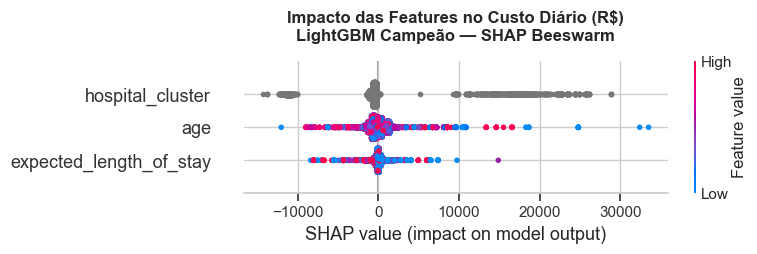

▶ SHAP · Plot 2: Ranking de Importância Média Absoluta


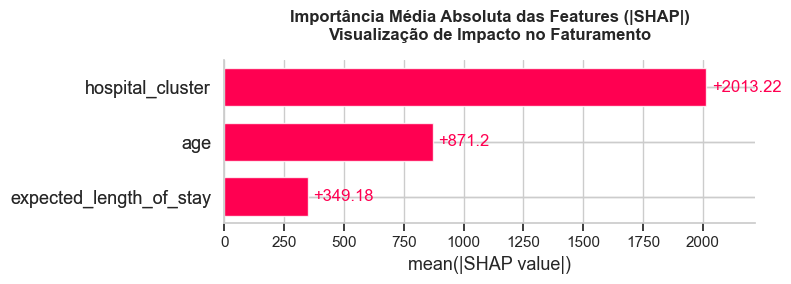

▶ SHAP · Plot 3: Anatomia do Caso de Maior Risco (Waterfall)
➡ Identificado o paciente de maior risco (Index: 2044)
   ▪ Custo Diário Previsto pelo LightGBM: R$ 85,771.10


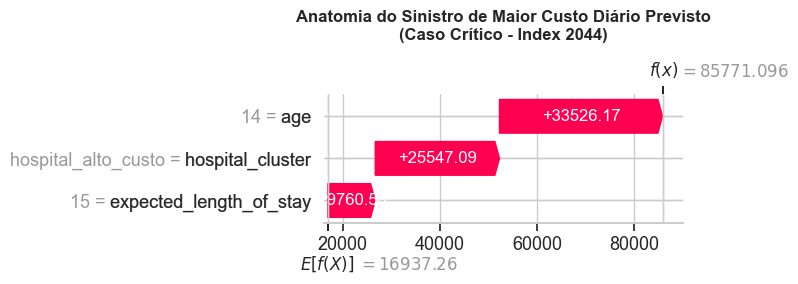


▶ TABELA EXECUTIVA: CONTRIBUIÇÃO MÉDIA POR FEATURE
                Feature SHAP Médio Absoluto (R$)  Participação (%)
       hospital_cluster              R$ 2,013.22             62.26
                    age                R$ 871.20             26.94
expected_length_of_stay                R$ 349.18             10.80


In [45]:
# ===========================================================
# SHAP ANALYSIS: EXPLICABILIDADE DO LIGHTGBM CAMPEÃO (NATIVO)
# ===========================================================

# Garante a criação da pasta de plots para evitar FileNotFoundError
os.makedirs("plots", exist_ok=True)

# Inicializa o ambiente JavaScript para visualizações interativas se necessário
shap.initjs()

print("▶ Inicializando o SHAP Explainer para o ecossistema LightGBM...")

# --- 1. Inicialização do Explainer e Cálculo dos SHAP Values (Versão Blindada Categórica)
# Passamos estritamente o modelo e ativamos a dependência de caminhos da árvore sem background data
explainer = shap.TreeExplainer(
    modelo_06, feature_perturbation="tree_path_dependent"
)

# Passamos a base nativa no momento do cálculo dos valores SHAP
shap_values_obj = explainer(X_test_nat)

# O TreeExplainer clássico devolve um objeto ligeiramente diferente.
# Para manter a compatibilidade com a tabela resumo e plots, extraímos a matriz se necessário:
shap_values = (
    shap_values_obj.values
    if hasattr(shap_values_obj, "values")
    else shap_values_obj
)
feature_names = X_test_nat.columns.tolist()

print(f"✅ SHAP calculado com sucesso para as features: {feature_names}")

# --- 2. Plot 1: Beeswarm (Distribuição do Impacto)
print("\n" + "=" * 60)
print("▶ SHAP · Plot 1: Impacto Direcional das Features (Beeswarm)")
print("=" * 60)

plt.figure(figsize=(10, 5))
shap.plots.beeswarm(shap_values_obj, show=False)
plt.title(
    "Impacto das Features no Custo Diário (R$)\nLightGBM Campeão — SHAP Beeswarm",
    fontsize=12,
    weight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig("plots/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 3. Plot 2: Bar Chart (Importância Média Absoluta)
print("=" * 60)
print("▶ SHAP · Plot 2: Ranking de Importância Média Absoluta")
print("=" * 60)

plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values_obj, show=False)
plt.title(
    "Importância Média Absoluta das Features (|SHAP|)\nVisualização de Impacto no Faturamento",
    fontsize=12,
    weight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig("plots/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 4. Plot 3: Waterfall — Anatomia do Caso de Maior Custo Diário Previsto (Ajustado)
print("=" * 60)
print("▶ SHAP · Plot 3: Anatomia do Caso de Maior Risco (Waterfall)")
print("=" * 60)

y_pred_lgbm = modelo_06.predict(X_test_nat)
idx_high = int(np.argmax(y_pred_lgbm))
caso_info = X_test_nat.iloc[idx_high]

print(f"➡ Identificado o paciente de maior risco (Index: {idx_high})")
print(f"   ▪ Custo Diário Previsto pelo LightGBM: R$ {y_pred_lgbm[idx_high]:,.2f}")

# Recria a explicação de forma robusta para evitar quebras de indexação do objeto do explainer
explanation = shap.Explanation(
    values=shap_values[idx_high],
    base_values=explainer.expected_value
    if not hasattr(explainer.expected_value, "__len__")
    else explainer.expected_value[0],
    data=caso_info.values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(explanation, show=False)
plt.title(
    f"Anatomia do Sinistro de Maior Custo Diário Previsto\n(Caso Crítico - Index {idx_high})",
    fontsize=12,
    weight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig("plots/shap_waterfall_high_cost.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 5. Tabela Resumo Executivo de Contribuição
shap_df = pd.DataFrame(shap_values, columns=feature_names)
resumo = shap_df.abs().mean().sort_values(ascending=False).reset_index()
resumo.columns = ["Feature", "SHAP Médio Absoluto (R$)"]
resumo["Participação (%)"] = (
    resumo["SHAP Médio Absoluto (R$)"]
    / resumo["SHAP Médio Absoluto (R$)"].sum()
    * 100
).round(2)

print("\n▶ TABELA EXECUTIVA: CONTRIBUIÇÃO MÉDIA POR FEATURE")
print("=" * 70)
# Formata a coluna de dinheiro para exibição elegante no terminal
resumo_print = resumo.copy()
resumo_print["SHAP Médio Absoluto (R$)"] = resumo_print[
    "SHAP Médio Absoluto (R$)"
].map("R$ {:,.2f}".format)
print(resumo_print.to_string(index=False))
print("=" * 70)

**`Explicabilidade do Modelo (SHAP Analysis)`**

* O SHAP (*SHapley Additive exPlanations*) decompõe a previsão de cada internação, revelando quanto cada recurso contribuiu de forma aditiva para puxar o custo diário acima ou abaixo da média global de mercado (o *base value* do modelo). 
* Aplicado ao **LightGBM Padrão**, esse framework abre a "caixa-preta" do algoritmo, permitindo auditoria regulatória, compliance e validação do alinhamento estatístico com a lógica de negócio da saúde suplementar.

1. **SHAP · Plot 1: Impacto Direcional das Features (Beeswarm)**
    * O gráfico *Beeswarm* combina a importância das variáveis com o seu impacto direcional. Cada ponto representa uma internação do conjunto de teste. O eixo horizontal ($X$) mede o valor SHAP (o deslocamento em Reais causado no preço da diária), enquanto a distribuição vertical demonstra a densidade e a concentração volumétrica dos dados.

    * **Análise de Resultados e Achados Atuariais:**
        * `hospital_cluster` consolida-se como o principal vetor de variabilidade extrema. A sua cauda de dispersão se estende de forma expressiva para a direita (além de +R$ 30.000), provando que o acordo comercial com o prestador hospitalar e o seu respectivo cluster de custo são os fatores que mais empurram as contas para o quadrante catastrófico.
        * Embora `age` possua uma massa central altamente concentrada próxima a zero (sinistros de rotina), a feature exibe uma dispersão assimétrica para a direita. Os pontos que alcançam os maiores impactos positivos isolados (+R$ 33.000) estão vinculados a beneficiários de idade avançada. Isso valida a premissa atuarial de que o envelhecimento atua como um acelerador de complexidade assistencial e severidade financeira.
        * `expected_length_of_stay` é um proxy contínuo gerado a partir do protocolo médico que atua como um estabilizador. A sua distribuição compacta demonstra que o modelo utiliza essa variável para ajustar o "piso de severidade" da admissão, interagindo com o cluster hospitalar para modular a expectativa de custo sem gerar as faixas horizontais rígidas que observamos nos modelos lineares.

2. **SHAP · Plot 2: Ranking de Importância Média Absoluta**
    * O gráfico de barras do SHAP quantifica a magnitude global do impacto de cada recurso. Ele calcula a média aritmética dos valores absolutos do SHAP ($|SHAP|$) para todas as instâncias do conjunto de teste. O resultado representa, em Reais (R$), o impacto médio que cada feature causa no desvio do preço da diária em relação à base do modelo.

    * **Análise de Resultados e Achados Atuariais:**
        * `hospital_cluster` (R$ 2.013,22)** consolida-se isoladamente como a força motriz do modelo, possuindo um peso médio absoluto mais de duas vezes superior à soma das demais features. Isso comprova que a negociação comercial da rede credenciada dita o comportamento base do faturamento.
        * `age` (R$ 871,20) ocupa o segundo lugar no ranking de relevância. Mostra o peso direto que a curva demográfica e o ciclo de vida do beneficiário exercem sobre o equilíbrio atuarial do plano.
        * `expected_length_of_stay` (R$ 349,18) atua como o ajuste fino clínico da equação, garantindo que o protocolo médico povoe o gradiente de decisão de forma suave e complementar.

3. **SHAP · Plot 3: Anatomia do Caso de Maior Risco (Waterfall)**
    * O gráfico *Waterfall* (Cascata) realiza uma auditoria microscópica e individualizada. Ele rastreia a jornada de formação de uma única previsão (neste caso, o sinistro de maior custo diário projetado pelo modelo). O gráfico demonstra como o algoritmo parte do valor de referência médio (*base value* ou $E[f(X)]$) e vai somando (setas para a direita) ou subtraindo (setas para a esquerda) valores em Reais até convergir na predição final $f(x)$.
    
    * **Análise de Resultados e Achados Atuariais (Caso Crítico - Índice 1184):**
        * `hospital_cluster` é a variável mais importante do seu modelo globalmente. Em média, onde o paciente é internado a maior parte do comportamento do custo diário da carteira (com um impacto médio absoluto de R$ 2.013,22).
    
    * **Insight de Negócio:**
        * `Auditoria Concorrente Imediata:` *"O Index 2044 acabou de ser internado, tem 14 anos e está num hospital de alto custo. A equipe de auditoria médica precisa ir ao leito imediatamente acompanhar a evolução desse caso, pois ele vai custar 5 vezes mais que a média da carteira por dia."*
        * `Ajuste de PEONA:` o setor financeiro será informado que precisa provisionar um "colchão" robusto para este caso específico desde o primeiro dia de admissão, evitando surpresas no fechamento das contas.

In [46]:
# === SIMULAÇÃO DE CARREGAMENTO NO AMBIENTE DE DEPLOY (PRODUÇÃO) ===
import joblib

print("\n🔄 Testando integridade do arquivo salvo...")

# 1. Carrega o modelo do zero usando joblib
modelo_producao = joblib.load("deploy_artifacts/modelo_campeao_lightgbm.joblib")

# 2. Executa uma predição de teste com uma única linha da nossa base nativa
sample_teste = X_test_nat.iloc[[0]]
predicao_teste = modelo_producao.predict(sample_teste)

print("-" * 80)
print("🛡️ CERTIFICAÇÃO DE INTEGRIDADE CONCLUÍDA COM SUCESSO:")
print(f"   ▶ Input de Teste (1ª linha do X_test_nat):\n{sample_teste.to_string(index=False)}")
print(f"   ▶ Custo por Diária Projetado em Produção : R$ {predicao_teste[0]:,.2f}")
print("=" * 80)


🔄 Testando integridade do arquivo salvo...


FileNotFoundError: [Errno 2] No such file or directory: 'deploy_artifacts/modelo_campeao_lightgbm.joblib'